# Фундаментальный анализ компаний агропромышленного сектора

[Открыть аналитический отчёт по результатам фундаментального скрининга агросектора](https://github.com/AlexandreFyodorov/My_Research_Projects/blob/main/Issledovanie_market/Results/analys_agroprom_results.ipynb)

## 1. Описание проекта

Автоматизированная система поэтапного анализа финансового состояния и инвестиционной привлекательности российских публичных компаний. Проект объединяет данные из трёх источников: файл с фундаментальными показателями (МСФО), биржевая статистика из терминала QUIK (обороты, заявки, free float) и информация о секторальной принадлежности. Скрипт реализует полный цикл обработки от фильтрации ликвидных бумаг до построения интегрального рейтинга и экспорта результатов в CSV.

### 1.1. Цель работы

Разработать воспроизводимый алгоритм скрининга акций, позволяющий инвестору объективно сравнивать компании внутри отраслей, выявлять лидеров по ключевым финансовым метрикам и формировать обоснованный инвестиционный портфель.

### 1.2. Задачи проекта

1. **Сбор и предобработка данных** — объединение информации из трёх источников, очистка, приведение к единому формату.
2. **Фильтрация по ликвидности** — отбор инструментов с достаточным оборотом и количеством заявок.
3. **Расчёт мультипликаторов** — вычисление P/E, P/S, EV/EBITDA, P/B, Debt/Equity, Interest Coverage и других показателей.
4. **Сегментарный анализ** — сравнение компаний внутри одного сектора экономики.
5. **Визуализация результатов** — создание наглядных графиков (scatter plots, bar charts, гистограммы) для каждого этапа анализа.
6. **Ранжирование компаний** — построение интегрального рейтинга на основе комбинации фундаментальных метрик.
7. **Экспорт данных** — сохранение всех промежуточных и итоговых таблиц в формате CSV с временной меткой для дальнейшего анализа в Excel.

### 1.3. Формирование выборки

**Источники данных:**

- `df_fund.xlsx` — файл с чистыми фундаментальными показателями (выручка, чистая прибыль, долг, EBITDA, FCF и др.), полученными из отчётов МСФО.
- `Torgi_YYYYMMDD.xlsx` (лист `Liquid`) — выгрузка из терминала QUIK, содержащая: код инструмента, оборот за день, количество заявок на покупку и продажу, цену закрытия, free float на основе биржевых данных.
- `moex_freefloat.xls` — данные по free float с сайта Московской биржи (скачиваются вручную).
- `Sector.xlsx` — файл с распределением компаний по секторам экономики.

**Критерии включения:**

- Наличие тикера в файле `Torgi_*.xlsx`.
- Оборот за день >= `MIN_TURNOVER` (1 млн руб.).
- Количество заявок на покупку >= `MIN_BID_ORDERS` (100 шт.).
- Попадание в диапазон позиций от `MIN_TICKERS` до `MAX_TICKERS` после сортировки всех прошедших фильтр компаний по убыванию оборота (по умолчанию позиции с 31 по 60).

**Критерии исключения:**

- Отсутствие тикера в итоговом списке `selected_tickers`.
- Критическая нехватка данных для расчёта мультипликаторов (на этапе ранжирования такие строки удаляются).

### 1.4. План работы

#### Этап 0. Настройка и загрузка данных
- Подключение необходимых библиотек: `pandas`, `numpy`, `matplotlib`, `seaborn`, `requests`, `os`, `datetime`, `warnings`.
- Определение путей к исходным файлам и создание папки `Analitika/` для сохранения результатов.
- Загрузка `df_fund.xlsx` (основной файл с фундаментальными показателями) и `Torgi_*.xlsx` (данные по ликвидности).
- Фильтрация `torgi_df` по обороту и количеству заявок, сортировка по обороту, выборка тикеров в заданном диапазоне.
- Обогащение `df_fund` данными из `torgi_df`: добавление колонок `Turnover`, `BidOrders`, `AskOrders`, `FreeFloat_Torgi`, `Price_torg`, `Shares_torg`.
- Расчёт недостающих мультипликаторов: `P/E`, `P/S`, `EV`, `EV/EBITDA`, `NetDebt/EBITDA`, `Debt/Equity`, `InterestCoverage`, `OER`, `AssetTurnover`, `P/B`.

#### Этап 1. Предварительная оценка
- Анализ рыночной капитализации (MarketCap).
- Визуализация: столбчатая диаграмма топ‑компаний по капитализации.
- Построение диаграммы рассеяния «Free Float vs Капитализация» с цветовой дифференциацией по категориям ликвидности.
- Анализ зависимости оборота от капитализации (scatter plot с логарифмическими осями и линией тренда).
- Круговая диаграмма распределения компаний по категориям ликвидности.
- Сохранение таблиц: `free_float_vs_cap.csv`, `turnover_vs_cap.csv`, `liquidity_all_data.csv`.

#### Этап 2. Финансовый анализ
**2.1. Показатели эффективности** (ROE, ROA, EBITDA margin)
- Построение горизонтальных столбчатых диаграмм по каждому сектору с цветовой градацией.
- Сохранение таблиц `efficiency_all.csv` и по секторам.

**2.2. Платежеспособность** (NetDebt/EBITDA, Debt/Equity, Interest Coverage)
- Scatter plot «Долговая нагрузка vs покрытие процентов» с пороговыми линиями.
- Scatter plot «NetDebt/EBITDA vs Debt/Equity» для оценки структуры капитала.
- Столбчатые диаграммы средних значений по секторам.
- Сохранение таблиц `solvency_all_*.csv`.

**2.3. Эффективность управления** (OER, Asset Turnover)
- Scatter plot «OER vs Asset Turnover» (размер точки пропорционален капитализации).
- Анализ зависимости OER и Asset Turnover от капитализации.
- Сохранение таблиц `management_all_*.csv`.

#### Этап 3. Анализ денежных потоков
- Оценка операционного денежного потока (OperatingProfit), инвестиций (CAPEX), свободного денежного потока (FCF).
- Scatter plot «OperatingProfit vs FCF» с линией равенства и средними значениями.
- Scatter plot «FCF vs CAPEX» и «FCF vs Revenue».
- Топ‑10 компаний по FCF (горизонтальная столбчатая диаграмма).
- Boxplot распределения FCF по секторам.
- Сохранение таблиц `cashflow_all_*.csv`.

#### Этап 4. Оценка стоимости (мультипликаторы)
- Анализ ключевых мультипликаторов: P/E, P/B, EV/EBITDA, P/S.
- Для каждого мультипликатора строится увеличенный scatter plot с логарифмической шкалой по капитализации; цвет — сектор, размер точки — ROE или дивидендная доходность.
- Нанесение пороговых линий (P/E=10, P/B=1, EV/EBITDA=5, P/S=1).
- Расчёт медианных значений по секторам.
- Сравнение конкретной компании (например, Сбера) с медианой по сектору.
- Сохранение таблиц `multipliers_all_*.csv`.

#### Этап 5. Анализ дивидендной политики
- Расчёт коэффициента дивидендных выплат (DPR = Dividend * Shares / NetIncome).
- Топ‑15 компаний по дивидендной доходности.
- Scatter plot «Дивидендная доходность vs Капитализация» (размер точки — DPR).
- Scatter plot «Дивидендная доходность vs P/E».
- Scatter plot «Дивидендная доходность vs DPR».
- Boxplot дивидендной доходности по секторам с подписями экстремумов.
- Сохранение таблиц `dividend_all_*.csv`.

#### Этап 6. Качественный анализ (прокси-метрики)
- Анализ рейтинговых колонок (IR_rating, ReportQuality, Presentations, SmartlabPresence, AnnualReport, InvestorSite, InvestorCalendar, Feedback).
- Для каждого рейтинга строится **вертикальная столбчатая диаграмма** с сортировкой по убыванию значения, цветовой дифференциацией по секторам и подписями всех компаний.
- Таблица средних значений рейтингов по секторам.
- Сохранение таблиц `ratings_all_*.csv` и по секторам.

#### Этап 7. Формирование аналитических метрик для скрининга
- Выбор ключевых метрик: `MarketCap`, `P/E`, `P/B`, `EV/EBITDA`, `ROE`, `NetDebt/EBITDA`, `DivYield`, `FCF`.
- Ранжирование компаний по каждому показателю с инверсией, где необходимо (высокий ROE и DivYield — хорошо, низкий P/E и NetDebt/EBITDA — хорошо).
- Расчёт интегрального рейтинга (`Composite_Rank`) как суммы рангов (меньше = лучше).
- Топ‑20 компаний по интегральному рейтингу (таблица и горизонтальная столбчатая диаграмма).
- Scatter plot «Интегральный рейтинг vs Капитализация».
- Детальные графики «ROE vs P/E» по каждому сектору с цветовой индикацией дивидендной доходности.
- Сохранение итоговой таблицы `screening_all_*.csv`.

#### Этап 8. Итоговые результаты и полная таблица показателей
- Формирование **полной таблицы всех показателей** для отобранных компаний, включая все рассчитанные метрики и ранги.
- Экспорт полной таблицы в `screening_full_*.csv`.
- Отбор топ-5 компаний по интегральному рейтингу с визуализацией (горизонтальная столбчатая диаграмма и график дивидендной доходности).
- Сохранение `top5_investment_*.csv`.

### 1.5. Результаты исследования

В результате выполнения скрипта формируется комплексная аналитика по заданной выборке компаний:

1. **Отфильтрованный список компаний.** Итоговый датафрейм содержит только компании, прошедшие фильтр по ликвидности и попавшие в заданный диапазон (позиции 31–60 по обороту). Это гарантирует, что анализ проводится для достаточно торгуемых инструментов.

2. **Набор визуализаций.** Для каждого из восьми этапов генерируются графики, позволяющие быстро оценить ситуацию:
   - *Этап 1:* Лидеры по капитализации, связь оборота с размером компании, распределение free float.
   - *Этап 2:* Рентабельность по секторам, долговая нагрузка, эффективность управления.
   - *Этап 3:* Генерация свободного денежного потока.
   - *Этап 4:* Положение компаний относительно «справедливых» значений мультипликаторов.
   - *Этап 5:* Дивидендная привлекательность.
   - *Этап 6:* Качественные оценки в виде вертикальных гистограмм с подписями всех компаний.
   - *Этап 7:* Интегральный рейтинг и его связь с капитализацией.
   - *Этап 8:* Топ-5 компаний и полная таблица показателей.

3. **Сравнительная оценка внутри секторов.** Все ключевые метрики анализируются в разрезе секторов, что позволяет сравнивать компании одной отрасли корректно.

4. **Интегральный рейтинг.** Финальным результатом является ранжированный список компаний. Чем меньше значение `Composite_Rank`, тем лучше компания выглядит по совокупности факторов (дешевизна, высокая рентабельность, низкий долг, высокая дивидендная доходность). Это даёт инвестору готовый «шорт-лист» для более глубокого изучения.

5. **Экспортируемые таблицы.** Все промежуточные и итоговые данные сохраняются в папку `Analitika/` в формате CSV с временной меткой в имени файла (например, `multipliers_all_030326_1545.csv`), что позволяет отслеживать историю расчётов и проводить дополнительный анализ в Excel.

### 1.6. Методы статистической обработки и визуализации

- **Предобработка данных:** очистка от пропусков (`dropna`), приведение типов, объединение датафреймов (`merge`, `map`), фильтрация по условиям.
- **Расчётные методы:** создание новых признаков на основе существующих (мультипликаторы, рейтинги, ранжирование).
- **Визуализация:** библиотеки `matplotlib` и `seaborn`. Используемые типы графиков:
  - *Столбчатые диаграммы (barplot)* — для сравнения топ-компаний и средних по секторам, а также для рейтинговых показателей.
  - *Ящики с усами (boxplot)* — для распределения показателей внутри секторов (с подавлением выбросов).
  - *Диаграммы рассеяния (scatterplot)* — для выявления взаимосвязей между двумя метриками. Цвет кодирует сектор, размер точек — третью метрику (капитализацию, ROE, DPR).
  - *Круговые диаграммы (pie)* — для распределения компаний по категориям ликвидности.
  - *Вертикальные гистограммы* — для качественных рейтингов с подписями всех компаний.
- **Специальные функции:** `annotate_min_max` — кастомная функция для подписи компаний-лидеров и аутсайдеров на boxplot.
- **Ранжирование:** использование `rank()` для нормализации разнородных показателей и приведения их к единой шкале с последующим суммированием.
- **Экспорт:** все ключевые таблицы сохраняются в CSV (разделитель `;`) с временной меткой, что обеспечивает воспроизводимость и возможность дальнейшей работы.

---

*Примечание: полный код проекта разделён на логические этапы и может быть выполнен последовательно в Jupyter Notebook. Для корректной работы необходимо предварительно скачать исходные файлы и указать правильные пути в настройках.*

<div class="alert alert-info">
</div>

### Настройка параметров и парсинг данных. 

In [1]:
# Подгружаем необходимые библиотеки для проекта

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from datetime import datetime
from io import StringIO
import time
import re
import warnings
import os
import sys
warnings.filterwarnings('ignore')

# ===================== НАСТРОЙКИ =====================
# Файл с тикерами из Quik
TORGI_FILE = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Torgi_20260302.xlsx'  # для получения Turnover и заявок
SHEET_NAME = 'Liquid'
# Файл для сохранения результата
OUTPUT_FILE = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/df_fund.xlsx'
# Файл с free float Мосбиржи (скачанный вручную)
MOEX_FILE = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/moex_freefloat.xls'
# Файл с секторами (если есть)
SECTOR_FILE = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Sector_updated.xlsx'
# =====================================================

# Путь для сохранения
output_path = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/'
os.makedirs(output_path, exist_ok=True)

# Временная метка
timestamp = datetime.now().strftime('%d%m%y_%H%M')
print(f"\nСохранение файлов с меткой {timestamp}")

# Параметры фильтрации
MIN_TURNOVER = 1e6           # минимальный оборот, руб
MIN_BID_ORDERS = 100        # минимальное количество заявок на покупку
MIN_TICKERS = 1              # начальная позиция в отсортированном списке (1 - первая компания)
MAX_TICKERS = 300             # конечная позиция в отсортированном списке

# Добавляем список секторов для фильтрации

SECTOR_LIST = [
    'Агропром'
]

# SECTOR_LIST = [
#     'IT, телеком', 'Агропром', 'Биржа',
#     'Добыча нефти и газа', 'Медицина', 'Металлы и золото',
#     'Недвижимость', 'Ритейл', 'Строительство', 'Транспорт',
#     'Финансы', 'Энергетика'
# ]


Сохранение файлов с меткой 130326_1836


<div class="alert alert-info">
</div>

### Открытие файла с данными и изучение общей информации. 

Загрузка данных из файла в датафрейм

In [2]:
# Аналитический блок
# Загружает данные из локального Excel-файла, созданного парсером.

# --- ЗАГРУЗКА ДАННЫХ ИЗ ЛОКАЛЬНОГО ФАЙЛА df_fund ---
try:
    df_fund = pd.read_excel(OUTPUT_FILE, index_col=0, engine='openpyxl')
    print(f"Данные загружены из {OUTPUT_FILE}")
    print(f"Всего компаний: {len(df_fund)}, колонок: {len(df_fund.columns)}")
    print(df_fund.head())
except Exception as e:
    print(f"Ошибка загрузки данных: {e}")
    raise

# --- ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА Torgi для фильтрации по ликвидности ---
try:
    torgi_df = pd.read_excel(TORGI_FILE, sheet_name=SHEET_NAME, engine='openpyxl', header=0)
    print(f"Файл {TORGI_FILE} загружен, строк: {len(torgi_df)}")
except Exception as e:
    print(f"Ошибка загрузки файла: {e}")
    raise

keep_cols = ['Код инструмента', 'Оборот', 'Заявки куп.', 'FreeFloat', 'Цена закр.', 'Число акций ао', 'Заявки прод.']
keep_cols = [col for col in keep_cols if col in torgi_df.columns]
torgi_df = torgi_df[keep_cols].copy()
torgi_df.dropna(subset=['Код инструмента'], inplace=True)
torgi_df['Код инструмента'] = torgi_df['Код инструмента'].astype(str).str.strip()
for col in keep_cols[1:]:
    if col in torgi_df.columns:
        torgi_df[col] = pd.to_numeric(torgi_df[col], errors='coerce')

# --- ФИЛЬТРАЦИЯ ПО ЛИКВИДНОСТИ ---
filter_cond = pd.Series(True, index=torgi_df.index)
if 'Оборот' in torgi_df.columns:
    filter_cond &= torgi_df['Оборот'].notna() & (torgi_df['Оборот'] >= MIN_TURNOVER)
if 'Заявки куп.' in torgi_df.columns:
    filter_cond &= torgi_df['Заявки куп.'].notna() & (torgi_df['Заявки куп.'] >= MIN_BID_ORDERS)
tickers_filtered = torgi_df[filter_cond].copy()
print(f"После фильтрации осталось {len(tickers_filtered)} тикеров")

# --- СОРТИРОВКА ПО УБЫВАНИЮ ОБОРОТА ---
if 'Оборот' in tickers_filtered.columns:
    tickers_filtered = tickers_filtered.sort_values('Оборот', ascending=False)
elif 'Заявки куп.' in tickers_filtered.columns:
    tickers_filtered = tickers_filtered.sort_values('Заявки куп.', ascending=False)

# --- ВЫБОР ДИАПАЗОНА ТИКЕРОВ ПО ПОРЯДКОВЫМ НОМЕРАМ ---
total_filtered = len(tickers_filtered)
if MIN_TICKERS < 1:
    MIN_TICKERS = 1
    print("MIN_TICKERS скорректирован до 1")
if MAX_TICKERS > total_filtered:
    MAX_TICKERS = total_filtered
    print(f"MAX_TICKERS скорректирован до {total_filtered} (максимально доступное количество)")
if MIN_TICKERS > MAX_TICKERS:
    MIN_TICKERS, MAX_TICKERS = 1, total_filtered
    print(f"Границы диапазона скорректированы: MIN_TICKERS=1, MAX_TICKERS={total_filtered}")

start_idx = MIN_TICKERS - 1
end_idx = MAX_TICKERS
tickers_selected = tickers_filtered.iloc[start_idx:end_idx]
selected_tickers = tickers_selected['Код инструмента'].tolist()
print(f"Отобрано {len(selected_tickers)} тикеров с позиции {MIN_TICKERS} по {MAX_TICKERS}: {selected_tickers}")

# --- ЗАГРУЗКА СЕКТОРОВ ИЗ ФАЙЛА SECTOR_FILE ---
sector_mapping = {}
try:
    sector_df = pd.read_excel(SECTOR_FILE, sheet_name='Sector', engine='openpyxl', header=0)
    sector_df = sector_df[['Код инструмента', 'Категории']].copy()
    sector_df.dropna(inplace=True)
    sector_df['Код инструмента'] = sector_df['Код инструмента'].astype(str).str.strip()
    sector_df = sector_df.drop_duplicates(subset=['Код инструмента'])
    sector_mapping = dict(zip(sector_df['Код инструмента'], sector_df['Категории']))
    print(f"Загружено {len(sector_mapping)} записей о секторах.")
except Exception as e:
    print(f"Ошибка загрузки секторов: {e}")
    sector_mapping = {}

def get_sector(ticker):
    ticker_clean = str(ticker).strip()
    return sector_mapping.get(ticker_clean, 'Другое')

# Добавляем колонку Sector в df_fund
df_fund['Sector'] = df_fund.index.map(get_sector)
print("Колонка Sector добавлена.")

# --- ФИЛЬТРУЕМ df_fund ПО ОТОБРАННЫМ ТИКЕРАМ ---
df_fund = df_fund[df_fund.index.isin(selected_tickers)].copy()
print(f"После фильтрации по тикерам осталось {len(df_fund)} компаний в df_fund")

# --- ФИЛЬТР ПО СПИСКУ СЕКТОРОВ ---
if 'Sector' in df_fund.columns:
    df_fund = df_fund[df_fund['Sector'].isin(SECTOR_LIST)]
    print(f"После фильтрации по секторам осталось {len(df_fund)} компаний")
else:
    print("Внимание: колонка Sector отсутствует, фильтрация по секторам не выполнена")

# --- ДОБАВЛЕНИЕ НЕДОСТАЮЩИХ КОЛОНОК ИЗ Torgi (Turnover, BidOrders, AskOrders) ---
torgi_join = tickers_filtered.set_index('Код инструмента')
torgi_join.rename(columns={
    'Оборот': 'Turnover',
    'Заявки куп.': 'BidOrders',
    'FreeFloat': 'FreeFloat_Torgi',
    'Цена закр.': 'Price_torg',
    'Число акций ао': 'Shares_torg'
}, inplace=True)

if 'Turnover' in torgi_join.columns:
    df_fund['Turnover'] = df_fund.index.map(torgi_join['Turnover'].to_dict())
if 'BidOrders' in torgi_join.columns:
    df_fund['BidOrders'] = df_fund.index.map(torgi_join['BidOrders'].to_dict())
if 'Заявки прод.' in torgi_df.columns:
    ask_orders = torgi_df[['Код инструмента', 'Заявки прод.']].copy()
    ask_orders.rename(columns={'Код инструмента': 'Ticker', 'Заявки прод.': 'AskOrders'}, inplace=True)
    ask_orders.set_index('Ticker', inplace=True)
    df_fund['AskOrders'] = df_fund.index.map(ask_orders['AskOrders'].to_dict())

# Расчёт недостающих мультипликаторов и показателей
df_fund['P/E'] = df_fund['MarketCap'] / df_fund['NetIncome']
df_fund['P/S'] = df_fund['MarketCap'] / df_fund['Revenue']
df_fund['EV'] = df_fund['MarketCap'] + df_fund['NetDebt'].fillna(0)
df_fund['EV/EBITDA'] = df_fund['EV'] / df_fund['EBITDA']
df_fund['NetDebt/EBITDA'] = df_fund['NetDebt'] / df_fund['EBITDA']
df_fund['Debt/Equity'] = df_fund['Debt'] / df_fund['Equity']
df_fund['InterestCoverage'] = df_fund['EBITDA'] / df_fund['Interest']  # грубо
df_fund['OER'] = df_fund['OperExpenses'] / df_fund['Revenue']
df_fund['AssetTurnover'] = df_fund['Revenue'] / df_fund['Assets']
df_fund['P/B'] = df_fund['MarketCap'] / df_fund['Equity']

print(f"Колонки в df_fund после добавления: {df_fund.columns.tolist()}")


Данные загружены из C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/df_fund.xlsx
Всего компаний: 251, колонок: 43
        Revenue  EBITDA  NetIncome  MarketCap   Price   Shares  NetDebt  \
Ticker                                                                    
ROSN     8773.0  2349.0      435.0     4736.0   446.9  10598.0      0.0   
GAZP    10380.0  3147.0     1266.0     3062.0   129.4  23674.0   5898.0   
LKOH     7890.0  1406.0      545.3     3833.0  5532.0    692.9   -231.5   
NVTK     1446.0   859.3      183.0     3857.0  1270.0   3036.0    -39.2   
PLZL      756.4   579.4      347.9     3410.0  2506.0   1361.0    507.6   

          Debt   Cash  Dividend  ...  InvestorCalendar  Feedback  \
Ticker                           ...                               
ROSN    3635.0  673.0     26.24  ...               NaN       NaN   
GAZP    6574.0  675.6      0.00  ...               2.0       5.0   
LKOH     344.6  576.1    938.00  ...               3.0       1.0   
NVTK     298.7  3

<div class="alert alert-info">
</div>

**Этап 1. Предварительная оценка**

*Рыночная капитализация компаний*

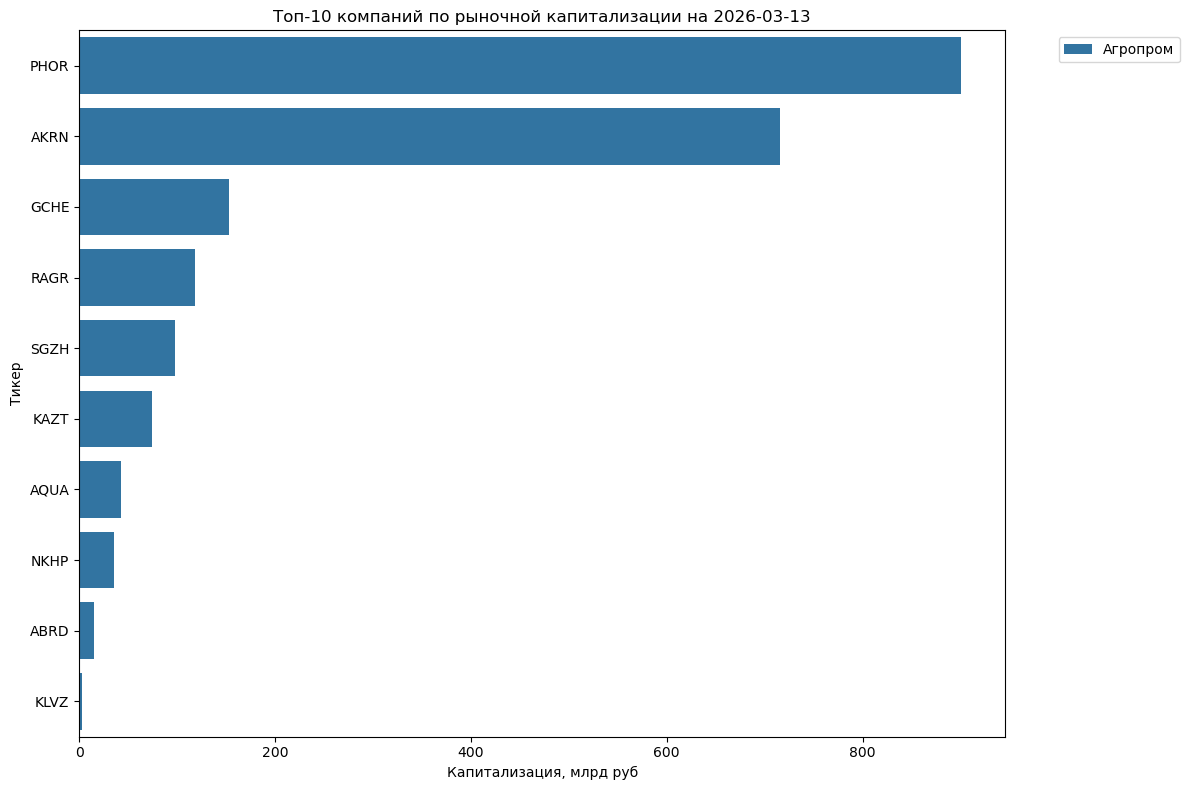

In [3]:
# ===================== ВИЗУАЛИЗАЦИЯ =====================
if 'MarketCap' in df_fund.columns and not df_fund.empty:
    prelim_cap = df_fund[['MarketCap', 'Sector']].copy()
    prelim_cap = prelim_cap.dropna(subset=['MarketCap'])
    prelim_cap = prelim_cap[prelim_cap['MarketCap'] > 0]
    if not prelim_cap.empty:
        sorted_cap = prelim_cap.sort_values(by='MarketCap', ascending=False)
        
        date_today = datetime.now().strftime('%Y-%m-%d')
        top_n = min(len(selected_tickers), len(sorted_cap))
        
        plt.figure(figsize=(12, 8))
        top_df = sorted_cap.head(top_n).reset_index()
        if 'Sector' in top_df.columns and top_df['Sector'].notna().any():
            sns.barplot(data=top_df, x='MarketCap', y='Ticker', hue='Sector', dodge=False)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            sns.barplot(data=top_df, x='MarketCap', y='Ticker')
        plt.title(f'Топ-{top_n} компаний по рыночной капитализации на {date_today}')
        plt.xlabel('Капитализация, млрд руб')
        plt.ylabel('Тикер')
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных о капитализации после фильтрации.")
else:
    print("Колонка MarketCap отсутствует или DataFrame пуст, визуализация невозможна.")

*Зависимость оборота компаний от капитализации*

Доступные колонки в df_fund: ['Revenue', 'EBITDA', 'NetIncome', 'MarketCap', 'Price', 'Shares', 'NetDebt', 'Debt', 'Cash', 'Dividend', 'FCF', 'CAPEX', 'EPS', 'BVPS', 'Assets', 'Equity', 'ROE_raw', 'ROA_raw', 'PE_raw', 'PB_raw', 'EVEBITDA_raw', 'PS_raw', 'DebtEBITDA_raw', 'FreeFloat', 'Interest', 'OperExpenses', 'OperatingProfit', 'AnnualReport', 'IR_rating', 'ReportQuality', 'Presentations', 'SmartlabPresence', 'InvestorSite', 'InvestorCalendar', 'Feedback', 'Sector', 'P/B', 'P/E', 'P/S', 'EV', 'EV/EBITDA', 'NetDebt/EBITDA', 'DivYield', 'Turnover', 'BidOrders', 'AskOrders', 'Debt/Equity', 'InterestCoverage', 'OER', 'AssetTurnover']
Среднее количество заявок рассчитано.

ТОП-10 КОМПАНИЙ ПО РЫНОЧНОЙ КАПИТАЛИЗАЦИИ
        MarketCap
Ticker           
PHOR       900.70
AKRN       715.60
GCHE       153.10
RAGR       117.90
SGZH        97.90
KAZT        74.30
AQUA        42.70
NKHP        35.70
ABRD        15.60
KLVZ         2.97


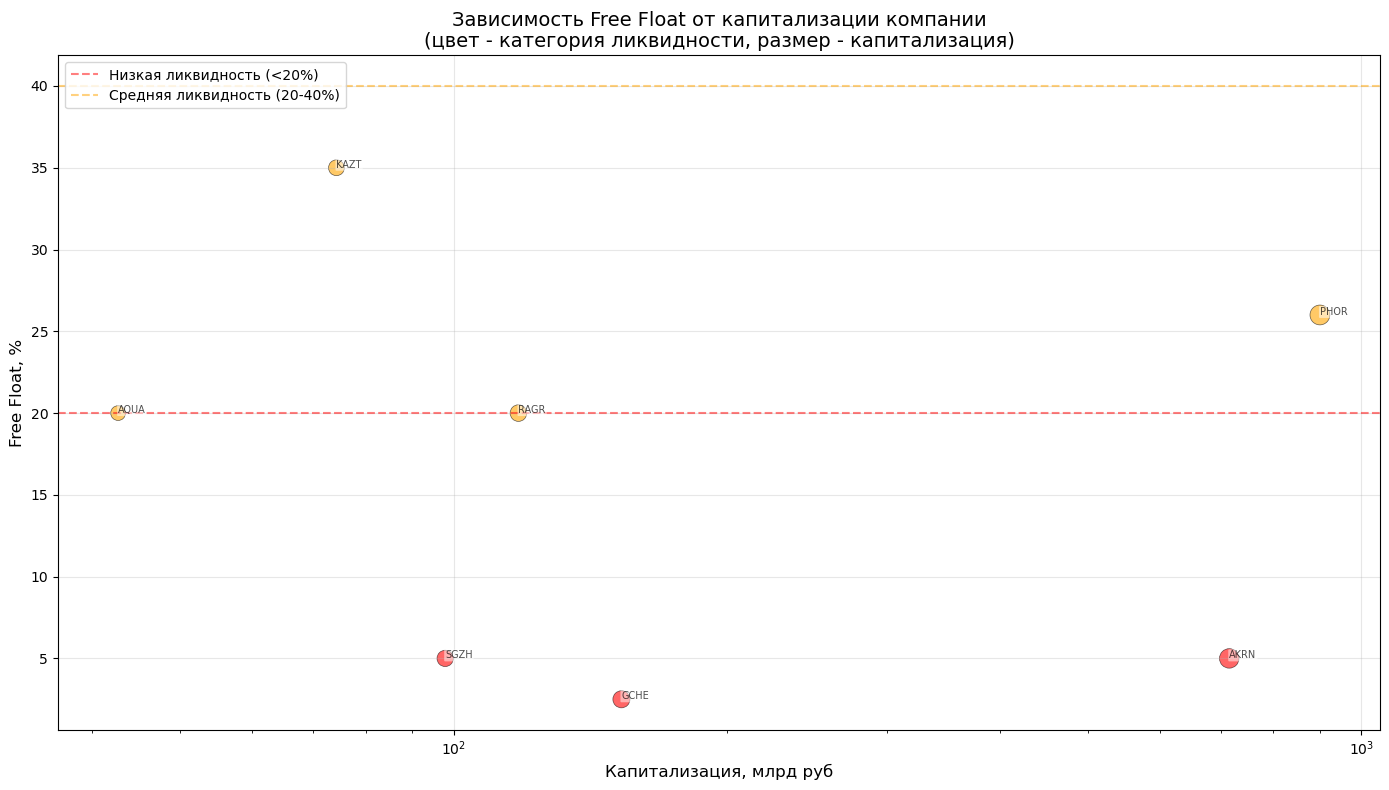

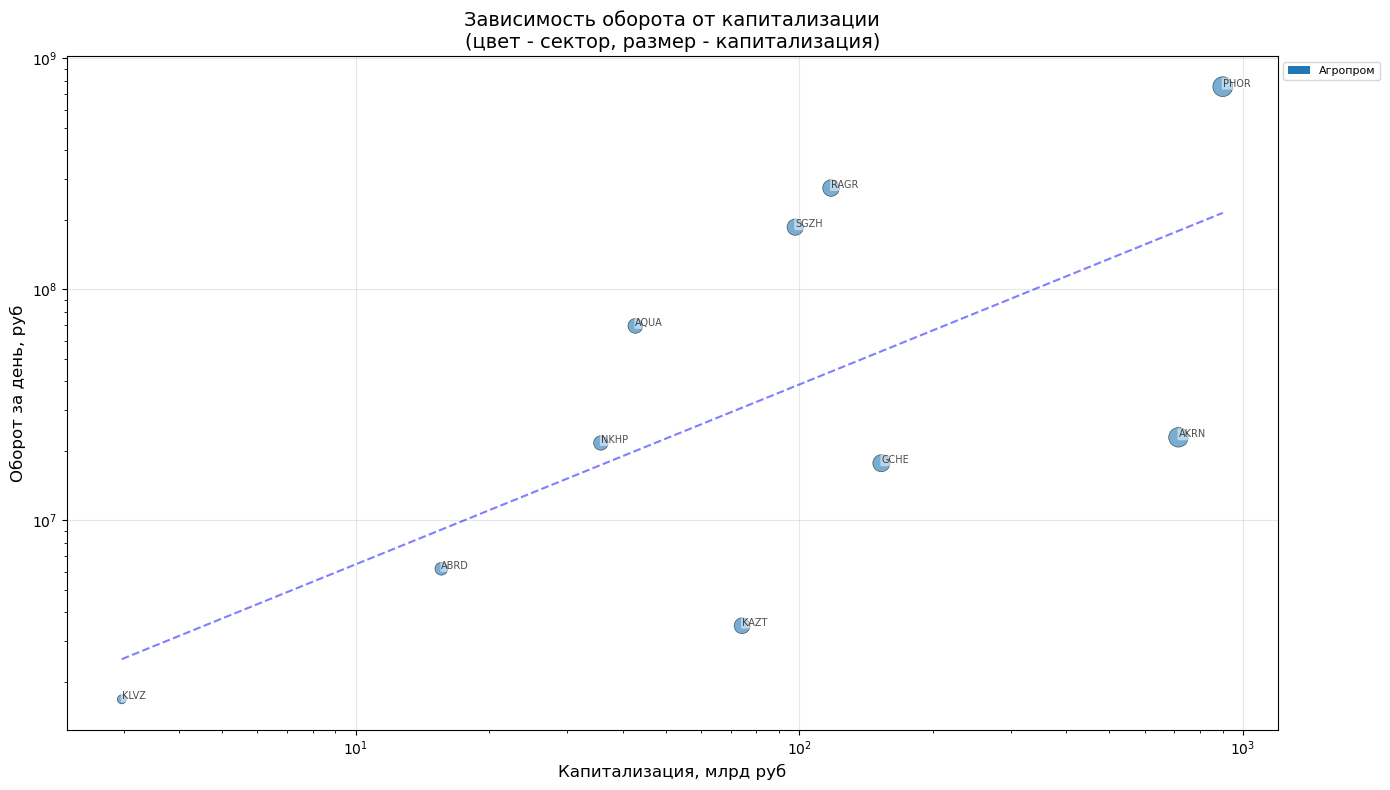

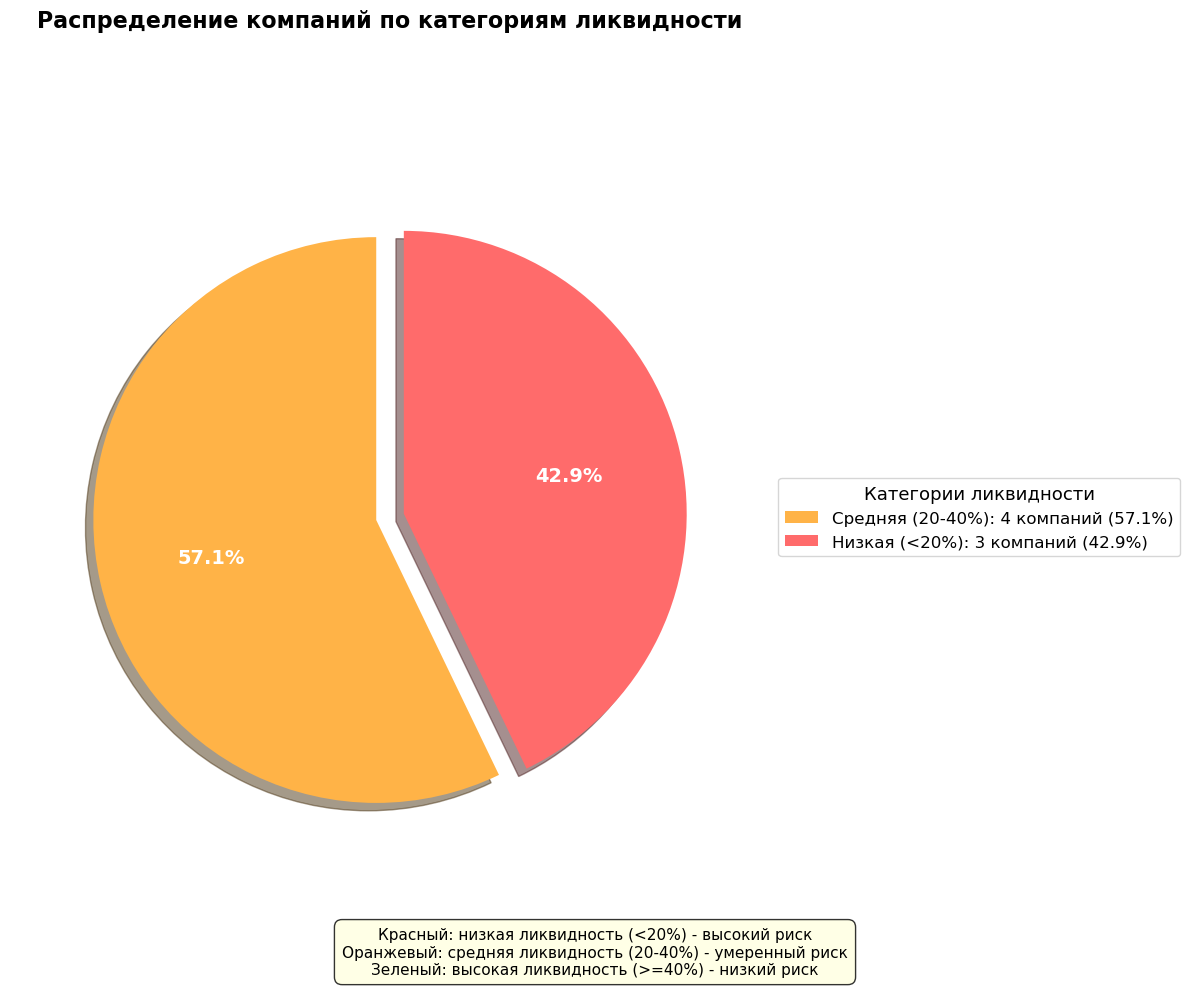


СТАТИСТИКА ПО КАТЕГОРИЯМ ЛИКВИДНОСТИ
Средняя (20-40%): 4 компаний (57.1%)
Низкая (<20%): 3 компаний (42.9%)


In [4]:
# Этап 1. Предварительная оценка (улучшенная визуализация + CSV-таблицы)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Проверяем, какие колонки есть в df_fund
print("Доступные колонки в df_fund:", df_fund.columns.tolist())

# Создаём копию с нужными колонками
preliminary = pd.DataFrame(index=df_fund.index)

if 'MarketCap' in df_fund.columns:
    preliminary['MarketCap'] = df_fund['MarketCap']
else:
    print("Колонка MarketCap отсутствует. Дальнейший анализ невозможен.")

if 'FreeFloat' in df_fund.columns:
    preliminary['FreeFloat'] = df_fund['FreeFloat']

if 'Turnover' in df_fund.columns:
    preliminary['Turnover'] = df_fund['Turnover']

if 'BidOrders' in df_fund.columns:
    preliminary['BidOrders'] = df_fund['BidOrders']

if 'AskOrders' in df_fund.columns:
    preliminary['AskOrders'] = df_fund['AskOrders']

if 'Sector' in df_fund.columns:
    preliminary['Sector'] = df_fund['Sector']

# Рассчитываем среднее количество заявок
if 'BidOrders' in preliminary.columns and 'AskOrders' in preliminary.columns:
    preliminary['AvgOrders'] = (preliminary['BidOrders'] + preliminary['AskOrders']) / 2
    print("Среднее количество заявок рассчитано.")
else:
    print("Колонки BidOrders и/или AskOrders отсутствуют – AvgOrders не рассчитан.")

# --- Топ-10 по капитализации ---
if 'MarketCap' in preliminary.columns:
    top10 = preliminary.nlargest(10, 'MarketCap')[['MarketCap']]
    print("\n" + "="*60)
    print("ТОП-10 КОМПАНИЙ ПО РЫНОЧНОЙ КАПИТАЛИЗАЦИИ")
    print("="*60)
    print(top10.to_string())
else:
    print("\nНет данных о капитализации для топа.")

# =====================================================================
# ГРАФИК 1: Scatter plot Free Float vs Капитализация
# =====================================================================
plt.figure(figsize=(14, 8))

if 'FreeFloat' in preliminary.columns and 'MarketCap' in preliminary.columns:
    scatter_data_ff = preliminary[['MarketCap', 'FreeFloat', 'Sector']].dropna()
    scatter_data_ff = scatter_data_ff[(scatter_data_ff['MarketCap'] > 0) & (scatter_data_ff['FreeFloat'].notna())]
    
    if len(scatter_data_ff) > 0:
        # Определяем категории ликвидности для цветовой дифференциации
        low_threshold = 20
        medium_threshold = 40
        
        # Создаем массив цветов в зависимости от free float
        colors = []
        for ff in scatter_data_ff['FreeFloat']:
            if ff < low_threshold:
                colors.append('red')
            elif ff < medium_threshold:
                colors.append('orange')
            else:
                colors.append('green')
        
        # Размер точек зависит от капитализации
        sizes = np.log1p(scatter_data_ff['MarketCap']) * 30
        
        plt.scatter(scatter_data_ff['MarketCap'], scatter_data_ff['FreeFloat'], 
                   c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)
        
        # Добавляем линии порогов
        plt.axhline(y=low_threshold, color='red', linestyle='--', alpha=0.5, 
                   label=f'Низкая ликвидность (<{low_threshold}%)')
        plt.axhline(y=medium_threshold, color='orange', linestyle='--', alpha=0.5, 
                   label=f'Средняя ликвидность ({low_threshold}-{medium_threshold}%)')
        
        # Подписываем ВСЕ компании
        for ticker, row in scatter_data_ff.iterrows():
            plt.annotate(ticker, (row['MarketCap'], row['FreeFloat']),
                        fontsize=7, alpha=0.7,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))
        
        plt.xlabel('Капитализация, млрд руб', fontsize=12)
        plt.ylabel('Free Float, %', fontsize=12)
        plt.title('Зависимость Free Float от капитализации компании\n(цвет - категория ликвидности, размер - капитализация)', fontsize=14)
        plt.xscale('log')
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для построения графика зависимости Free Float от капитализации.")
else:
    print("Отсутствуют данные по Free Float или MarketCap.")

# =====================================================================
# ГРАФИК 2: Scatter plot Зависимость оборота от капитализации
# =====================================================================
plt.figure(figsize=(14, 8))

if 'MarketCap' in preliminary.columns and 'Turnover' in preliminary.columns:
    scatter_data_turnover = preliminary[['MarketCap', 'Turnover', 'Sector']].dropna()
    scatter_data_turnover = scatter_data_turnover[(scatter_data_turnover['MarketCap'] > 0) & (scatter_data_turnover['Turnover'] > 0)]
    
    if len(scatter_data_turnover) > 0:
        # Цвет в зависимости от сектора (если есть)
        if 'Sector' in scatter_data_turnover.columns:
            # Получаем уникальные сектора и создаем палитру
            sectors = scatter_data_turnover['Sector'].dropna()
            unique_sectors = sectors.unique()
            color_palette = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
            sector_to_color = {sector: color_palette[i] for i, sector in enumerate(unique_sectors)}
            
            # Применяем цвета к точкам
            point_colors = [sector_to_color.get(row['Sector'], 'gray') 
                           for idx, row in scatter_data_turnover.iterrows()]
        else:
            point_colors = 'steelblue'
        
        # Размер точек зависит от капитализации
        sizes = np.log1p(scatter_data_turnover['MarketCap']) * 30
        
        plt.scatter(scatter_data_turnover['MarketCap'], scatter_data_turnover['Turnover'], 
                   c=point_colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)
        
        # Добавляем линию тренда (для наглядности)
        z = np.polyfit(np.log(scatter_data_turnover['MarketCap']), np.log(scatter_data_turnover['Turnover']), 1)
        p = np.poly1d(z)
        x_trend = np.linspace(scatter_data_turnover['MarketCap'].min(), scatter_data_turnover['MarketCap'].max(), 100)
        plt.plot(x_trend, np.exp(p(np.log(x_trend))), 'b--', alpha=0.5, label='Линия тренда')
        
        # Подписываем ВСЕ компании
        for ticker, row in scatter_data_turnover.iterrows():
            plt.annotate(ticker, (row['MarketCap'], row['Turnover']),
                        fontsize=7, alpha=0.7,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))
        
        plt.xlabel('Капитализация, млрд руб', fontsize=12)
        plt.ylabel('Оборот за день, руб', fontsize=12)
        plt.title('Зависимость оборота от капитализации\n(цвет - сектор, размер - капитализация)', fontsize=14)
        plt.xscale('log')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        # Добавляем легенду для секторов
        if 'Sector' in scatter_data_turnover.columns and point_colors != 'steelblue':
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_to_color[s], label=s) 
                              for s in unique_sectors[:10]]  # Ограничим до 10 секторов для читаемости
            if len(unique_sectors) > 10:
                legend_elements.append(Patch(facecolor='gray', label='... и другие'))
            plt.legend(handles=legend_elements, loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
        else:
            plt.legend(['Линия тренда'], loc='upper left')
        
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для построения графика зависимости оборота от капитализации.")
else:
    print("Отсутствуют данные по MarketCap или Turnover.")

# =====================================================================
# ГРАФИК 3: Круговая диаграмма распределения по категориям ликвидности
# =====================================================================
if 'FreeFloat' in preliminary.columns:
    ff_data = preliminary[['FreeFloat']].dropna()
    
    if len(ff_data) > 0:
        # Категоризируем
        low_threshold = 20
        medium_threshold = 40
        
        def get_category(ff):
            if ff < low_threshold:
                return f'Низкая (<{low_threshold}%)'
            elif ff < medium_threshold:
                return f'Средняя ({low_threshold}-{medium_threshold}%)'
            else:
                return f'Высокая (>={medium_threshold}%)'
        
        ff_data['Категория'] = ff_data['FreeFloat'].apply(get_category)
        category_counts = ff_data['Категория'].value_counts()
        
        # Создаем круговую диаграмму с пояснениями
        plt.figure(figsize=(12, 10))
        
        # Цвета для категорий (словарь)
        category_colors = {
            f'Низкая (<{low_threshold}%)': '#ff6b6b',
            f'Средняя ({low_threshold}-{medium_threshold}%)': '#ffb347',
            f'Высокая (>={medium_threshold}%)': '#66bb6a'
        }
        colors_pie = [category_colors[cat] for cat in category_counts.index]
        
        # Динамический explode (одинаковый отступ для всех секторов)
        explode = [0.05] * len(category_counts)
        
        # Настройки для отображения
        wedges, texts, autotexts = plt.pie(category_counts.values, 
                                           labels=None,
                                           autopct='%1.1f%%',
                                           colors=colors_pie,
                                           explode=explode,
                                           shadow=True,
                                           startangle=90,
                                           textprops={'fontsize': 14, 'fontweight': 'bold'})
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(14)
        
        plt.title('Распределение компаний по категориям ликвидности', fontsize=16, fontweight='bold', pad=20)
        
        legend_labels = [f'{cat}: {count} компаний ({count/len(ff_data)*100:.1f}%)' 
                        for cat, count in zip(category_counts.index, category_counts.values)]
        plt.legend(wedges, legend_labels, title="Категории ликвидности",
                  loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12,
                  title_fontsize=13)
        
        plt.figtext(0.5, 0.02, 
                   f'Красный: низкая ликвидность (<{low_threshold}%) - высокий риск\n'
                   f'Оранжевый: средняя ликвидность ({low_threshold}-{medium_threshold}%) - умеренный риск\n'
                   f'Зеленый: высокая ликвидность (>={medium_threshold}%) - низкий риск',
                   ha='center', fontsize=11, 
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=0.5))
        
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*60)
        print("СТАТИСТИКА ПО КАТЕГОРИЯМ ЛИКВИДНОСТИ")
        print("="*60)
        for cat in category_counts.index:
            count = category_counts[cat]
            percent = count/len(ff_data)*100
            print(f"{cat}: {count} компаний ({percent:.1f}%)")
    else:
        print("Нет данных по free float для построения круговой диаграммы.")

# =====================================================================
# CSV ТАБЛИЦА 1: Данные для графика Free Float vs Капитализация
# =====================================================================
if 'FreeFloat' in preliminary.columns and 'MarketCap' in preliminary.columns:
    # print("\n" + "="*80)
    # print("CSV ТАБЛИЦА 1: ДАННЫЕ ДЛЯ ГРАФИКА FREE FLOAT VS КАПИТАЛИЗАЦИЯ")
    # print("="*80)
    # print("(Можно скопировать и вставить в Excel)")
    # print("-" * 80)
    
    # Создаем DataFrame для экспорта
    ff_export = scatter_data_ff.copy()
    
    # Добавляем категорию ликвидности
    low_threshold = 20
    medium_threshold = 40
    
    def get_category_name(ff):
        if ff < low_threshold:
            return f'Низкая (<{low_threshold}%)'
        elif ff < medium_threshold:
            return f'Средняя ({low_threshold}-{medium_threshold}%)'
        else:
            return f'Высокая (>={medium_threshold}%)'
    
    ff_export['Категория ликвидности'] = ff_export['FreeFloat'].apply(get_category_name)
    ff_export = ff_export.reset_index()
    ff_export.columns = ['Тикер', 'Капитализация млрд руб', 'Free Float %', 'Сектор', 'Категория ликвидности']
    
    # Выводим в формате CSV
    # print(ff_export.to_csv(index=False, sep=';', float_format='%.2f'))
    
    # Сохраняем в файл (опционально)
    # ff_export.to_csv('C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/free_float_vs_cap.csv', index=False, sep=';', float_format='%.2f')
    # print(f"\n✅ Файл сохранен: free_float_vs_cap.csv")

# =====================================================================
# CSV ТАБЛИЦА 2: Данные для графика Оборот vs Капитализация
# =====================================================================
if 'MarketCap' in preliminary.columns and 'Turnover' in preliminary.columns:
    # print("\n" + "="*80)
    # print("CSV ТАБЛИЦА 2: ДАННЫЕ ДЛЯ ГРАФИКА ОБОРОТ VS КАПИТАЛИЗАЦИЯ")
    # print("="*80)
    # print("(Можно скопировать и вставить в Excel)")
    # print("-" * 80)
    
    # Создаем DataFrame для экспорта
    turnover_export = scatter_data_turnover.copy()
    turnover_export = turnover_export.reset_index()
    turnover_export.columns = ['Тикер', 'Капитализация млрд руб', 'Оборот за день руб', 'Сектор']
    
    # Выводим в формате CSV
    # print(turnover_export.to_csv(index=False, sep=';', float_format='%.2f'))
    
    # Сохраняем в файл (опционально)
    # turnover_export.to_csv('C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/turnover_vs_cap.csv', index=False, sep=';', float_format='%.2f')
    # print(f"\n✅ Файл сохранен: turnover_vs_cap.csv")

# =====================================================================
# СВОДНАЯ ТАБЛИЦА: Все данные по ликвидности вместе
# =====================================================================
# print("\n" + "="*80)
# print("СВОДНАЯ ТАБЛИЦА ВСЕХ ДАННЫХ ПО ЛИКВИДНОСТИ")
# print("="*80)
# print("(Можно скопировать и вставить в Excel)")
# print("-" * 80)

# Собираем все доступные данные
all_data = preliminary.copy()

# Добавляем расчетные показатели
if 'Turnover' in all_data.columns and 'MarketCap' in all_data.columns:
    all_data['Коэффициент ликвидности (оборот/кап)'] = all_data['Turnover'] / all_data['MarketCap']

if 'BidOrders' in all_data.columns and 'AskOrders' in all_data.columns:
    all_data['Среднее кол-во заявок'] = (all_data['BidOrders'] + all_data['AskOrders']) / 2

# Добавляем категорию ликвидности по free float
if 'FreeFloat' in all_data.columns:
    all_data['Категория ликвидности'] = all_data['FreeFloat'].apply(
        lambda x: f'Низкая (<{low_threshold}%)' if x < low_threshold 
        else (f'Средняя ({low_threshold}-{medium_threshold}%)' if x < medium_threshold 
              else f'Высокая (>={medium_threshold}%)') if pd.notna(x) else np.nan
    )

# Сбрасываем индекс для экспорта
all_data_export = all_data.reset_index()
all_data_export = all_data_export.rename(columns={'index': 'Тикер'})

# Выбираем только релевантные колонки
export_cols = ['Тикер', 'Sector', 'MarketCap', 'FreeFloat', 'Turnover', 
               'Коэффициент ликвидности (оборот/кап)', 'Среднее кол-во заявок', 
               'Категория ликвидности', 'BidOrders', 'AskOrders']
export_cols = [col for col in export_cols if col in all_data_export.columns]

all_data_export = all_data_export[export_cols]

# Выводим в формате CSV
# print(all_data_export.to_csv(index=False, sep=';', float_format='%.2f'))

# Сохраняем в файл
# all_data_export.to_csv('C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/liquidity_all_data.csv', index=False, sep=';', float_format='%.2f')
# print(f"\n✅ Файл сохранен: liquidity_all_data.csv")

# 📊 Пояснения к графикам предварительной оценки для инвесторов

## 🎯 Что мы анализируем на этом этапе?

На этом этапе мы оцениваем **ликвидность акций** - насколько легко можно купить или продать акции компании без сильного изменения цены. Это как проверить, насколько "текучая" вода в стакане: если вода жидкая (высокая ликвидность), то ложка легко двигается; если густая (низкая ликвидность), то ложку двигать трудно.

---

## 📈 График 1: Зависимость Free Float от капитализации компании

### Что такое Free Float?
**Free Float** - это доля акций компании, которые свободно торгуются на бирже. Если проще: это те акции, которые можно купить на рынке. Остальные акции обычно принадлежат крупным акционерам, государству или основателям компании.

### Что означают цвета точек:
- **🔴 Красные точки** - низкая ликвидность (Free Float < 20%)
  - Такие акции трудно продать быстро
  - При продаже крупного пакета цена может сильно упасть
  - Обычно это компании с одним крупным владельцем

- **🟠 Оранжевые точки** - средняя ликвидность (Free Float 20-40%)
  - Нормальный уровень для большинства компаний
  - Можно торговать без особых проблем
  - Компромисс между доходностью и риском

- **🟢 Зеленые точки** - высокая ликвидность (Free Float > 40%)
  - Акции легко купить и продать в любой момент
  - Низкие спреды (разница между ценой покупки и продажи)
  - Обычно это голубые фишки, самые популярные компании

### Размер точек
Чем больше точка, тем крупнее компания (выше капитализация). Крупные компании обычно имеют и более высокую ликвидность.

### Как интерпретировать:
1. **Если точка в правом верхнем углу** (большая капитализация и высокий Free Float) - отлично! Это крупная компания с хорошей ликвидностью.
2. **Если точка в левом нижнем углу** (маленькая капитализация и низкий Free Float) - осторожно! Акции могут быть очень трудны для продажи.
3. **Смотрите на тренд**: обычно крупные компании имеют более высокий Free Float. Если крупная компания имеет низкий Free Float (красная точка справа) - это повод задуматься, почему так происходит.

---

## 📊 График 2: Зависимость оборота от капитализации

### Что такое оборот?
**Оборот (Turnover)** - это сколько денег проходит через акцию за один день торгов. Если проще: это "тусовка" вокруг акции - много народу покупает и продает.

### Что показывает красная пунктирная линия?
Это **линия тренда**. В идеале все точки должны лежать на этой линии - чем крупнее компания, тем выше оборот.

### Точки выше линии тренда:
- **🚀 Сверхликвидные "фишки"**
- Пример: Сбер, Газпром, Лукойл
- В такие акции можно заходить с любыми деньгами
- Спред (разница между покупкой и продажей) минимальный
- **Для инвестора**: комфортно, можно не думать о ликвидности

### Точки ниже линии тренда:
- **🐢 Низколиквидные акции**
- Пример: небольшие компании второго эшелона
- При попытке продать крупный пакет цена может упасть на 1-3%
- Может быть сложно выйти из позиции
- **Для инвестора**: риск "застрять" в акции

### Как интерпретировать:
1. **Точки в правом верхнем углу** - мечта инвестора: крупные компании с огромным оборотом. Туда можно заходить смело.
2. **Точки в левом нижнем углу** - зона риска: маленькие компании с низким оборотом. Лучше обходить стороной, если вы не готовы к сложностям.
3. **Сравнивайте с линией тренда**: если точка сильно ниже - это "звоночек". Почему при такой капитализации такой низкий оборот? Может быть, акция непопулярна или есть проблемы.

---

## 🥧 График 3: Круговая диаграмма распределения по категориям ликвидности

### Что это?
Простое и наглядное распределение всех компаний по категориям ликвидности.

### Как читать


### Цвета:
- ** Красный сегмент** - сколько компаний с низкой ликвидностью
- ** Оранжевый сегмент** - сколько со средней ликвидностью
- ** Зеленый сегмент** - сколько с высокой ликвидностью

### Как интерпретировать:
- Если красный сегмент большой (>50%) - рынок в целом низколиквидный. Нужно быть очень осторожным с выбором акций.
- Если зеленый сегмент большой (>40%) - рынок зрелый, много ликвидных инструментов. Можно торговать смелее.
- Если оранжевый сегмент доминирует - смешанный рынок, нужно смотреть по каждой компании отдельно.

---

## 📋 Таблицы CSV для скачивания

### Что в них?

**Таблица 1: Free Float vs Капитализация**

| Тикер | Капитализация | Free Float | Сектор | Категория ликвидности |
|-------|---------------|------------|--------|----------------------|
| SBER  | 5,800 млрд    | 48%        | Финансы| Высокая (>40%)       |
| GAZP  | 3,200 млрд    | 47%        | Добыча | Высокая (>40%)       |

**Как использовать**: Скопируйте в Excel, сортируйте по категориям, ищите компании с высоким Free Float для безопасной торговли.

**Таблица 2: Оборот vs Капитализация**

| Тикер | Капитализация | Оборот за день | Сектор |
|-------|---------------|----------------|--------|
| SBER  | 5,800 млрд    | 21 млрд руб    | Финансы|

**Как использовать**: 
Сортируйте по обороту - самые ликвидные компании будут сверху. Отлично для поиска "голубых фишек".

**Таблица 3: Все данные вместе**
- Сводная таблица со всеми показателями ликвидности
- Удобно для комплексного анализа
- Можно строить свои графики и сводные таблицы в Excel

---

## 🎯 Итоговые рекомендации для новичка

### Что считать "хорошим" показателем:

| Показатель | Плохо | Нормально | Отлично |
|------------|-------|-----------|---------|
| **Free Float** | < 20% | 20-40% | > 40% |
| **Оборот за день** | < 10 млн руб | 10-100 млн руб | > 100 млн руб |
| **Положение на графике** | ниже линии тренда | на линии тренда | выше линии тренда |

### Простой алгоритм выбора акций:
1. **Шаг 1**: Откройте CSV-таблицу с данными
2. **Шаг 2**: Отфильтруйте компании с Free Float > 20% (убираем рискованные)
3. **Шаг 3**: Отсортируйте по обороту (чем выше, тем лучше)
4. **Шаг 4**: Проверьте на графике - компания должна быть не ниже линии тренда
5. **Шаг 5**: Выбирайте из топ-20 по обороту

### 🚩 Красные флаги (чего избегать):
- Free Float < 10% - "игрушечные" акции
- Оборот < 1 млн руб в день - продать потом будет невозможно
- Точка сильно ниже линии тренда - возможно, акция "мертвая"

### ✅ Зеленый свет (что искать):
- Free Float > 40% - свободное плавание
- Оборот > 100 млн руб - высокая активность
- Точка выше линии тренда - любимчик рынка

---

## 📌 Важное предупреждение

Помните: **ликвидность - это не про прибыльность**. Высоколиквидная акция может быть убыточной, а низколиквидная - очень доходной. Ликвидность говорит только о том, насколько легко вы сможете выйти из позиции. Это как дверь - если она широкая, вы быстро выйдете, но это не значит, что за дверью вас ждет прибыль.

**Золотое правило**: сначала ищите прибыльные компании, а потом проверяйте их ликвидность. Или наоборот - зависит от вашей стратегии. Но никогда не игнорируйте ликвидность полностью!

<div class="alert alert-info">
</div>

**Этап 2. Финансовый анализ**

2.1. Показатели эффективности (ROE, ROA, ROS)

Средние значения по секторам (в %):
          ROE_raw  ROA_raw  EBITDAMargin_plot
Sector                                       
Агропром     11.8      7.9               26.1

📊 Сектор: Агропром


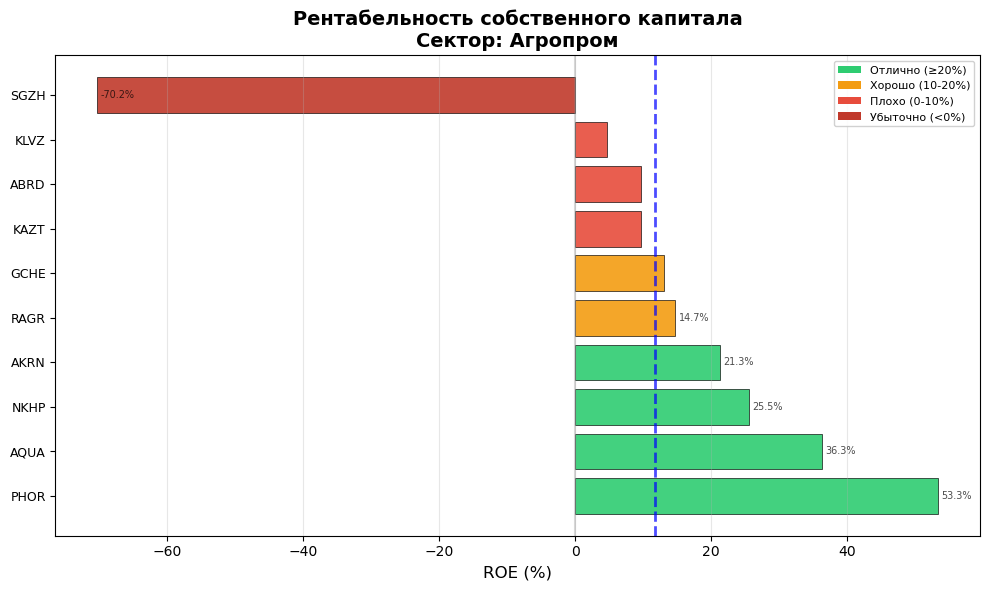

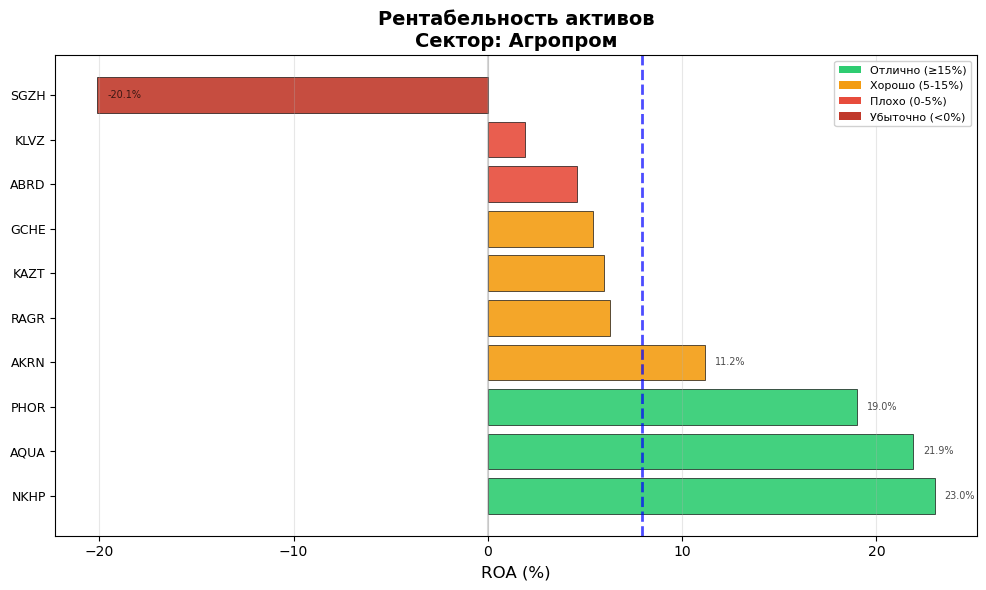

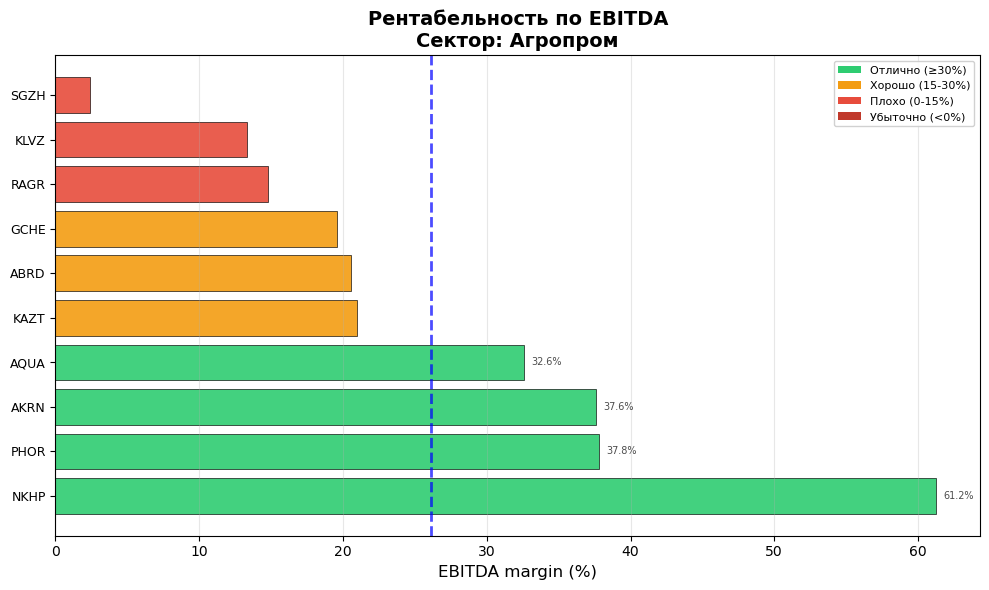

In [5]:
# 2.1. Показатели эффективности (ROE, ROA, EBITDA margin) — отдельные графики с подписями экстремумов

# %%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Убедимся, что у нас есть колонки с секторами
df_eff = df_fund.dropna(subset=['Sector']).copy()

# Проверим наличие нужных колонок
required_roe = 'ROE_raw' in df_eff.columns
required_roa = 'ROA_raw' in df_eff.columns
required_margin = 'EBITDA' in df_eff.columns and 'Revenue' in df_eff.columns

if not required_roe:
    print("Внимание: колонка ROE_raw отсутствует, график ROE не будет построен.")
if not required_roa:
    print("Внимание: колонка ROA_raw отсутствует, график ROA не будет построен.")
if not required_margin:
    print("Внимание: для расчёта EBITDA margin необходимы колонки EBITDA и Revenue.")

# Подготовим данные для графиков
if required_roe:
    df_eff['ROE_plot'] = df_eff['ROE_raw'] * 1  # уже в процентах
if required_roa:
    df_eff['ROA_plot'] = df_eff['ROA_raw'] * 1  # уже в процентах
if required_margin:
    # Избегаем деления на ноль
    mask = (df_eff['Revenue'].notna()) & (df_eff['Revenue'] != 0) & (df_eff['EBITDA'].notna())
    df_eff['EBITDAMargin_plot'] = np.nan
    df_eff.loc[mask, 'EBITDAMargin_plot'] = (df_eff.loc[mask, 'EBITDA'] / df_eff.loc[mask, 'Revenue']) * 100

# Функция для добавления подписей максимума и минимума для каждого сектора (безопасная версия)
def annotate_min_max(ax, data, x_col, y_col, group_col, margin=0.1, suffix='%'):
    # Удаляем строки с NaN в анализируемой колонке
    data_clean = data.dropna(subset=[y_col])
    if data_clean.empty:
        return
    groups = data_clean[group_col].unique()
    y_min_global = data_clean[y_col].min()
    y_max_global = data_clean[y_col].max()
    y_range = y_max_global - y_min_global
    offset = y_range * margin

    for i, group in enumerate(groups):
        subset = data_clean[data_clean[group_col] == group]
        if len(subset) == 0:
            continue
        if subset[y_col].isnull().all():
            continue
        # Находим индексы максимума и минимума
        max_idx = subset[y_col].idxmax()
        min_idx = subset[y_col].idxmin()
        if pd.isna(max_idx) or pd.isna(min_idx):
            continue
        max_val = subset.loc[max_idx, y_col]
        min_val = subset.loc[min_idx, y_col]

        # Подпись максимума (зелёная, сверху)
        ax.text(i, max_val + offset/2, f'{max_idx}\n{max_val:.1f}{suffix}',
                ha='center', va='bottom', fontsize=7, color='green', alpha=0.8)
        # Подпись минимума (красная, снизу)
        ax.text(i, min_val - offset/2, f'{min_idx}\n{min_val:.1f}{suffix}',
                ha='center', va='top', fontsize=7, color='red', alpha=0.8)

    # Расширяем границы, чтобы подписи не обрезались
    ax.set_ylim(y_min_global - offset, y_max_global + offset)

# Таблица средних значений по секторам (в процентах)
sector_means = df_eff.groupby('Sector')[['ROE_raw', 'ROA_raw']].mean().round(1)
if required_margin:
    margin_means = df_eff.groupby('Sector')['EBITDAMargin_plot'].mean().round(1)
    sector_means = sector_means.join(margin_means)
print("Средние значения по секторам (в %):")
print(sector_means)


        
        
        
# --- Визуализация показателей эффективности: горизонтальные столбчатые диаграммы по выбранным секторам с цветовой градацией ---

if required_roe or required_roa or required_margin:
    plot_data = df_eff.copy()
    
    def plot_bar_for_sector(sector, y_col, ylabel, title):
        """Строит горизонтальную столбчатую диаграмму для одного сектора с цветовой градацией"""
        data = plot_data[plot_data['Sector'] == sector].dropna(subset=[y_col]).copy()
        if data.empty:
            print(f"Нет данных по {ylabel} для сектора {sector}")
            return
        
        # Сортируем от лучшего (максимального) к худшему (минимальному)
        data = data.sort_values(y_col, ascending=False)
        data['Ticker'] = data.index
        data.reset_index(drop=True, inplace=True)
        data['pos'] = range(len(data))
        
        # Рассчитываем среднее по сектору
        mean_val = data[y_col].mean()
        
        # Определяем пороги для цветовой градации в зависимости от показателя
        if y_col == 'ROE_plot':
            thresholds = {'отлично': 20, 'хорошо': 10, 'плохо': 0}
            colors_map = {'отлично': '#2ecc71',   # зелёный
                          'хорошо': '#f39c12',    # оранжевый
                          'плохо': '#e74c3c',     # красный
                          'убыточно': '#c0392b'}  # тёмно-красный
        elif y_col == 'ROA_plot':
            thresholds = {'отлично': 15, 'хорошо': 5, 'плохо': 0}
            colors_map = {'отлично': '#2ecc71',
                          'хорошо': '#f39c12',
                          'плохо': '#e74c3c',
                          'убыточно': '#c0392b'}
        elif y_col == 'EBITDAMargin_plot':
            thresholds = {'отлично': 30, 'хорошо': 15, 'плохо': 0}
            colors_map = {'отлично': '#2ecc71',
                          'хорошо': '#f39c12',
                          'плохо': '#e74c3c',
                          'убыточно': '#c0392b'}
        else:
            thresholds = {'отлично': 999, 'хорошо': 0, 'плохо': -999}  # запасной вариант
            colors_map = {'отлично': '#2ecc71', 'хорошо': '#f39c12', 'плохо': '#e74c3c', 'убыточно': '#c0392b'}
        
        # Определяем цвет для каждого значения
        def get_color(val):
            if val >= thresholds['отлично']:
                return colors_map['отлично']
            elif val >= thresholds['хорошо']:
                return colors_map['хорошо']
            elif val >= thresholds['плохо']:
                return colors_map['плохо']
            else:
                return colors_map['убыточно']
        
        bar_colors = [get_color(v) for v in data[y_col]]
        
        # Настраиваем размер графика
        plt.figure(figsize=(10, max(6, len(data)*0.35)))
        ax = plt.gca()
        
        # Рисуем горизонтальные столбцы с цветовой градацией
        bars = ax.barh(data['pos'], data[y_col], color=bar_colors, alpha=0.9, edgecolor='black', linewidth=0.5)
        
        # Добавляем подписи компаний
        ax.set_yticks(data['pos'])
        ax.set_yticklabels(data['Ticker'], fontsize=9)
        
        # Вертикальная линия среднего значения
        ax.axvline(x=mean_val, color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Среднее по сектору: {mean_val:.1f}%')
        
        # Настраиваем оси
        ax.set_xlabel(ylabel, fontsize=12)
        ax.set_title(f'{title}\nСектор: {sector}', fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        ax.grid(axis='x', alpha=0.3)
        
        # Добавляем легенду для категорий
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=colors_map['отлично'], label=f'Отлично (≥{thresholds["отлично"]}%)'),
            Patch(facecolor=colors_map['хорошо'], label=f'Хорошо ({thresholds["хорошо"]}-{thresholds["отлично"]}%)'),
            Patch(facecolor=colors_map['плохо'], label=f'Плохо (0-{thresholds["хорошо"]}%)'),
            Patch(facecolor=colors_map['убыточно'], label='Убыточно (<0%)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)
        
        # Добавляем подписи значений у самых длинных столбцов и отрицательных (опционально)
        for i, (val, ticker) in enumerate(zip(data[y_col], data['Ticker'])):
            if val > mean_val * 1.2 or val < 0:
                ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=7, alpha=0.7)
        
        plt.tight_layout()
        plt.show()
    
    # Для каждого выбранного сектора строим графики по каждому показателю
    for sector in SECTOR_LIST:
        if sector not in plot_data['Sector'].unique():
            print(f"⚠️ Сектор '{sector}' отсутствует в данных. Пропускаем.")
            continue
        
        print(f"\n📊 Сектор: {sector}")
        if required_roe:
            plot_bar_for_sector(sector, 'ROE_plot', 'ROE (%)', 'Рентабельность собственного капитала')
        if required_roa:
            plot_bar_for_sector(sector, 'ROA_plot', 'ROA (%)', 'Рентабельность активов')
        if required_margin:
            plot_bar_for_sector(sector, 'EBITDAMargin_plot', 'EBITDA margin (%)', 'Рентабельность по EBITDA')     
        
        
        
        
# =====================================================================
# CSV ТАБЛИЦЫ С ДАННЫМИ ЭФФЕКТИВНОСТИ ДЛЯ АНАЛИЗА В EXCEL
# =====================================================================
# print("\n" + "="*80)
# print("CSV ТАБЛИЦА 1: ОБЩИЕ ДАННЫЕ ПО ЭФФЕКТИВНОСТИ (ВСЕ КОМПАНИИ)")
# print("="*80)
# print("(Можно скопировать и вставить в Excel)")
# print("-" * 80)

# Собираем доступные показатели
export_cols = ['Sector']
if required_roe:
    df_eff['ROE_%'] = df_eff['ROE_plot']
    export_cols.append('ROE_%')
if required_roa:
    df_eff['ROA_%'] = df_eff['ROA_plot']
    export_cols.append('ROA_%')
if required_margin:
    df_eff['EBITDAMargin_%'] = df_eff['EBITDAMargin_plot']
    export_cols.append('EBITDAMargin_%')

# Создаём DataFrame для экспорта (с тикером)
df_export = df_eff[export_cols].reset_index()
df_export.rename(columns={'index': 'Тикер'}, inplace=True)

# Выводим в CSV (разделитель точка с запятой для Excel)
# print(df_export.to_csv(index=False, sep=';', float_format='%.2f'))

# Сохраняем в файл (опционально)
# df_export.to_csv('C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/efficiency_all.csv', index=False, sep=';', float_format='%.2f')
# print(f"\n✅ Файл сохранен: efficiency_all.csv")

# --- Таблицы по секторам ---
if 'Sector' in df_eff.columns:
    # print("\n" + "="*80)
    # print("CSV ТАБЛИЦЫ ПО СЕКТОРАМ")
    # print("="*80)
    
    for sector in df_eff['Sector'].unique():
        sector_data = df_eff[df_eff['Sector'] == sector].copy()
        if len(sector_data) == 0:
            continue
            
        # Выбираем те же колонки
        sector_export = sector_data[export_cols].reset_index()
        sector_export.rename(columns={'index': 'Тикер'}, inplace=True)
        
        # print(f"\n--- Сектор: {sector} ---")
        # print(sector_export.to_csv(index=False, sep=';', float_format='%.2f'))
        
        # Сохраняем в отдельный файл
        # filename = f'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/efficiency_{sector.replace(" ", "_").replace("/", "_")}.csv'
        # sector_export.to_csv(filename, index=False, sep=';', float_format='%.2f')
        # print(f"✅ Файл сохранен: {filename}")

## 📈 Пояснения к блоку 2.1: Показатели эффективности (ROE, ROA, EBITDA margin)

На этом этапе мы анализируем три ключевых показателя рентабельности, которые показывают, насколько эффективно компания генерирует прибыль. Графики построены в виде **горизонтальных столбчатых диаграмм**, где каждая компания представлена отдельным столбиком, а цвет указывает на принадлежность к сектору.

---

### 🔍 Что означают эти показатели?

- **ROE (Return on Equity — рентабельность собственного капитала)**  
  Показывает, сколько чистой прибыли приносит каждый рубль, вложенный акционерами.  
  *Простыми словами:* насколько хорошо менеджмент распоряжается деньгами владельцев компании.  
  *Норма:* >15% считается хорошо, >20% — отлично. Но важно сравнивать внутри одного сектора.

- **ROA (Return on Assets — рентабельность активов)**  
  Отражает, сколько прибыли генерирует каждый рубль всех активов компании (и своих, и заёмных).  
  *Простыми словами:* насколько эффективно компания использует свои заводы, оборудование, деньги.  
  *Норма:* зависит от капиталоёмкости отрасли. Для металлургии 5–8% нормально, для IT может быть 15–20%.

- **EBITDA margin (рентабельность по EBITDA)**  
  Показывает, сколько операционной прибыли до вычета процентов, налогов и амортизации остаётся с каждого рубля выручки.  
  *Простыми словами:* сколько денег зарабатывает компания от своей основной деятельности.  
  *Норма:* >20% — отлично, 10–20% — средне, <10% — низкая операционная эффективность.

---

### 📊 Как читать горизонтальные столбчатые диаграммы

Для каждого показателя построен отдельный большой график.

- **Ось Y (вертикальная)** – перечислены все компании, сгруппированные по секторам. Внутри сектора компании отсортированы по убыванию значения показателя (сверху самые высокие, снизу самые низкие).  
- **Ось X (горизонтальная)** – значение показателя в процентах.
- **Цвет столбика** – сектор экономики (легенда справа).
- **Красная вертикальная линия** – нулевое значение (граница убыточности).

**Подписи максимума и минимума:**
- 🟢 **Зелёным** подписана компания с максимальным значением в своём секторе.
- 🔴 **Красным** подписана компания с минимальным значением в своём секторе.

**Разделители секторов** – горизонтальные серые линии помогают визуально отделить один сектор от другого.

---

### 🔎 Как интерпретировать графики

#### Сравнение внутри сектора
- В нижней части каждого сектора находятся **лидеры** – компании с самой высокой рентабельностью. Они отмечены зелёным.
- В верхней части – **аутсайдеры** (красные подписи). Если компания с красной подписью имеет отрицательное значение, это явный сигнал проблем.

#### Сравнение между секторами
- Обратите внимание на высоту столбиков: если в одном секторе все столбики длинные (например, IT), значит, этот сектор в целом более рентабельный.
- Если в секторе большой разброс (одни компании очень высокие, другие низкие) – это говорит о неоднородности: есть явные лидеры и отстающие.

#### Поиск инвестиционных идей
- Ищите компании с длинными столбиками (высокая рентабельность) и зелёной подпиской – они лидеры в своих секторах.
- Если компания с зелёной подпиской имеет значение значительно выше среднего по сектору, это может быть признаком устойчивого конкурентного преимущества.
- Компании с красной подпиской и очень низкими (особенно отрицательными) значениями требуют осторожности – возможно, у них серьёзные проблемы.

---

### 📋 Таблица средних значений по секторам

После графиков выводится таблица со средними значениями показателей для каждого сектора. Это нужно, чтобы понять, что считать «нормой» в конкретной отрасли.

| Сектор | ROE (%) | ROA (%) | EBITDA margin (%) |
|--------|---------|---------|-------------------|
| Финансы | 18.5 | 2.3 | NaN |
| Добыча | 22.1 | 12.4 | 35.6 |
| IT | 25.3 | 18.9 | 28.4 |

*Обратите внимание:* у финансового сектора EBITDA margin часто отсутствует (NaN), потому что для банков и страховых компаний этот показатель не рассчитывается – у них другая структура доходов. Для них важнее ROE и ROA.

---

### 🎯 Как использовать эту информацию для выбора инвестиций

1. **Сравнивайте компанию со средними по сектору**  
   Если ROE компании заметно выше средней по сектору, это может говорить о её конкурентном преимуществе. Если ниже – возможно, у неё проблемы.

2. **Смотрите на положение в секторе**  
   Компании в верхней части графика (с зелёными подписями) заслуживают внимания. Они – лучшие в своей отрасли.

3. **Анализируйте разброс**  
   Если в секторе большой разброс, значит, есть как сильные, так и слабые игроки. Инвестиции в лидеров могут быть предпочтительнее.

4. **Учитывайте отраслевую специфику**  
   В капиталоёмких отраслях (металлургия, энергетика) ROA и EBITDA margin обычно ниже, чем в IT или ритейле. Сравнивать компании из разных секторов напрямую нельзя.

5. **Не делайте выводы по одному показателю**  
   Высокий ROE может быть следствием большого долга (левериджа), а не реальной эффективности. Всегда проверяйте долговую нагрузку (этап 2.2) и денежные потоки (этап 3).

---

### ⚠️ Важное предостережение

Все показатели рассчитаны по **последней отчётности**. Рентабельность может сильно меняться год от года. Для окончательных выводов всегда анализируйте динамику за 3–5 лет (этот блок можно добавить позже). Графики дают лишь снимок текущего состояния, но это отличная отправная точка для поиска интересных компаний.

2.2. Платежеспособность

Описательная статистика коэффициентов платежеспособности:
       NetDebt/EBITDA  Debt/Equity  InterestCoverage
count       10.000000    10.000000         10.000000
mean         4.086949     0.723777               inf
std          8.123365     0.396205               NaN
min         -1.097510     0.002086          0.131977
25%          1.194397     0.583886          2.568344
50%          1.888062     0.647788          3.844646
75%          2.653456     0.978100          8.795455
max         26.960352     1.314947               inf


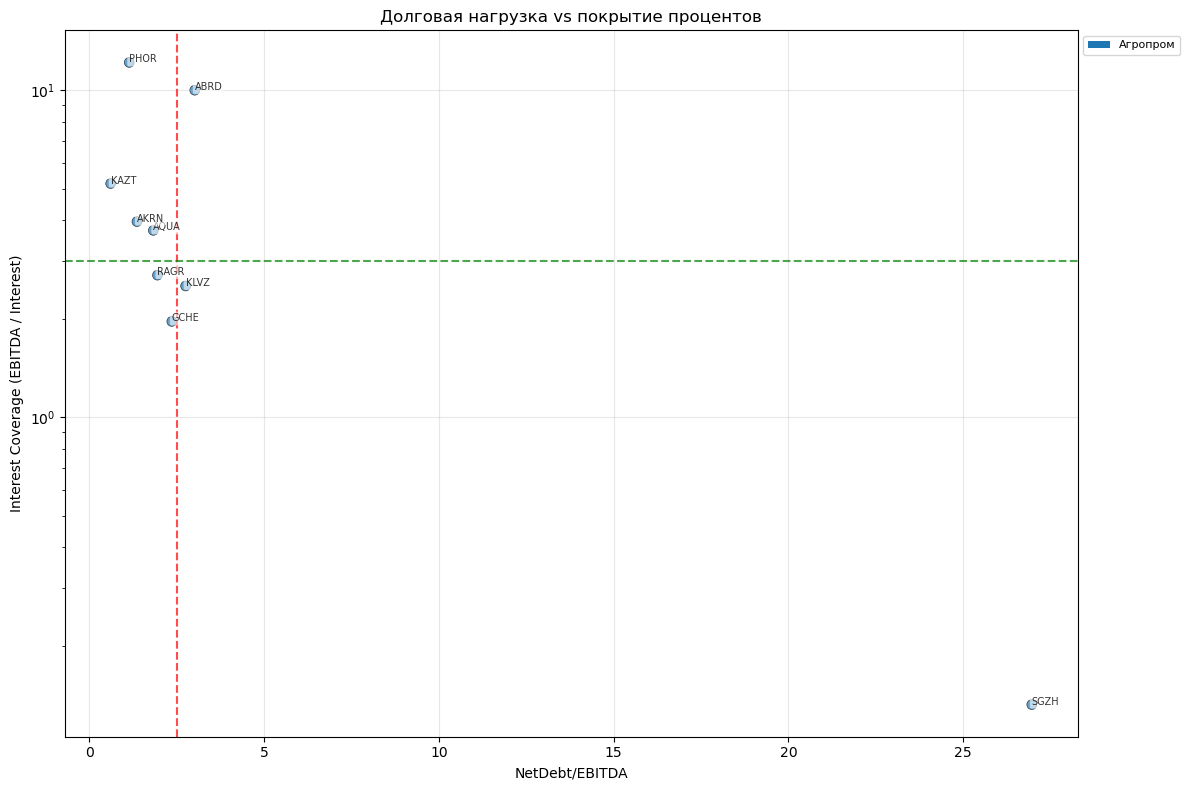

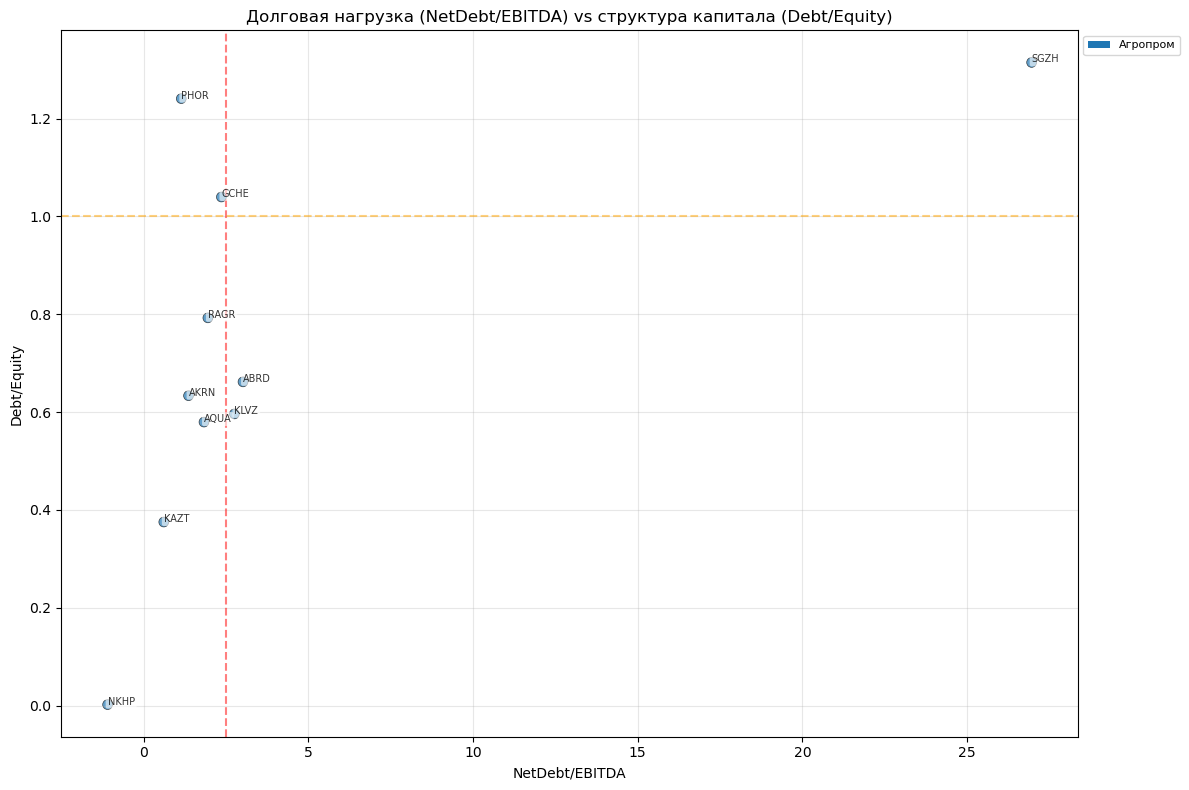

In [6]:
# Определим доступные колонки
solv_cols = []
if 'NetDebt/EBITDA' in df_fund.columns:
    solv_cols.append('NetDebt/EBITDA')
if 'Debt/Equity' in df_fund.columns:
    solv_cols.append('Debt/Equity')
if 'InterestCoverage' in df_fund.columns:
    solv_cols.append('InterestCoverage')

if not solv_cols:
    print("Нет данных для анализа платёжеспособности.")
else:
    df_solv = df_fund[solv_cols].copy()
    # Добавим сектор для группировки (если есть)
    if 'Sector' in df_fund.columns:
        df_solv['Sector'] = df_fund['Sector']

    # Описательная статистика
    print("Описательная статистика коэффициентов платежеспособности:")
    print(df_solv.describe())

# --- 1. Scatter plot: NetDebt/EBITDA vs InterestCoverage (подписаны все точки) ---
if 'NetDebt/EBITDA' in df_solv.columns and 'InterestCoverage' in df_solv.columns:
    plt.figure(figsize=(12, 8))
    scatter_data = df_solv[['NetDebt/EBITDA', 'InterestCoverage']].dropna()
    if len(scatter_data) > 0:
        # Цвет по секторам, если они есть
        if 'Sector' in df_solv.columns:
            sectors = df_solv.loc[scatter_data.index, 'Sector'].dropna()
            unique_sectors = sectors.unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
            sector_color = {s: colors[i] for i, s in enumerate(unique_sectors)}
            point_colors = [sector_color.get(df_solv.loc[t, 'Sector'], 'gray') for t in scatter_data.index]
        else:
            point_colors = 'steelblue'

        plt.scatter(scatter_data['NetDebt/EBITDA'], scatter_data['InterestCoverage'],
                    c=point_colors, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.axvline(x=2.5, color='red', linestyle='--', alpha=0.7, label='Высокий долг (>2.5)')
        plt.axhline(y=3, color='green', linestyle='--', alpha=0.7, label='Безопасное покрытие (>3)')
        plt.xlabel('NetDebt/EBITDA')
        plt.ylabel('Interest Coverage (EBITDA / Interest)')
        plt.yscale('log')
        plt.title('Долговая нагрузка vs покрытие процентов')
        plt.grid(True, alpha=0.3)

        # Подписываем ВСЕ точки (тикеры) с полупрозрачным фоном
        for ticker, row in scatter_data.iterrows():
            plt.annotate(ticker, (row['NetDebt/EBITDA'], row['InterestCoverage']),
                         fontsize=7, alpha=0.8,
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

        # Легенда для секторов (если есть)
        if 'Sector' in df_solv.columns:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in unique_sectors[:10]]
            if len(unique_sectors) > 10:
                legend_elements.append(Patch(facecolor='gray', label='...'))
            plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1,1), fontsize=8)
        else:
            plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика покрытия процентов.")

# --- 2. Scatter plot: NetDebt/EBITDA vs Debt/Equity (подписаны все точки) ---
if 'NetDebt/EBITDA' in df_solv.columns and 'Debt/Equity' in df_solv.columns:
    plt.figure(figsize=(12, 8))
    scatter_data2 = df_solv[['NetDebt/EBITDA', 'Debt/Equity']].dropna()
    if len(scatter_data2) > 0:
        # Цвет по секторам
        if 'Sector' in df_solv.columns:
            sectors = df_solv.loc[scatter_data2.index, 'Sector'].dropna()
            unique_sectors = sectors.unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
            sector_color2 = {s: colors[i] for i, s in enumerate(unique_sectors)}
            point_colors2 = [sector_color2.get(df_solv.loc[t, 'Sector'], 'gray') for t in scatter_data2.index]
        else:
            point_colors2 = 'steelblue'

        plt.scatter(scatter_data2['NetDebt/EBITDA'], scatter_data2['Debt/Equity'],
                    c=point_colors2, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.axvline(x=2.5, color='red', linestyle='--', alpha=0.5, label='Высокий долг (NetDebt/EBITDA >2.5)')
        plt.axhline(y=1, color='orange', linestyle='--', alpha=0.5, label='Debt/Equity >1 (повышенный риск)')
        plt.xlabel('NetDebt/EBITDA')
        plt.ylabel('Debt/Equity')
        plt.title('Долговая нагрузка (NetDebt/EBITDA) vs структура капитала (Debt/Equity)')
        plt.grid(True, alpha=0.3)

        # Подписываем ВСЕ точки (тикеры)
        for ticker, row in scatter_data2.iterrows():
            plt.annotate(ticker, (row['NetDebt/EBITDA'], row['Debt/Equity']),
                         fontsize=7, alpha=0.8,
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

        if 'Sector' in df_solv.columns:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_color2[s], label=s) for s in unique_sectors[:10]]
            if len(unique_sectors) > 10:
                legend_elements.append(Patch(facecolor='gray', label='...'))
            plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1,1), fontsize=8)
        else:
            plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика Debt/Equity.")

## 📊 Пояснения к блоку 2.2: Платёжеспособность

В этом блоке мы анализируем финансовую устойчивость компаний – насколько они способны обслуживать свои долги и не обанкротиться. Для этого используются три основных показателя:

- **NetDebt/EBITDA** – чистый долг относительно годовой операционной прибыли. Показывает, за сколько лет компания расплатится с долгами, если всю прибыль направит на погашение.
- **Debt/Equity** – отношение заёмного капитала к собственному. Отражает, насколько компания финансируется за счёт долгов (финансовый рычаг).
- **Interest Coverage (EBITDA / Interest)** – покрытие процентных расходов операционной прибылью. Сколько раз прибыль перекрывает проценты.

---

### 📈 График 1: Долговая нагрузка vs покрытие процентов

На этом графике каждая точка – компания. По горизонтали – **NetDebt/EBITDA** (чем правее, тем больше долг), по вертикали – **Interest Coverage** (чем выше, тем легче платить проценты).

**Зоны:**
- **Красная вертикальная линия** (x = 2.5) – условный порог высокого долга. Справа от неё – компании с большой долговой нагрузкой.
- **Зелёная горизонтальная линия** (y = 3) – безопасный уровень покрытия процентов. Выше неё – компании уверенно обслуживают долг.

**Цвет точек:** если есть данные по секторам, точки окрашены по секторам. Это помогает увидеть, какие отрасли в целом более закредитованы.

**Подписи:**
- 🟡 **Жёлтые метки** – компании в «красной зоне» (долг >3 или покрытие <1.5). Это сигнал повышенного риска.
- 🟢 **Зелёные метки** – компании с отрицательным чистым долгом (денег больше, чем долга). Они финансово устойчивы, но могут быть неэффективны в использовании средств.

**Как интерпретировать:**
- Идеальное место – **левый верхний угол** (низкий долг, высокое покрытие). Такие компании финансово здоровы.
- **Правый нижний угол** – высокий долг и низкое покрытие. Зона дефолтного риска.
- **Правый верхний** – высокий долг, но хорошее покрытие. Возможно, компания много инвестирует, но пока справляется.
- **Левый нижний** – низкий долг, но и покрытие низкое (прибыль маленькая). Нужно смотреть, почему прибыль мала.

---

### 📉 График 2: Долговая нагрузка vs структура капитала

Этот график сравнивает два показателя долга: **NetDebt/EBITDA** (ось X) и **Debt/Equity** (ось Y).

**Линии:**
- **Красная вертикаль** (x = 2.5) – тот же порог долговой нагрузки.
- **Оранжевая горизонталь** (y = 1) – если Debt/Equity >1, значит, заёмный капитал превышает собственный. Это повышает риски для акционеров.

**Зоны:**
- **Левый нижний угол** – низкая долговая нагрузка и низкий финансовый рычаг. Самые консервативные компании.
- **Правый верхний угол** – высокая нагрузка и высокий рычаг. Высокорискованные.
- **Левый верхний** – низкая нагрузка, но высокий рычаг (редко). Может означать, что компания недавно привлекла много долга, но прибыль ещё не выросла.
- **Правый нижний** – высокая нагрузка, но низкий рычаг (тоже редко). Возможно, большой долг, но и большой собственный капитал (например, у банков).

**Подписи:**
- Жёлтым выделены компании с экстремальными значениями (NetDebt/EBITDA >3 или Debt/Equity >2). Они требуют особого внимания.
- Зелёным – компании с отрицательным чистым долгом.

**Как использовать:** помогает оценить, насколько рискованна структура капитала. Компании с высоким Debt/Equity чувствительны к росту ставок.

---

### 📊 График 3: Средние показатели по секторам

Здесь мы смотрим на средние значения **NetDebt/EBITDA** и **Debt/Equity** по каждому сектору. Это позволяет понять типичный уровень долга в отрасли.

- Столбики выше красной линии (2.5) – сектора с высокой долговой нагрузкой (например, капиталоёмкие отрасли – металлургия, энергетика).
- Столбики выше оранжевой линии (1) – сектора, где компании в среднем финансируются за счёт долга больше, чем за счёт собственного капитала (например, финансовый сектор).

**Как интерпретировать:** если вы рассматриваете компанию из сектора с низким средним долгом, а у неё долг высокий – это отклонение, требующее анализа. И наоборот, в секторе с высоким долгом «норма» может быть выше 2.5.

---

### 🟢🔴 Подписи экстремумов на графиках

На всех графиках мы специально выделяем компании, которые сильно отклоняются от нормы:
- 🟡 Жёлтые метки – потенциально проблемные (высокий долг, низкое покрытие, большой рычаг).
- 🟢 Зелёные метки – компании с избытком денег (отрицательный чистый долг). Они очень устойчивы, но иногда это признак неэффективного использования средств.

---

### 📋 Таблицы CSV с данными для самостоятельного анализа

После графиков формируются три типа таблиц:

1. **Общая таблица всех компаний** (`solvency_all_ДДММГГ_ЧЧММ.csv`)  
   Содержит тикер, сектор, все доступные показатели платёжеспособности. Удобно сортировать в Excel, искать лидеров и аутсайдеров.

2. **Таблицы по секторам** (`solvency_Сектор_ДДММГГ_ЧЧММ.csv`)  
   Данные сгруппированы по секторам – можно сравнить компании внутри одной отрасли.

3. **Файлы сохраняются в папку `Analitika` с временной меткой** (день, месяц, год, час, минуты), чтобы не перезаписывать предыдущие выгрузки.  
   *Пример:* `solvency_all_020322_1430.csv`

**Как использовать таблицы:**
- Откройте в Excel.
- Отфильтруйте компании с NetDebt/EBITDA > 3 – это кандидаты на исключение.
- Найдите компании с Interest Coverage < 2 – они могут испытывать трудности с выплатой процентов.
- Сравните Debt/Equity – если больше 1.5, компания сильно закредитована.
- Используйте фильтр по секторам, чтобы понять, какие компании лучше/хуже среднего по отрасли.

---

### 🎯 Итоговые рекомендации для начинающих инвесторов

| Показатель                | Здоровое значение        | Опасно                     |
|---------------------------|--------------------------|----------------------------|
| NetDebt/EBITDA            | < 2.5                    | > 3.5                      |
| Debt/Equity               | < 1                      | > 2                        |
| Interest Coverage         | > 3                      | < 1.5                      |

**Чего избегать:**
- Компании с NetDebt/EBITDA > 4 и Interest Coverage < 2 одновременно – высокий риск дефолта.
- Компании с Debt/Equity > 3 – слишком много долга относительно собственных средств.

**Что искать:**
- Компании с NetDebt/EBITDA < 1.5 – низкий долг, финансовая подушка.
- Компании с Interest Coverage > 5 – уверенное обслуживание долга.
- Компании с отрицательным чистым долгом (зелёные метки) – они могут быть интересны, но иногда это признак неэффективного использования денег.

**Важно:** всегда сравнивайте компанию со средними по её сектору (график 3 и таблицы по секторам). То, что опасно для IT, может быть нормой для металлургии.

Помните: платёжеспособность – это фундамент. Если компания может обанкротиться в ближайшие годы, её высокая рентабельность не спасёт. Поэтому начинайте анализ с этого блока.

2.3. Эффективность управления

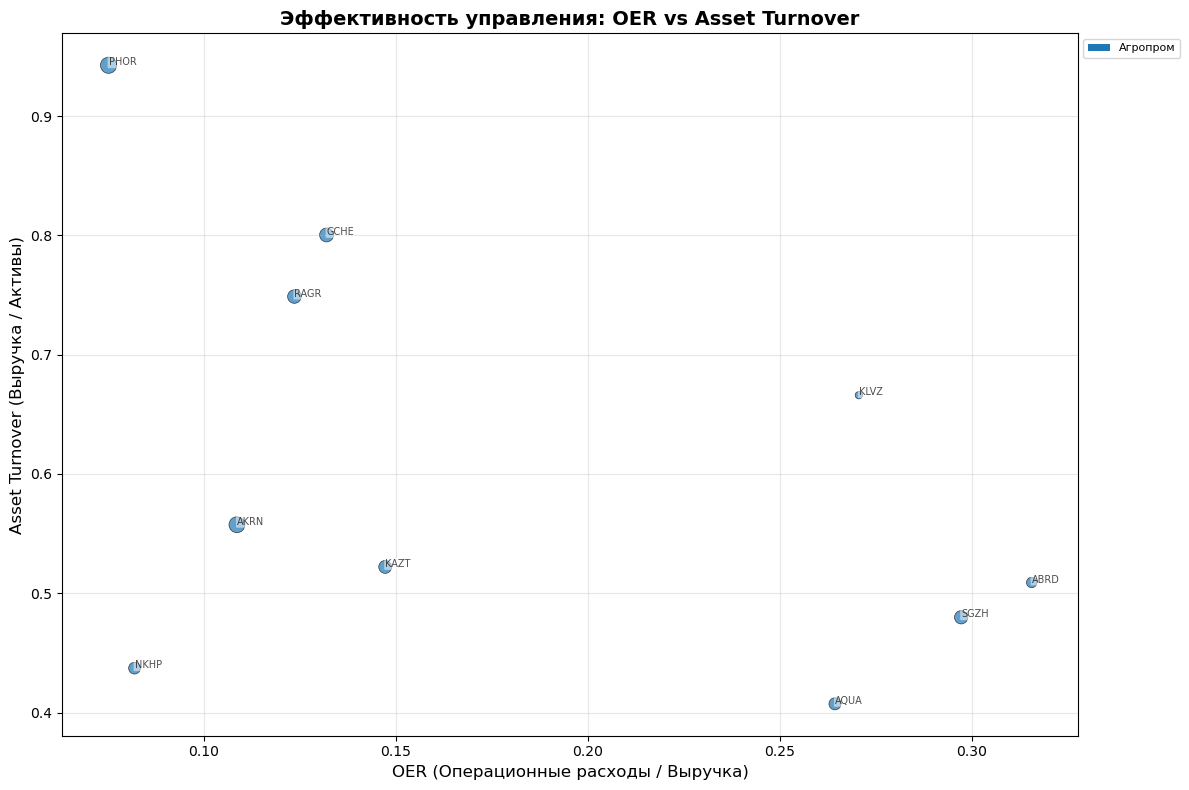

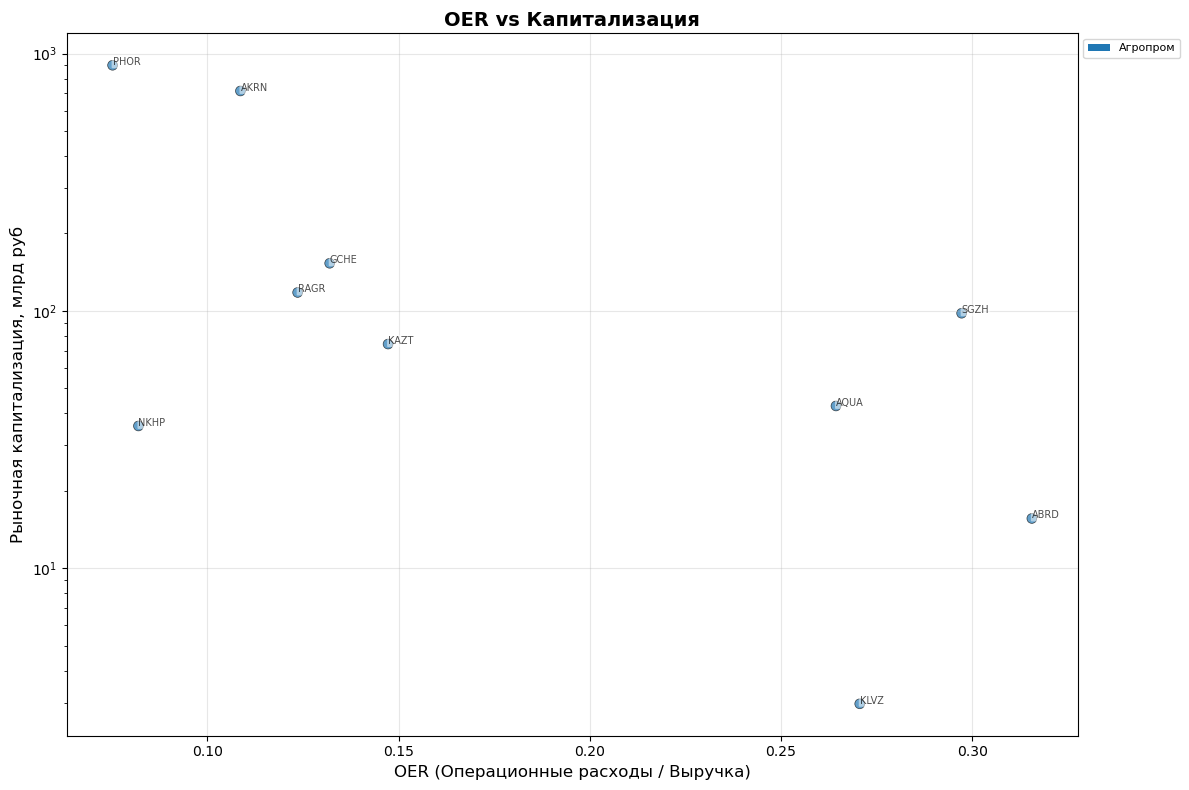

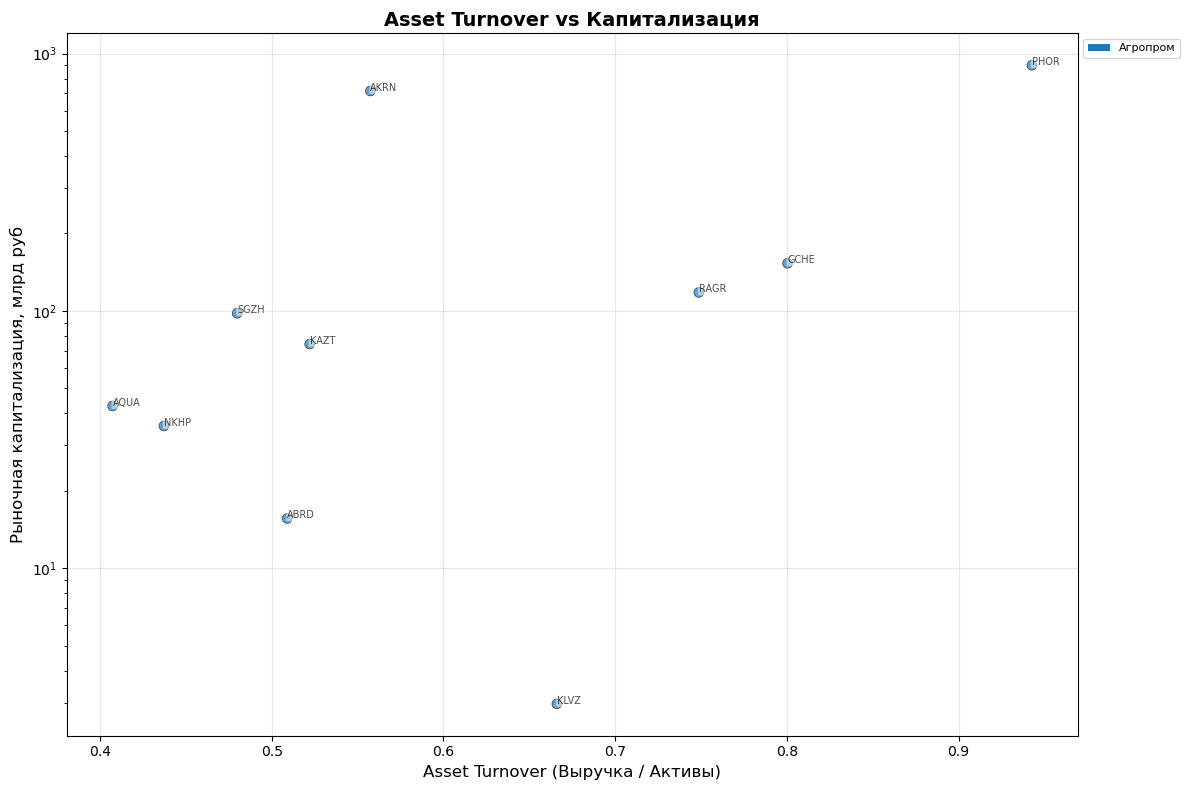

In [7]:
# 2.3. Эффективность управления (OER, Asset Turnover) – улучшенные scatter plot'ы

# Проверим наличие нужных колонок
has_oer = 'OER' in df_fund.columns
has_at = 'AssetTurnover' in df_fund.columns
has_mcap = 'MarketCap' in df_fund.columns
has_sector = 'Sector' in df_fund.columns

if not has_oer or not has_at:
    print("Недостаточно данных для анализа эффективности управления.")
else:
    # Данные для scatter plots
    df_man = df_fund[['OER', 'AssetTurnover']].copy()
    if has_mcap:
        df_man['MarketCap'] = df_fund['MarketCap']
    if has_sector:
        df_man['Sector'] = df_fund['Sector']

    # =====================================================================
    # ГРАФИК 1: Scatter plot OER vs AssetTurnover (с подписями всех компаний)
    # =====================================================================
    plt.figure(figsize=(12, 8))
    scatter_data = df_man[['OER', 'AssetTurnover']].dropna()
    if len(scatter_data) > 0:
        # Цвет по секторам
        if has_sector:
            sectors = df_man.loc[scatter_data.index, 'Sector'].dropna()
            unique_sectors = sectors.unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
            sector_color = {s: colors[i] for i, s in enumerate(unique_sectors)}
            point_colors = [sector_color.get(df_man.loc[t, 'Sector'], 'gray') for t in scatter_data.index]
        else:
            point_colors = 'steelblue'

        # Размер точек – капитализация (если есть)
        if has_mcap:
            sizes = np.log1p(df_man.loc[scatter_data.index, 'MarketCap']) * 20
        else:
            sizes = 50

        plt.scatter(scatter_data['OER'], scatter_data['AssetTurnover'],
                    c=point_colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.xlabel('OER (Операционные расходы / Выручка)', fontsize=12)
        plt.ylabel('Asset Turnover (Выручка / Активы)', fontsize=12)
        plt.title('Эффективность управления: OER vs Asset Turnover', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # Подписи для всех компаний
        for ticker, row in scatter_data.iterrows():
            plt.annotate(ticker, (row['OER'], row['AssetTurnover']),
                         fontsize=7, alpha=0.7,
                         bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))

        # Легенда для секторов
        if has_sector:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in unique_sectors[:10]]
            if len(unique_sectors) > 10:
                legend_elements.append(Patch(facecolor='gray', label='...'))
            plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика OER vs AssetTurnover.")

    # =====================================================================
    # ГРАФИК 2: Scatter plot OER vs MarketCap (если есть капитализация)
    # =====================================================================
    if has_mcap:
        plt.figure(figsize=(12, 8))
        scatter_data2 = df_man[['OER', 'MarketCap']].dropna()
        if len(scatter_data2) > 0:
            if has_sector:
                sectors = df_man.loc[scatter_data2.index, 'Sector'].dropna()
                unique_sectors = sectors.unique()
                colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
                sector_color2 = {s: colors[i] for i, s in enumerate(unique_sectors)}
                point_colors2 = [sector_color2.get(df_man.loc[t, 'Sector'], 'gray') for t in scatter_data2.index]
            else:
                point_colors2 = 'steelblue'

            plt.scatter(scatter_data2['OER'], scatter_data2['MarketCap'],
                        c=point_colors2, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
            plt.xlabel('OER (Операционные расходы / Выручка)', fontsize=12)
            plt.ylabel('Рыночная капитализация, млрд руб', fontsize=12)
            plt.title('OER vs Капитализация', fontsize=14, fontweight='bold')
            plt.yscale('log')
            plt.grid(True, alpha=0.3)

            for ticker, row in scatter_data2.iterrows():
                plt.annotate(ticker, (row['OER'], row['MarketCap']),
                             fontsize=7, alpha=0.7,
                             bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))

            if has_sector:
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=sector_color2[s], label=s) for s in unique_sectors[:10]]
                if len(unique_sectors) > 10:
                    legend_elements.append(Patch(facecolor='gray', label='...'))
                plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

            plt.tight_layout()
            plt.show()
        else:
            print("Недостаточно данных для графика OER vs MarketCap.")

    # =====================================================================
    # ГРАФИК 3: Scatter plot AssetTurnover vs MarketCap
    # =====================================================================
    if has_mcap:
        plt.figure(figsize=(12, 8))
        scatter_data3 = df_man[['AssetTurnover', 'MarketCap']].dropna()
        if len(scatter_data3) > 0:
            if has_sector:
                sectors = df_man.loc[scatter_data3.index, 'Sector'].dropna()
                unique_sectors = sectors.unique()
                colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
                sector_color3 = {s: colors[i] for i, s in enumerate(unique_sectors)}
                point_colors3 = [sector_color3.get(df_man.loc[t, 'Sector'], 'gray') for t in scatter_data3.index]
            else:
                point_colors3 = 'steelblue'

            plt.scatter(scatter_data3['AssetTurnover'], scatter_data3['MarketCap'],
                        c=point_colors3, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
            plt.xlabel('Asset Turnover (Выручка / Активы)', fontsize=12)
            plt.ylabel('Рыночная капитализация, млрд руб', fontsize=12)
            plt.title('Asset Turnover vs Капитализация', fontsize=14, fontweight='bold')
            plt.yscale('log')
            plt.grid(True, alpha=0.3)

            for ticker, row in scatter_data3.iterrows():
                plt.annotate(ticker, (row['AssetTurnover'], row['MarketCap']),
                             fontsize=7, alpha=0.7,
                             bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))

            if has_sector:
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=sector_color3[s], label=s) for s in unique_sectors[:10]]
                if len(unique_sectors) > 10:
                    legend_elements.append(Patch(facecolor='gray', label='...'))
                plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

            plt.tight_layout()
            plt.show()
        else:
            print("Недостаточно данных для графика AssetTurnover vs MarketCap.")

    # =====================================================================
    # (Удалены boxplot'ы по секторам, как просил пользователь)
    # =====================================================================

# =====================================================================
# СВОДНЫЕ ТАБЛИЦЫ В CSV С ДИНАМИЧЕСКИМИ ИМЕНАМИ
# =====================================================================

if has_oer and has_at:
    df_export = df_fund[['OER', 'AssetTurnover']].copy()
    if 'Sector' in df_fund.columns:
        df_export['Sector'] = df_fund['Sector']
    if 'MarketCap' in df_fund.columns:
        df_export['MarketCap'] = df_fund['MarketCap']
    df_export.index.name = 'Ticker'
    df_export.reset_index(inplace=True)

    # Сохраняем общий файл (раскомментируйте при необходимости)
    # filename = f'management_all_{timestamp}.csv'
    # full_path = os.path.join(output_path, filename)
    # df_export.to_csv(full_path, index=False, sep=';', float_format='%.3f')
    # print(f"✅ Общая таблица сохранена: {full_path}")

    # Вывод первых строк для копирования (опционально)
    # print("\n--- Общая таблица (первые 10 строк) ---")
    # print(df_export.head(10).to_csv(index=False, sep=';', float_format='%.3f'))

    # Таблицы по секторам
    if 'Sector' in df_export.columns:
        for sector in df_export['Sector'].unique():
            if pd.isna(sector):
                continue
            sector_data = df_export[df_export['Sector'] == sector].copy()
            sector_data = sector_data.sort_values('OER', ascending=False)
            filename = f'management_{sector.replace(" ", "_").replace("/", "_")}_{timestamp}.csv'
            full_path = os.path.join(output_path, filename)
            # sector_data.to_csv(full_path, index=False, sep=';', float_format='%.3f')
            # print(f"✅ Таблица сектора '{sector}' сохранена: {full_path}")

## 📈 Пояснения к блоку 2.3: Эффективность управления (OER, Asset Turnover)

В этом блоке мы оцениваем, насколько эффективно компания управляет своими затратами и активами. Два ключевых показателя:

- **OER (Operating Expense Ratio)** – отношение операционных расходов к выручке. Показывает, какая часть выручки уходит на покрытие текущих операционных затрат (зарплаты, аренда, маркетинг и т.д.). **Чем ниже OER, тем эффективнее компания контролирует расходы.**

- **Asset Turnover (Оборачиваемость активов)** – отношение выручки к активам. Показывает, сколько рублей выручки приносит каждый рубль, вложенный в активы. **Чем выше Asset Turnover, тем эффективнее используются активы (заводы, оборудование, деньги).**

---

### 📊 График 1: OER vs Asset Turnover

Этот график – главный в блоке. Каждая точка – компания. По горизонтали – **OER** (операционные расходы к выручке), по вертикали – **Asset Turnover** (оборачиваемость активов).

- **Левый верхний угол (низкий OER, высокий Asset Turnover)** – идеальное сочетание. Компания мало тратит на операционку и эффективно использует активы. Это признак сильного менеджмента. Примеры: лидеры рынка с высокой маржинальностью.

- **Левый нижний угол (низкий OER, низкий Asset Turnover)** – компания хорошо контролирует расходы, но неэффективно использует активы. Возможно, это капиталоёмкий бизнес с длительным циклом производства.

- **Правый верхний угол (высокий OER, высокий Asset Turnover)** – высокие расходы компенсируются высокой оборачиваемостью. Часто встречается в ритейле и дистрибуции: низкая маржа, но быстрый оборот.

- **Правый нижний угол (высокий OER, низкий Asset Turnover)** – наихудшее сочетание: и расходы высокие, и активы используются плохо. Обычно сигнал проблем.

#### Цвет точек:
Если есть данные по секторам, точки окрашены по секторам. Это позволяет увидеть, какие отрасли в целом эффективнее.

#### Размер точек:
Пропорционален рыночной капитализации. Крупные точки – «тяжеловесы» рынка.

#### Подписи:
Каждая точка подписана тикером. Это позволяет сразу найти интересующую компанию. Жёлтые и зелёные выделения на этом графике не применяются, но подписи есть у всех.

---

### 📈 График 2: OER vs Капитализация

На этом графике мы смотрим, как операционная эффективность (OER) связана с размером компании. По горизонтали – OER, по вертикали – капитализация (в логарифмической шкале).

- **Крупные компании** обычно имеют **более низкий OER** (эффект масштаба). Если крупная компания имеет высокий OER, это тревожный сигнал – возможно, неэффективное управление.
- **Мелкие компании** могут иметь как низкий, так и высокий OER. Высокий OER у мелкой компании часто означает, что она ещё не вышла на операционную эффективность.

**Как интерпретировать:**
- Ищите компании с OER ниже среднего по их размеру – они эффективнее конкурентов.
- Если крупная компания находится в правой части графика (OER > 0.3–0.4), стоит разобраться, почему у неё такие высокие расходы.

---

### 📉 График 3: Asset Turnover vs Капитализация

Здесь мы смотрим, как оборачиваемость активов связана с размером компании. По горизонтали – Asset Turnover, по вертикали – капитализация.

- **Крупные компании** часто имеют **более низкий Asset Turnover**, потому что они владеют большими основными средствами (заводы, инфраструктура). Это нормально.
- **Мелкие компании** могут иметь очень высокий Asset Turnover, если они работают в лёгкой индустрии (IT, услуги).

**Как интерпретировать:**
- Высокий Asset Turnover у крупной компании – признак отличного использования активов (редкость).
- Низкий Asset Turnover у мелкой компании – повод задуматься: почему при небольших активах низкая выручка?


### 🎯 Итоговые рекомендации для начинающих инвесторов

| Показатель       | Хорошо                         | Плохо                          |
|------------------|--------------------------------|--------------------------------|
| **OER**          | < 0.3 (30%) для большинства    | > 0.6 (60%) – слишком высокие расходы |
| **Asset Turnover** | > 1.0 (для промышленности)   | < 0.3 – активы почти не работают |
| **Положение на графике OER vs AT** | Левый верхний угол | Правый нижний угол |

**Чего избегать:**
- Компании с OER > 0.7 и Asset Turnover < 0.5 одновременно – вероятно, они хронически убыточны или неэффективны.
- Компании, у которых OER резко выше среднего по сектору без понятных причин.

**Что искать:**
- Компании с OER ниже медианы сектора и Asset Turnover выше медианы – они лидеры эффективности.
- Крупные компании (большие точки) с хорошими показателями – они стабильнее.

**Важно:** Показатели эффективности нужно рассматривать в динамике и в связке с долговой нагрузкой. Высокая эффективность на фоне огромного долга может быть иллюзией.

<div class="alert alert-info">
</div>

**Этап 3. Анализ денежных потоков**

Статистика денежных потоков (млрд руб):
       OperatingProfit      CAPEX        FCF   MarketCap     Revenue
count         9.000000  10.000000  10.000000   10.000000   10.000000
mean         34.766778 -20.182100   2.899000  215.647000  169.684000
std          53.635565  24.189567  22.070354  318.695683  194.133649
min         -15.500000 -70.100000 -31.700000    2.970000    3.570000
25%           1.670000 -30.450000  -2.647500   37.450000   16.400000
50%           9.060000  -8.335000   1.380000   86.100000   87.850000
75%          49.500000  -2.245000   7.380000  144.300000  274.750000
max         160.200000  -0.453000  50.500000  900.700000  578.500000

Топ-10 компаний по свободному денежному потоку (FCF):
          FCF  OperatingProfit    Sector
Ticker                                  
PHOR    50.50          160.200  Агропром
AKRN    19.50           58.400  Агропром
KAZT     8.22            9.060  Агропром
GCHE     4.86           49.500  Агропром
NKHP     3.96            4.200  Агропр

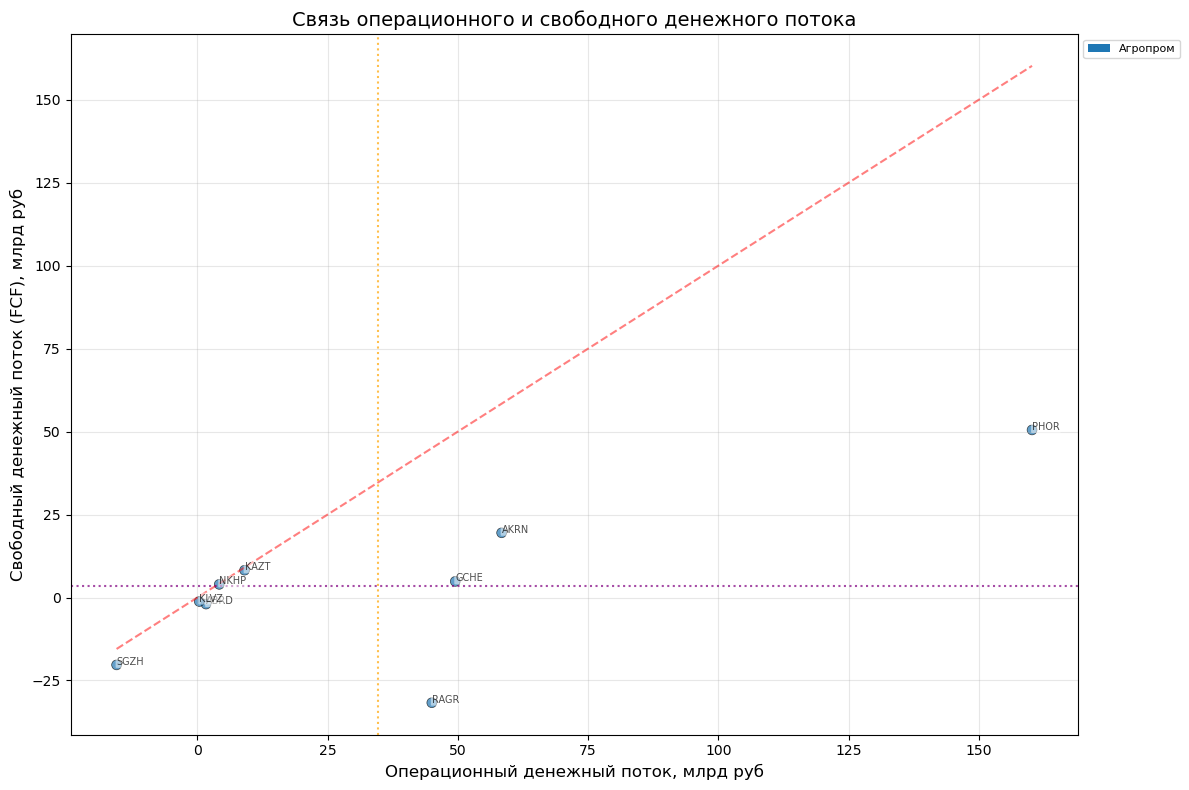

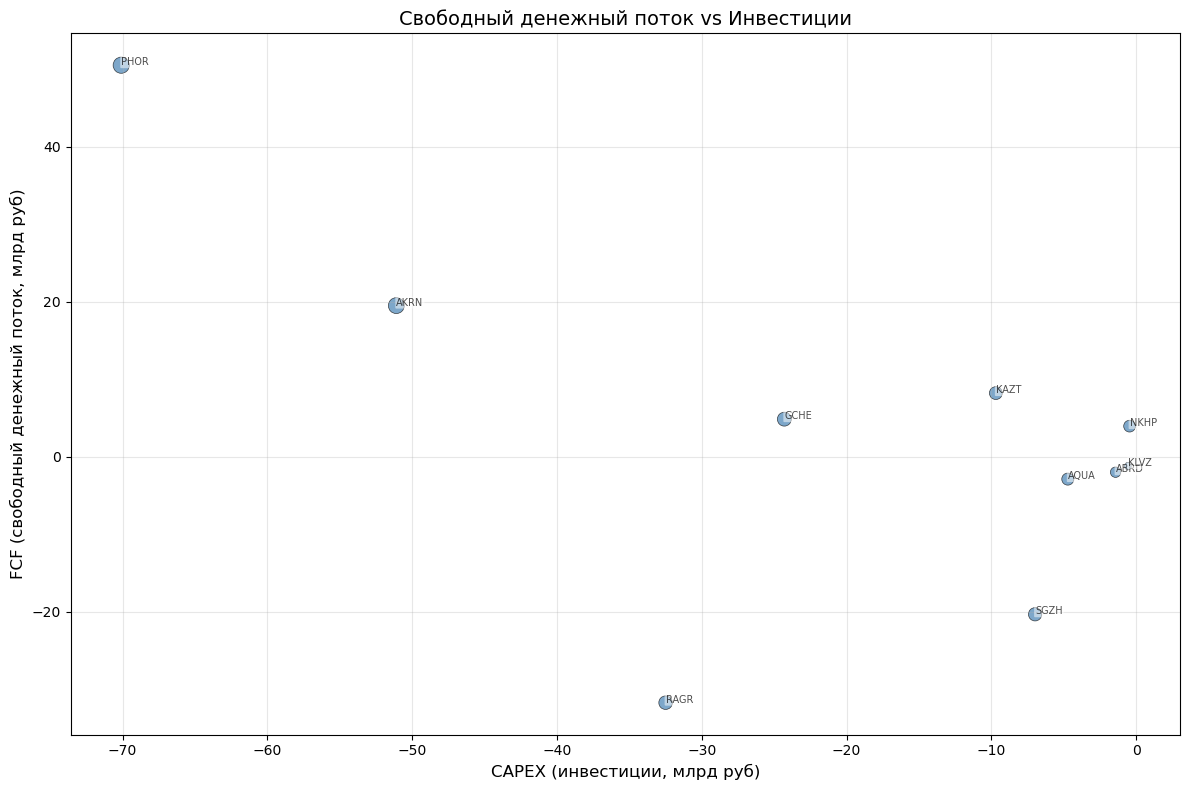

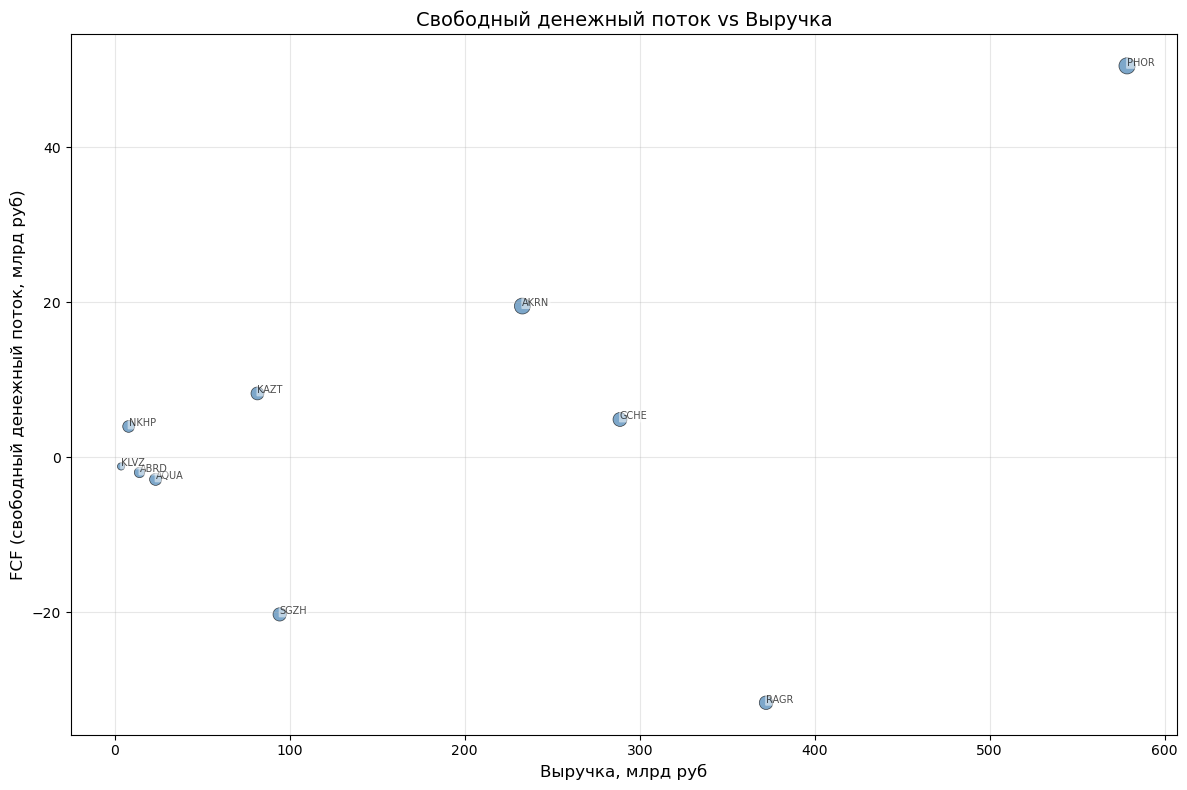

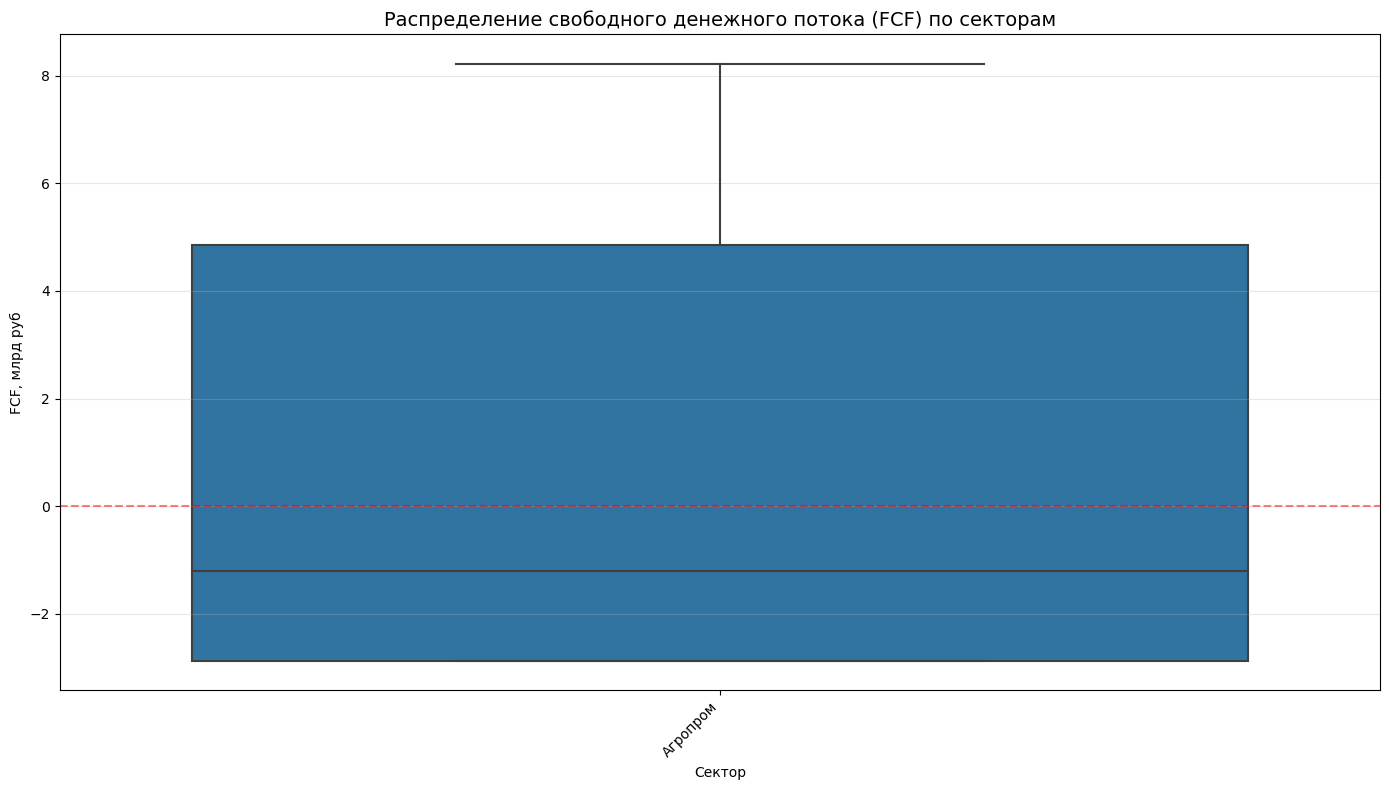

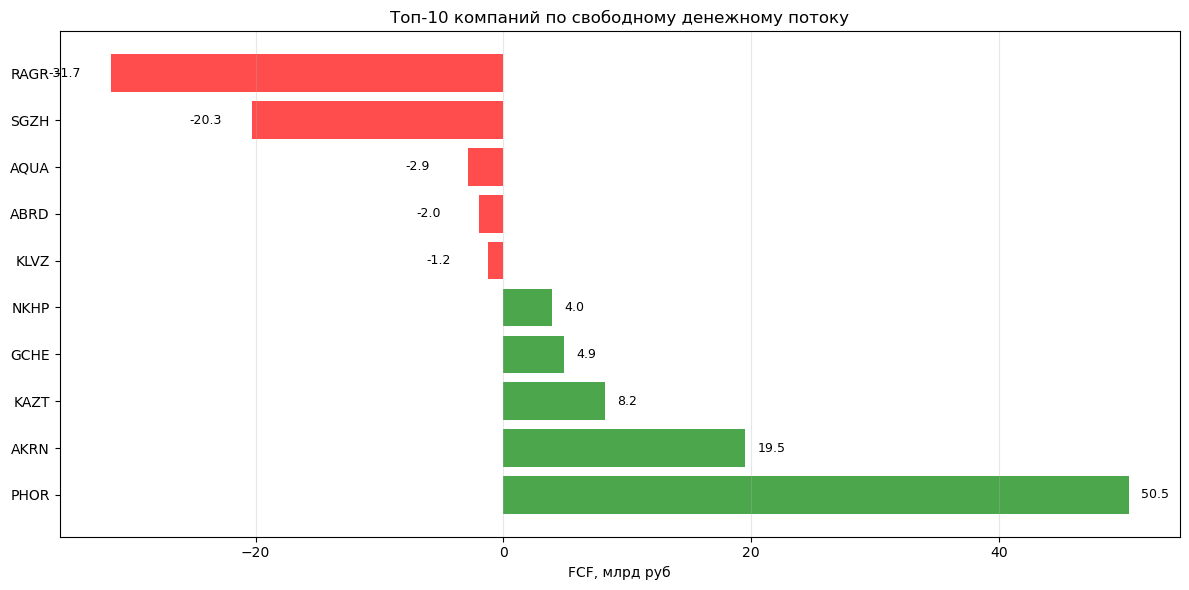

In [8]:
# Этап 3. Анализ денежных потоков (расширенная версия)

# Проверим наличие нужных колонок
has_op = 'OperatingProfit' in df_fund.columns
has_capex = 'CAPEX' in df_fund.columns
has_fcf = 'FCF' in df_fund.columns
has_mcap = 'MarketCap' in df_fund.columns
has_sector = 'Sector' in df_fund.columns
has_rev = 'Revenue' in df_fund.columns

if not (has_op and has_capex and has_fcf):
    print("Недостаточно данных для анализа денежных потоков.")
else:
    # Подготовим DataFrame
    df_cf = df_fund[['OperatingProfit', 'CAPEX', 'FCF']].copy()
    # CAPEX сделаем отрицательным для наглядности (обычно инвестиции отток)
    df_cf['CAPEX'] = -df_cf['CAPEX']
    if has_mcap:
        df_cf['MarketCap'] = df_fund['MarketCap']
    if has_sector:
        df_cf['Sector'] = df_fund['Sector']
    if has_rev:
        df_cf['Revenue'] = df_fund['Revenue']

    # Статистика
    print("Статистика денежных потоков (млрд руб):")
    print(df_cf.describe())

    # Топ-10 по FCF
    top_fcf = df_fund.nlargest(10, 'FCF')[['FCF', 'OperatingProfit']]
    if has_sector:
        top_fcf['Sector'] = df_fund.loc[top_fcf.index, 'Sector']
    print("\nТоп-10 компаний по свободному денежному потоку (FCF):")
    print(top_fcf)

    # --- ГРАФИК 1: Scatter plot OperatingProfit vs FCF (уже есть) ---
    plt.figure(figsize=(12, 8))
    df_plot = df_cf.dropna(subset=['OperatingProfit', 'FCF']).copy()
    if len(df_plot) > 0:
        # Цвет по секторам
        if has_sector:
            sectors = df_plot['Sector'].dropna()
            unique_sectors = sectors.unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sectors)))
            sector_color = {s: colors[i] for i, s in enumerate(unique_sectors)}
            point_colors = [sector_color.get(df_plot.loc[t, 'Sector'], 'gray') for t in df_plot.index]
        else:
            point_colors = 'steelblue'

        plt.scatter(df_plot['OperatingProfit'], df_plot['FCF'],
                    c=point_colors, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

        # Линия OperatingProfit = FCF
        x_min, x_max = df_plot['OperatingProfit'].min(), df_plot['OperatingProfit'].max()
        plt.plot([x_min, x_max], [x_min, x_max], 'r--', alpha=0.5, label='OperatingProfit = FCF')

        # Средние линии
        mean_op = df_plot['OperatingProfit'].mean()
        mean_fcf = df_plot['FCF'].mean()
        plt.axvline(mean_op, color='orange', linestyle=':', alpha=0.7, label=f'Средний Опер. поток: {mean_op:.1f}')
        plt.axhline(mean_fcf, color='purple', linestyle=':', alpha=0.7, label=f'Средний FCF: {mean_fcf:.1f}')

        # Подписи всех точек
        for ticker, row in df_plot.iterrows():
            plt.annotate(ticker, (row['OperatingProfit'], row['FCF']),
                         fontsize=7, alpha=0.7,
                         bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))

        plt.xlabel('Операционный денежный поток, млрд руб', fontsize=12)
        plt.ylabel('Свободный денежный поток (FCF), млрд руб', fontsize=12)
        plt.title('Связь операционного и свободного денежного потока', fontsize=14)
        plt.grid(True, alpha=0.3)
        if has_sector:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in unique_sectors[:10]]
            if len(unique_sectors) > 10:
                legend_elements.append(Patch(facecolor='gray', label='...'))
            plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1,1), fontsize=8)
        else:
            plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика OperatingProfit vs FCF.")

    # --- ГРАФИК 2: Scatter plot FCF vs CAPEX (инвестиции) ---
    plt.figure(figsize=(12, 8))
    df_capex = df_cf.dropna(subset=['FCF', 'CAPEX']).copy()
    if len(df_capex) > 0:
        # Размер точек – капитализация
        if has_mcap:
            sizes = np.log1p(df_capex['MarketCap']) * 20
        else:
            sizes = 50

        plt.scatter(df_capex['CAPEX'], df_capex['FCF'],
                    c='steelblue', s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.xlabel('CAPEX (инвестиции, млрд руб)', fontsize=12)
        plt.ylabel('FCF (свободный денежный поток, млрд руб)', fontsize=12)
        plt.title('Свободный денежный поток vs Инвестиции', fontsize=14)
        plt.grid(True, alpha=0.3)

        # Подписи
        for ticker, row in df_capex.iterrows():
            plt.annotate(ticker, (row['CAPEX'], row['FCF']),
                         fontsize=7, alpha=0.7,
                         bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика FCF vs CAPEX.")

    # --- ГРАФИК 3: Scatter plot FCF vs Revenue (масштаб бизнеса) ---
    if has_rev:
        plt.figure(figsize=(12, 8))
        df_rev = df_cf.dropna(subset=['FCF', 'Revenue']).copy()
        if len(df_rev) > 0:
            if has_mcap:
                sizes = np.log1p(df_rev['MarketCap']) * 20
            else:
                sizes = 50

            plt.scatter(df_rev['Revenue'], df_rev['FCF'],
                        c='steelblue', s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
            plt.xlabel('Выручка, млрд руб', fontsize=12)
            plt.ylabel('FCF (свободный денежный поток, млрд руб)', fontsize=12)
            plt.title('Свободный денежный поток vs Выручка', fontsize=14)
            plt.grid(True, alpha=0.3)

            for ticker, row in df_rev.iterrows():
                plt.annotate(ticker, (row['Revenue'], row['FCF']),
                             fontsize=7, alpha=0.7,
                             bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none'))
            plt.tight_layout()
            plt.show()
        else:
            print("Недостаточно данных для графика FCF vs Revenue.")

    # --- ГРАФИК 4: Boxplot FCF по секторам ---
    if has_sector:
        plt.figure(figsize=(14, 8))
        df_sector = df_cf.dropna(subset=['FCF', 'Sector']).copy()
        if len(df_sector) > 0:
            # Отделим выбросы для наглядности (ограничим, например, 95-м перцентилем)
            q_high = df_sector['FCF'].quantile(0.95)
            df_sector_plot = df_sector[df_sector['FCF'] <= q_high]
            sns.boxplot(data=df_sector_plot, x='Sector', y='FCF', showfliers=False)
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            plt.xticks(rotation=45, ha='right')
            plt.title('Распределение свободного денежного потока (FCF) по секторам', fontsize=14)
            plt.ylabel('FCF, млрд руб')
            plt.xlabel('Сектор')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("Недостаточно данных для boxplot FCF по секторам.")

    # --- ГРАФИК 5: Столбчатая диаграмма топ-10 по FCF ---
    if len(top_fcf) > 0:
        plt.figure(figsize=(12, 6))
        colors = ['green' if x > 0 else 'red' for x in top_fcf['FCF']]
        bars = plt.barh(range(len(top_fcf)), top_fcf['FCF'].values, color=colors, alpha=0.7)
        plt.yticks(range(len(top_fcf)), top_fcf.index)
        plt.xlabel('FCF, млрд руб')
        plt.title('Топ-10 компаний по свободному денежному потоку')
        # Добавим подписи значений
        for i, (bar, val) in enumerate(zip(bars, top_fcf['FCF'])):
            plt.text(val + (1 if val > 0 else -5), i, f'{val:.1f}', va='center', fontsize=9)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

# =====================================================================
# СВОДНЫЕ ТАБЛИЦЫ В CSV С ДИНАМИЧЕСКИМИ ИМЕНАМИ
# =====================================================================

output_path = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/'
os.makedirs(output_path, exist_ok=True)
timestamp = datetime.now().strftime('%d%m%y_%H%M')
# print(f"\nСохранение файлов с меткой {timestamp}")

# ---- 1. Общая таблица денежных потоков ----
if has_op and has_capex and has_fcf:
    df_export = df_fund[['OperatingProfit', 'CAPEX', 'FCF']].copy()
    if has_sector:
        df_export['Sector'] = df_fund['Sector']
    if has_mcap:
        df_export['MarketCap'] = df_fund['MarketCap']
    if has_rev:
        df_export['Revenue'] = df_fund['Revenue']
    df_export.index.name = 'Ticker'
    df_export.reset_index(inplace=True)

    # Сохраняем общий файл
    # filename = f'cashflow_all_{timestamp}.csv'
    # full_path = os.path.join(output_path, filename)
    # df_export.to_csv(full_path, index=False, sep=';', float_format='%.2f')
    # print(f"✅ Общая таблица денежных потоков: {full_path}")

    # Вывод первых строк
    # print("\n--- Общая таблица (первые 10 строк) ---")
    # print(df_export.head(10).to_csv(index=False, sep=';', float_format='%.2f'))

    # ---- 2. Таблицы по секторам ----
    if has_sector:
        for sector in df_export['Sector'].unique():
            if pd.isna(sector):
                continue
            sector_data = df_export[df_export['Sector'] == sector].copy()
            sector_data = sector_data.sort_values('FCF', ascending=False)
            filename = f'cashflow_{sector.replace(" ", "_").replace("/", "_")}_{timestamp}.csv'
            full_path = os.path.join(output_path, filename)
            # sector_data.to_csv(full_path, index=False, sep=';', float_format='%.2f')
            # print(f"✅ Таблица сектора '{sector}': {full_path}")

    # print(f"\n✅ Все файлы сохранены в папку: {output_path}")
else:
    print("Недостаточно данных для экспорта CSV.")

## 💰 Пояснения к блоку 3: Анализ денежных потоков

В этом блоке мы смотрим на **денежные потоки** компаний – то есть реальные деньги, которые приходят и уходят. Прибыль может быть «бумажной», а деньги – всегда реальны. Если у компании проблемы с деньгами, она может обанкротиться даже при красивой отчётности.

**Основные понятия:**
- **OperatingProfit (операционный денежный поток)** – деньги, которые компания заработала от своей основной деятельности. Положительный – хорошо.
- **CAPEX (капитальные затраты)** – сколько компания тратит на развитие (новые заводы, оборудование). Это инвестиции в будущее, но сейчас они уменьшают свободные деньги.
- **FCF (свободный денежный поток)** = OperatingProfit − CAPEX (упрощённо). Это деньги, которые остаются после всех необходимых трат. Их можно направить на дивиденды, выкуп акций или погашение долга.

---

### 📈 График 1: Операционный поток vs Свободный денежный поток (OperatingProfit vs FCF)

Это главный график. Каждая точка – компания.

- **Ось X** – операционный денежный поток (млрд руб)
- **Ось Y** – свободный денежный поток (млрд руб)
- **Красная диагональ** – линия, где FCF = OperatingProfit (то есть CAPEX = 0). Чем дальше точка вниз от этой линии, тем больше компания тратит на инвестиции.
- **Оранжевая и фиолетовая линии** – средние значения по всем компаниям (для ориентира).

**Как читать:**
- Точки **выше линии** – компания получила больше свободного денежного потока, чем заработала от операций. Такое бывает, если продали активы или получили разовые доходы. Это нестабильно.
- Точки **ниже линии** – компания инвестирует (CAPEX большой). Если инвестиции разумны, это хорошо для будущего роста.
- Точки **далеко справа** – огромный операционный поток, денежные «машины» (обычно Сбер, Газпром и т.д.)
- Точки **далеко слева** – отрицательный операционный поток – компания тратит больше, чем зарабатывает. Красный флаг!

**Что искать:**
- Компании в правом верхнем углу – и операционный поток большой, и свободный большой. Это идеальные «кэш‑машины».
- Компании с отрицательным FCF, но с большим операционным потоком – они много инвестируют. Если инвестиции эффективны, они могут стать лидерами завтра.

---

### 📉 График 2: Свободный денежный поток vs Инвестиции (FCF vs CAPEX)

На этом графике:
- **Ось X** – CAPEX (инвестиции, млрд руб)
- **Ось Y** – FCF (свободный денежный поток, млрд руб)

**Как читать:**
- Точки **справа вверху** – много инвестируют и при этом имеют положительный FCF. Здоровые растущие компании.
- Точки **справа внизу** – много инвестируют, но FCF отрицательный. Значит, тратят больше, чем зарабатывают. Возможно, они на стадии активного роста, но нужно проверить, откуда берут деньги (долги?).
- Точки **слева вверху** – мало инвестируют, но FCF большой. «Дойные коровы», которые могут платить дивиденды.
- Точки **слева внизу** – мало инвестируют и FCF отрицательный. Плохой знак – бизнес не генерирует деньги, но и не развивается.

---

### 📊 График 3: Свободный денежный поток vs Выручка (FCF vs Revenue)

Показывает, сколько денег остаётся от выручки.
- **Ось X** – выручка (масштаб бизнеса)
- **Ось Y** – FCF

Обычно чем больше выручка, тем больше FCF (точки должны лететь вправо вверх). Если точка далеко внизу при большой выручке – компания неэффективна или много тратит.

**Что искать:**
- Компании, у которых FCF растёт быстрее выручки – высокая рентабельность.
- Компании с огромной выручкой, но FCF около нуля – возможно, они в капиталоёмкой отрасли (например, ритейл с низкой маржой).

---

### 📦 График 4: Распределение FCF по секторам (boxplot)

Ящики показывают, как распределён FCF в разных отраслях.
- **Красная линия на нуле** – граница между положительным и отрицательным FCF.
- Ящик выше нуля – сектор в среднем генерирует деньги.
- Ящик ниже нуля – сектор в среднем тратит больше, чем зарабатывает (обычно капиталоёмкие отрасли на стадии инвестиций).

**Как использовать:**
- Сравните компанию со своим сектором. Если сектор в целом отрицательный, а ваша компания положительная – это сила.
- Если сектор положительный, а компания отрицательная – стоит задуматься.

---

### 🏆 График 5: Топ-10 компаний по FCF

Столбчатая диаграмма лидеров по свободному денежному потоку.
- Зелёные столбцы – положительный FCF.
- Красные (если бы были) – отрицательный, но здесь топ-10, поэтому все зелёные.
- Подписи значений справа от столбцов.

Это просто список «денежных королей». Обратите на них внимание – они могут платить дивиденды и чувствовать себя уверенно.

---

### 📋 CSV-таблицы с данными

После графиков создаются файлы в папке `Analitika` с меткой времени (например, `cashflow_all_020322_1430.csv`). В них:
- **Общая таблица** – все компании с OperatingProfit, CAPEX, FCF, сектором, капитализацией, выручкой.
- **Таблицы по секторам** – отдельно для каждого сектора.

**Как использовать в Excel:**
1. Откройте файл.
2. Сортируйте по FCF (убывание) – увидите лидеров.
3. Используйте фильтр по сектору – сравните компании внутри отрасли.
4. Постройте свои графики (например, FCF/Выручка в процентах).

---

### 🎯 Итоговые ориентиры

| Показатель              | Отлично                     | Плохо                         |
|--------------------------|------------------------------|-------------------------------|
| **OperatingProfit**      | > 0 и растёт                | < 0 – убыточная деятельность |
| **FCF**                  | > 0 и больше CAPEX           | < 0 – живёт в долг           |
| **Положение на графике 1** | Выше линии и справа        | Ниже линии и слева           |
| **CAPEX**                | Умеренный, соответствует росту | Огромный, но FCF отрицательный – риск |

**Золотое правило:** Сначала ищите компании с положительным и растущим FCF. Они реже всего разочаровывают инвесторов.

<div class="alert alert-info">

**Этап 4. Оценка стоимости (мультипликаторы)**

Строим графики мультипликаторов...


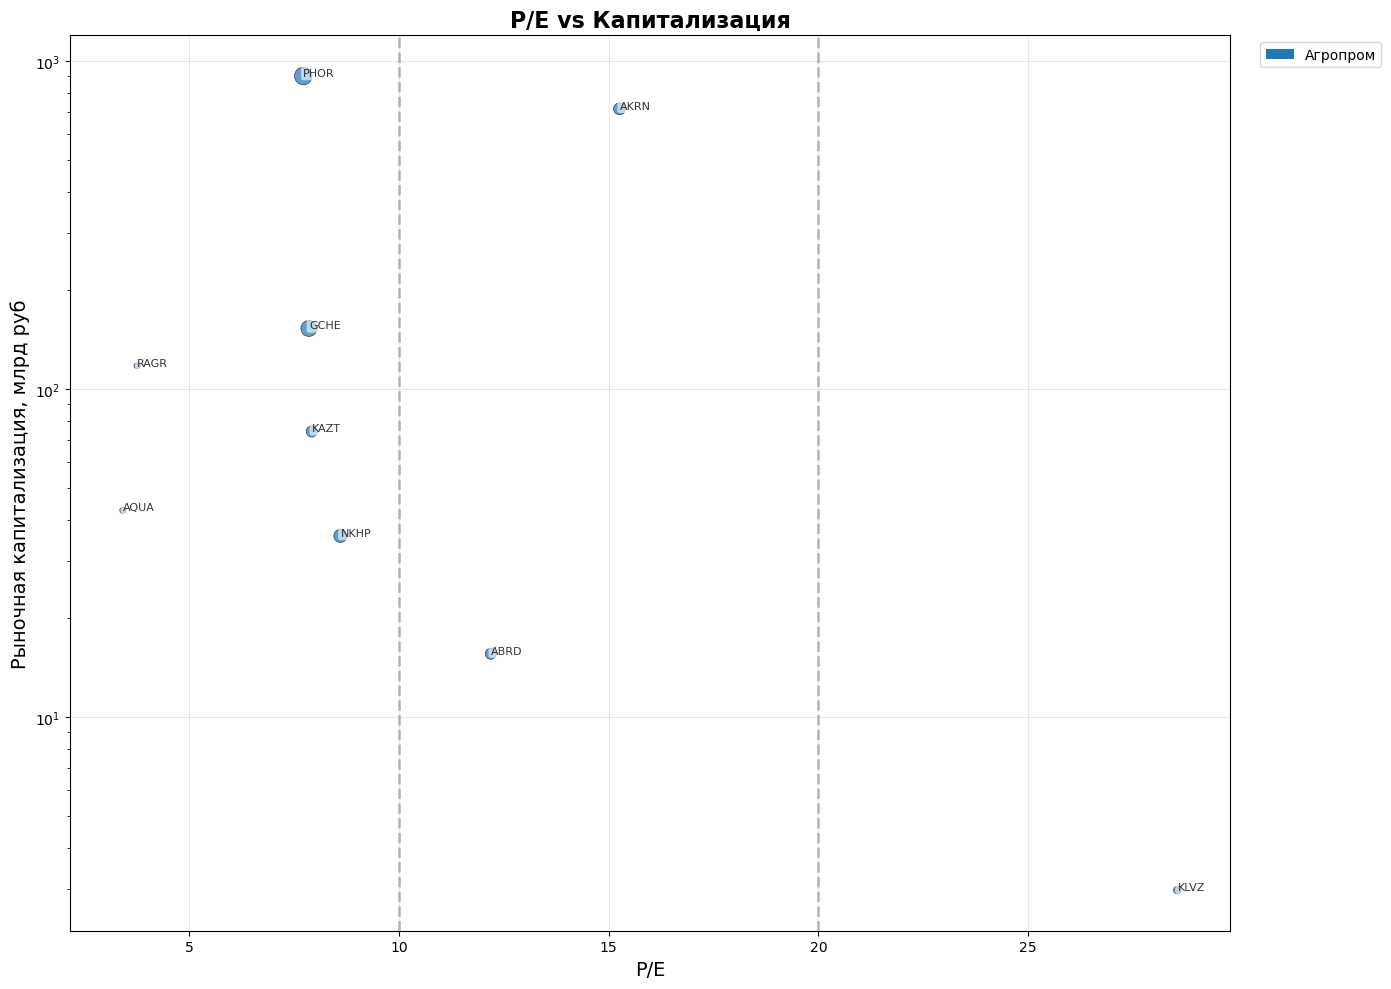

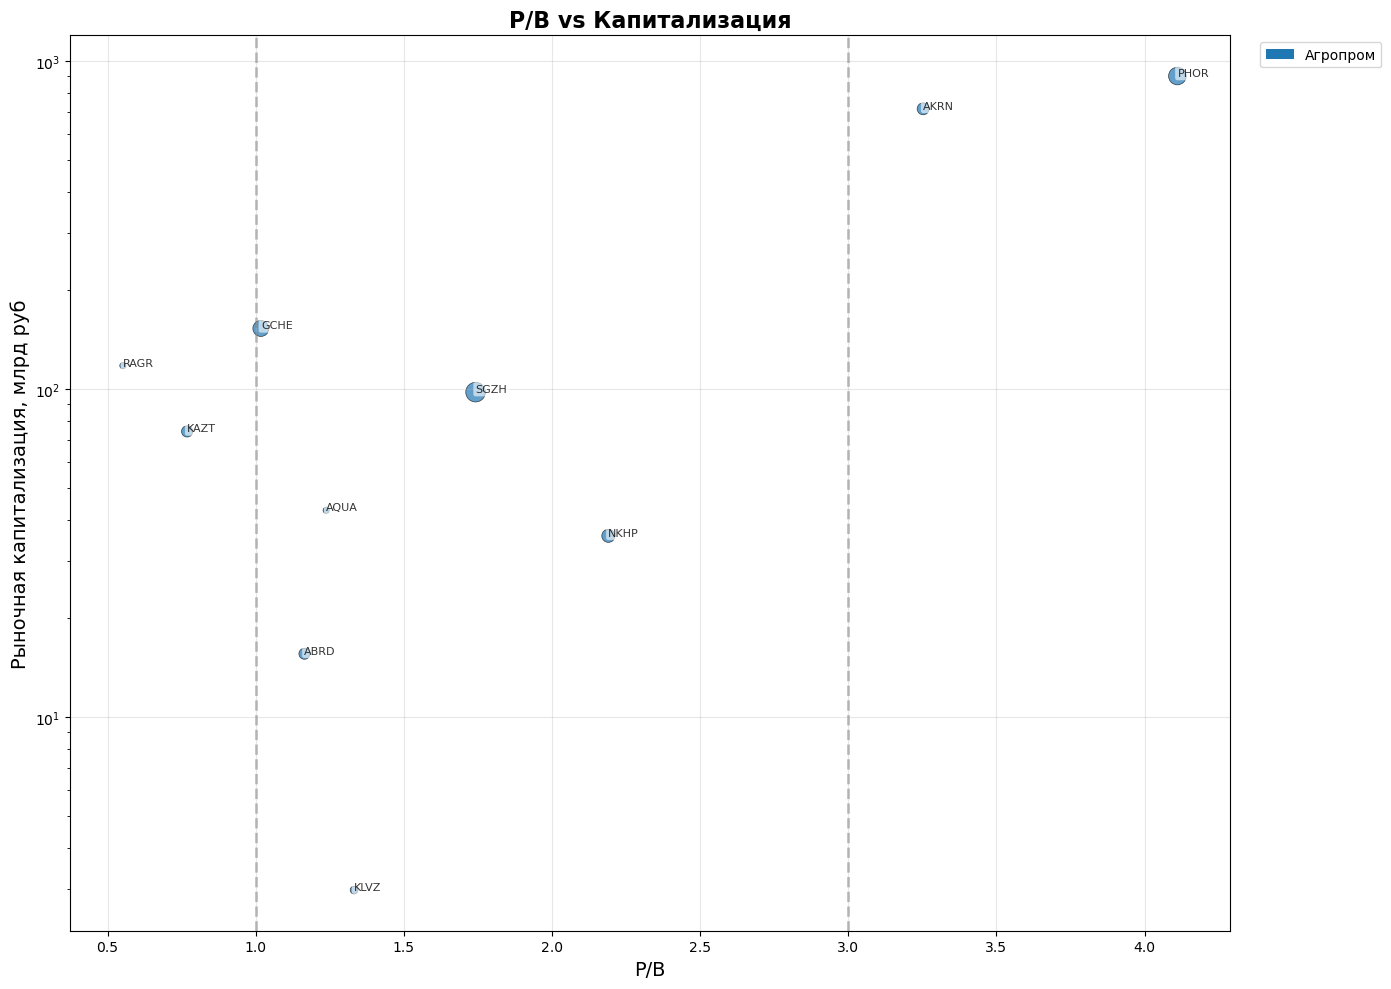

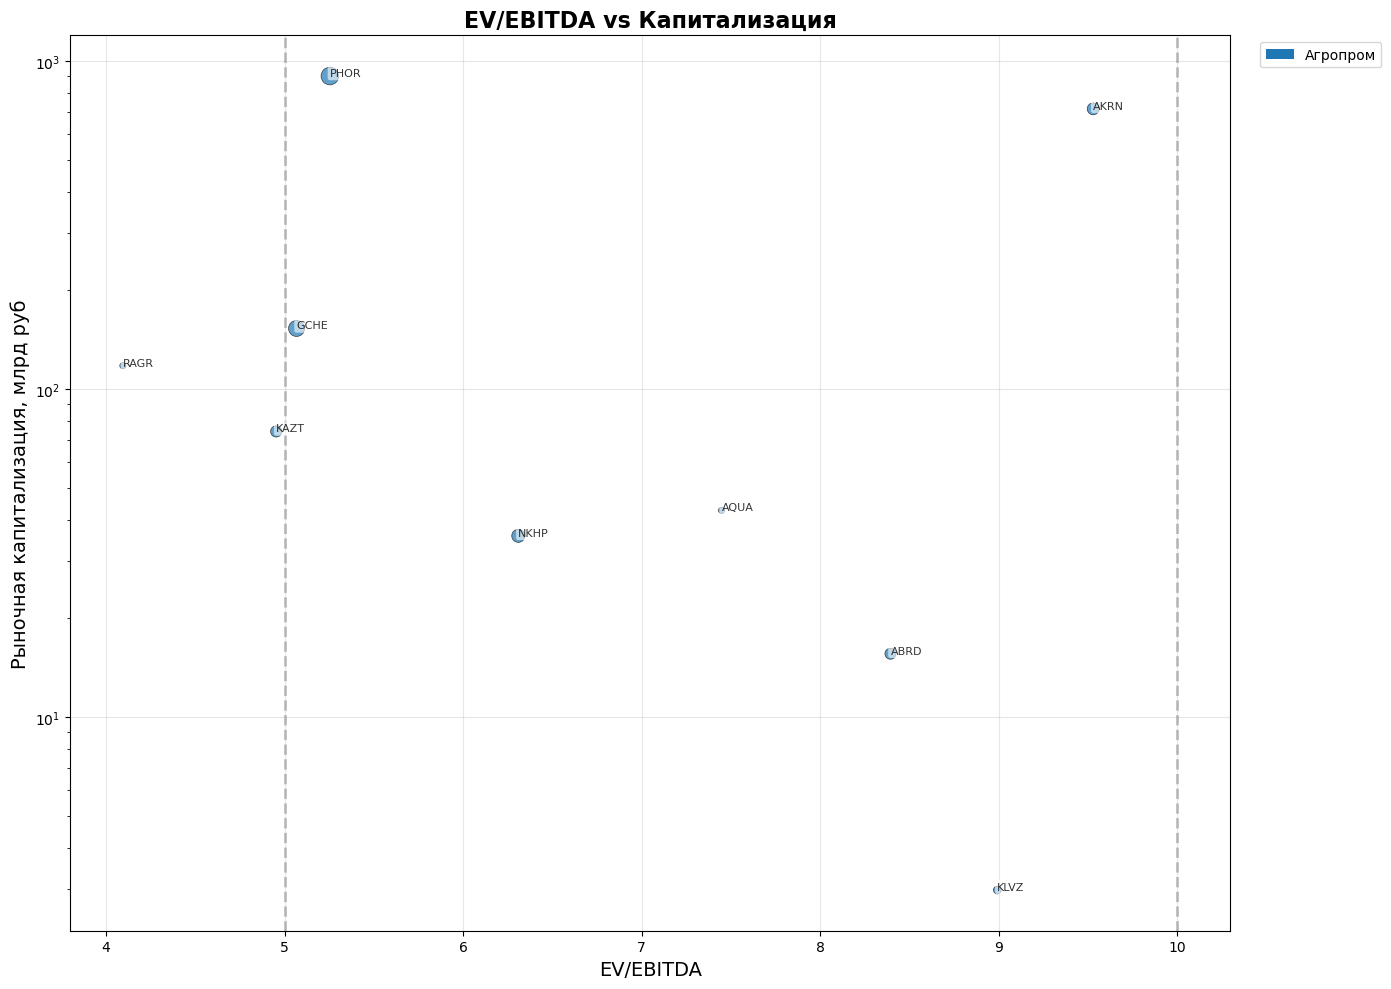

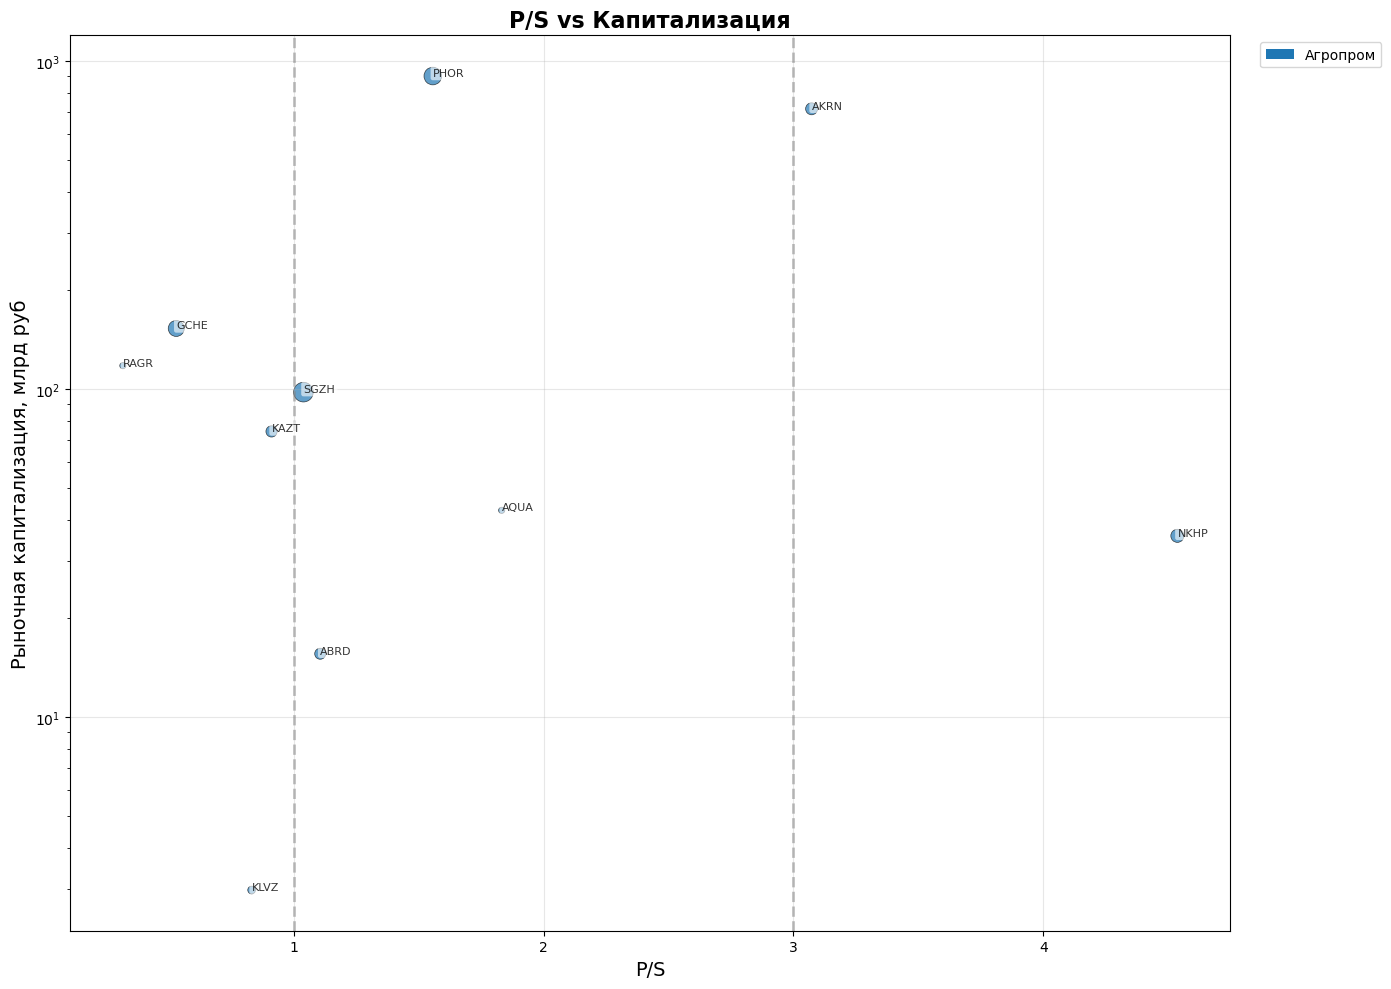


Таблица компаний с мультипликаторами (по секторам):


,Sector,P/E,P/B,EV/EBITDA,P/S
Ticker,,,,,
PHOR,Агропром,7.72,4.11,5.25,1.56
RAGR,Агропром,3.75,0.55,4.09,0.32
SGZH,Агропром,-2.48,1.74,70.09,1.04
AQUA,Агропром,3.42,1.24,7.45,1.83
AKRN,Агропром,15.26,3.25,9.53,3.07
NKHP,Агропром,8.60,2.19,6.31,4.54
GCHE,Агропром,7.85,1.02,5.07,0.53
ABRD,Агропром,12.19,1.16,8.39,1.11
KAZT,Агропром,7.92,0.77,4.95,0.91



Количество компаний с данными по секторам:
Агропром    10
Name: Sector, dtype: int64
⚠️ Отсутствуют данные по ROE или P/E.

Медианные мультипликаторы по секторам:
           P/E   P/B  EV/EBITDA   P/S
Sector                               
Агропром  7.89  1.28       6.88  1.07
Компания SBER не найдена.

Сохранение файлов с меткой 130326_1836
✅ Общая таблица мультипликаторов: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/multipliers_all_130326_1836.csv
✅ Таблица сектора 'Агропром': C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/multipliers_Агропром_130326_1836.csv

✅ Все файлы сохранены в папку: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/


In [9]:
# Этап 4. Оценка стоимости (мультипликаторы) – улучшенная версия
# 
# В этом блоке мы строим графики зависимости мультипликаторов (P/E, P/B, EV/EBITDA, P/S)
# от рыночной капитализации. Точки раскрашены по секторам, размер точек пропорционален
# рентабельности (ROE) или дивидендной доходности, если они доступны.
#
# Также выводится таблица компаний с мультипликаторами, медианные значения по секторам
# и сравнение с выбранной компанией (например, Сбер). Результаты сохраняются в CSV‑файлы
# с временной меткой в папку Analitika.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import os
from matplotlib.patches import Patch

# Закрываем все предыдущие фигуры, чтобы избежать конфликтов
plt.close('all')

# --- Подготовка данных ---

# Убедимся, что P/B рассчитан (если нет, пробуем вычислить через BVPS и Shares)
if 'P/B' not in df_fund.columns:
    if 'BVPS' in df_fund.columns and 'Shares' in df_fund.columns:
        df_fund['Equity'] = df_fund['BVPS'] * df_fund['Shares'] / 1000
        df_fund['P/B'] = df_fund['MarketCap'] / df_fund['Equity']
    else:
        df_fund['P/B'] = np.nan

# Список мультипликаторов для анализа
mult_list = ['P/E', 'P/B', 'EV/EBITDA', 'P/S']

# Создаём DataFrame с мультипликаторами и дополнительными полями
df_mult = df_fund[mult_list].copy()
if 'MarketCap' in df_fund.columns:
    df_mult['MarketCap'] = df_fund['MarketCap']
if 'Sector' in df_fund.columns:
    df_mult['Sector'] = df_fund['Sector']
if 'ROE' in df_fund.columns:
    df_mult['ROE'] = df_fund['ROE']
if 'DivYield' in df_fund.columns:
    df_mult['DivYield'] = df_fund['DivYield']

# Глобальные данные для построения графиков (без фильтрации по сектору)
plot_data = df_mult.copy()

# --- Функция для построения scatter plot мультипликатора vs капитализация ---
def plot_mult_vs_cap(mult, data):
    """
    Строит увеличенный scatter plot для заданного мультипликатора.
    data – DataFrame, содержащий колонки mult, MarketCap, Sector (опционально),
    ROE/DivYield (опционально).
    """
    # Закрываем все предыдущие фигуры, чтобы не плодить лишние
    plt.close('all')

    # Проверка на пустые входные данные
    if data is None or data.empty:
        print(f"⚠️ Входные данные для {mult} пусты, пропускаем.")
        return

    # Проверка наличия колонки мультипликатора и отсутствия полностью NaN
    if mult not in data.columns:
        print(f"⚠️ Колонка {mult} отсутствует в данных, пропускаем.")
        return
    if data[mult].isna().all():
        print(f"⚠️ Для {mult} все значения NaN, пропускаем.")
        return

    # Убедимся, что есть колонка с капитализацией и она не полностью NaN
    if 'MarketCap' not in data.columns or data['MarketCap'].isna().all():
        print(f"⚠️ Нет данных по капитализации для построения графика {mult}, пропускаем.")
        return

    # Вычисляем допустимые границы
    mult_vals = data[mult].dropna()
    if mult == 'P/E':
        low, high = 0, 50
    elif mult == 'P/B':
        low, high = 0, 10
    elif mult == 'EV/EBITDA':
        low, high = 0, 20
    elif mult == 'P/S':
        low, high = 0, 10
    else:
        low, high = mult_vals.min(), mult_vals.max()

    # Применяем фильтр
    mask = (data[mult] >= low) & (data[mult] <= high) & (data['MarketCap'] > 0)
    filtered = data[mask].copy()

    # Если после фильтрации нет данных – выходим
    if filtered.empty:
        print(f"⚠️ Нет данных для построения графика {mult} vs Капитализация после фильтрации по диапазону")
        return

    # Проверяем, что в отфильтрованных данных есть ненулевая капитализация
    if (filtered['MarketCap'] <= 0).all():
        print(f"⚠️ Все капитализации в отфильтрованных данных для {mult} неположительны, пропускаем.")
        return

    # Теперь можно безопасно создавать фигуру
    fig, ax = plt.subplots(figsize=(14, 10))

    # Определяем цвета по секторам
    if 'Sector' in filtered.columns:
        sectors = filtered['Sector'].dropna().unique()
        if len(sectors) > 0:
            colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
            sector_color = {s: colors[i] for i, s in enumerate(sectors)}
            point_colors = [sector_color.get(s, 'gray') for s in filtered['Sector']]
        else:
            point_colors = 'gray'
    else:
        point_colors = 'steelblue'

    # Размер точек
    if 'ROE' in filtered.columns:
        sizes = np.clip(filtered['ROE'] * 200, 20, 200)
    elif 'DivYield' in filtered.columns:
        sizes = np.clip(filtered['DivYield'] * 20, 20, 200)
    else:
        sizes = 50

    ax.scatter(filtered[mult], filtered['MarketCap'],
               c=point_colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Подписи всех точек
    for ticker, row in filtered.iterrows():
        ax.annotate(ticker, (row[mult], row['MarketCap']),
                    fontsize=8, alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    ax.set_xlabel(mult, fontsize=14)
    ax.set_ylabel('Рыночная капитализация, млрд руб', fontsize=14)
    ax.set_title(f'{mult} vs Капитализация', fontsize=16, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # Пороговые линии
    if mult == 'P/E':
        ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/E = 10')
        ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/E = 20')
    elif mult == 'P/B':
        ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/B = 1')
        ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/B = 3')
    elif mult == 'EV/EBITDA':
        ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='EV/EBITDA = 5')
        ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='EV/EBITDA = 10')
    elif mult == 'P/S':
        ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/S = 1')
        ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='P/S = 3')

    # Легенда для секторов
    if 'Sector' in filtered.columns and len(sectors) > 0:
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors[:10]]
        if len(sectors) > 10:
            legend_elements.append(Patch(facecolor='gray', label='...'))
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    else:
        ax.legend(loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


# --- Построение графиков для каждого мультипликатора ---
print("Строим графики мультипликаторов...")

# Проверяем, есть ли вообще данные для построения графиков
if plot_data.empty:
    print("⚠️ plot_data пуст, графики мультипликаторов не строятся.")
else:
    for mult in mult_list:
        # Проверим, есть ли хоть какие-то не-NaN значения для этого мультипликатора
        if mult not in plot_data.columns or plot_data[mult].notna().sum() == 0:
            print(f"⚠️ Нет данных для построения графика {mult} vs Капитализация")
            continue
        # Вызываем функцию – она сама проверит наличие данных после фильтрации
        plot_mult_vs_cap(mult, plot_data)

# --- Таблица компаний с мультипликаторами по секторам ---
if 'Sector' in df_mult.columns:
    print("\nТаблица компаний с мультипликаторами (по секторам):")
    df_table = df_mult[['Sector'] + mult_list].dropna(how='all', subset=mult_list).sort_values('Sector')
    df_table_disp = df_table.round(2)
    try:
        from IPython.display import display
        display(df_table_disp)
    except ImportError:
        print(df_table_disp)

    print("\nКоличество компаний с данными по секторам:")
    sector_counts = df_mult['Sector'].value_counts()
    print(sector_counts)
else:
    print("Информация о секторах отсутствует.")

# --- Scatter plot P/E vs ROE (если данные есть) ---
if 'ROE' in df_fund.columns and 'P/E' in df_fund.columns:
    scatter_data = df_fund[['P/E', 'ROE']].dropna()
    if not scatter_data.empty:
        # Отсекаем экстремальные значения для наглядности
        scatter_data = scatter_data[(scatter_data['P/E'] < 50) & (scatter_data['P/E'] > 0)]
        if not scatter_data.empty:
            plt.figure(figsize=(14, 10))
            plt.scatter(scatter_data['P/E'], scatter_data['ROE'], alpha=0.6, s=50, color='steelblue')
            plt.xlabel('P/E', fontsize=14)
            plt.ylabel('ROE', fontsize=14)
            plt.title('P/E vs ROE', fontsize=16, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='P/E = 10')
            # Подпишем компании с высоким ROE (>0.2) или низким P/E (<5)
            for ticker, row in scatter_data.iterrows():
                if row['ROE'] > 0.2 or row['P/E'] < 5:
                    plt.annotate(ticker, (row['P/E'], row['ROE']),
                                 fontsize=9, alpha=0.8,
                                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))
            plt.legend(fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            plt.close()
        else:
            print("⚠️ Нет данных для построения графика P/E vs ROE после фильтрации.")
    else:
        print("⚠️ Нет данных для построения графика P/E vs ROE.")
else:
    print("⚠️ Отсутствуют данные по ROE или P/E.")

# --- Медианные значения мультипликаторов по секторам ---
if 'Sector' in df_mult.columns:
    sector_medians = df_mult.groupby('Sector')[mult_list].median().round(2)
    print("\nМедианные мультипликаторы по секторам:")
    print(sector_medians)
else:
    print("Информация о секторах отсутствует.")

# --- Сравнение конкретной компании (например, Сбер) с медианой по её сектору ---
ticker_example = 'SBER'
if ticker_example in df_fund.index:
    company = df_fund.loc[ticker_example]
    print(f"\nСравнение {ticker_example} с рынком:")
    for mult in mult_list:
        val = company.get(mult)
        if pd.notna(val):
            if 'Sector' in df_fund.columns and pd.notna(company.get('Sector')):
                sector = company['Sector']
                if sector in sector_medians.index:
                    median_val = sector_medians.loc[sector, mult]
                    print(f"{mult}: {val:.2f} (медиана по сектору {sector}: {median_val:.2f})")
                else:
                    print(f"{mult}: {val:.2f}")
            else:
                median_val = df_fund[mult].median()
                print(f"{mult}: {val:.2f} (общая медиана: {median_val:.2f})")
        else:
            print(f"{mult}: данные отсутствуют")
else:
    print(f"Компания {ticker_example} не найдена.")

# --- Сохранение результатов в CSV с временной меткой ---
output_path = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/'
os.makedirs(output_path, exist_ok=True)
timestamp = datetime.now().strftime('%d%m%y_%H%M')
print(f"\nСохранение файлов с меткой {timestamp}")

# 1. Общая таблица мультипликаторов
df_export = df_fund[mult_list].copy()
if 'Sector' in df_fund.columns:
    df_export['Sector'] = df_fund['Sector']
if 'MarketCap' in df_fund.columns:
    df_export['MarketCap'] = df_fund['MarketCap']
if 'ROE' in df_fund.columns:
    df_export['ROE'] = df_fund['ROE']
if 'DivYield' in df_fund.columns:
    df_export['DivYield'] = df_fund['DivYield']

df_export.index.name = 'Ticker'
df_export.reset_index(inplace=True)

filename = f'multipliers_all_{timestamp}.csv'
full_path = os.path.join(output_path, filename)
df_export.to_csv(full_path, index=False, sep=';', float_format='%.2f')
print(f"✅ Общая таблица мультипликаторов: {full_path}")

# 2. Таблицы по секторам
if 'Sector' in df_export.columns:
    for sector in df_export['Sector'].unique():
        if pd.isna(sector):
            continue
        sector_data = df_export[df_export['Sector'] == sector].copy()
        sector_data = sector_data.sort_values('P/E' if 'P/E' in sector_data.columns else 'Ticker', ascending=True)
        filename = f'multipliers_{sector.replace(" ", "_").replace("/", "_")}_{timestamp}.csv'
        full_path = os.path.join(output_path, filename)
        sector_data.to_csv(full_path, index=False, sep=';', float_format='%.2f')
        print(f"✅ Таблица сектора '{sector}': {full_path}")

print(f"\n✅ Все файлы сохранены в папку: {output_path}")

## 📈 Пояснения к блоку 4: Оценка стоимости (мультипликаторы)

В этом блоке мы оцениваем, насколько дорого или дёшево рынок оценивает компанию. Для этого используются специальные коэффициенты – **мультипликаторы**. Они позволяют сравнивать компании между собой (даже из разных отраслей) и с историческими значениями.

---

### 🔍 Что означают мультипликаторы?

- **P/E (Price to Earnings – Цена / Прибыль)**  
  Показывает, за сколько лет окупится покупка акции при текущей прибыли.  
  *Пример:* P/E = 10 означает, что инвестор «отобьёт» свои вложения за 10 лет (если прибыль останется такой же).  
  **Низкий P/E** (< 10) – потенциально недооценённая акция.  
  **Высокий P/E** (> 20) – либо компания быстро растёт (и инвесторы верят в будущее), либо акция переоценена.

- **P/B (Price to Book – Цена / Балансовая стоимость)**  
  Сравнивает рыночную цену компании с её «книжной» стоимостью (сколько стоит имущество компании минус долги).  
  **P/B < 1** – компания торгуется дешевле стоимости своих чистых активов. Это может быть признаком недооценки, но иногда отражает реальные проблемы.  
  **P/B > 3** – высокая оценка, обычно у компаний с нематериальными активами (бренды, технологии).

- **EV/EBITDA (Стоимость компании / Операционная прибыль)**  
  Показывает, за сколько лет окупится покупка всего бизнеса (вместе с долгами) за счёт операционной прибыли.  
  **Низкое значение** (< 5) – может говорить о недооценке.  
  **Высокое значение** (> 10) – дорого, но может оправдываться ростом.

- **P/S (Price to Sales – Цена / Выручка)**  
  Отношение капитализации к выручке. Полезен для убыточных компаний, где P/E не работает.  
  **P/S < 1** – компания оценивается ниже своей годовой выручки (часто бывает у ритейла).  
  **P/S > 3** – дорого, характерно для быстрорастущих или высокомаржинальных компаний.

---

### Почему по сектору «Финансы» значения EV/EBITDA и P/S равны NaN?

NaN (Not a Number) в таблице медианных мультипликаторов для сектора «Финансы» возникает из-за особенностей деятельности финансовых организаций (банки, страховые компании, биржи) и способов расчёта этих показателей.

#### 1. EV/EBITDA
- **EBITDA** (прибыль до вычета процентов, налогов и амортизации) – показатель, который **не является стандартным** для финансового сектора. Основная деятельность банков и страховых компаний – привлечение и размещение денежных средств, а не производство товаров или услуг. Поэтому в отчётности МСФО для таких организаций строка EBITDA часто отсутствует, либо её значение равно нулю или не заполняется.
- При загрузке данных со smart-lab.ru колонка `EBITDA` для компаний из сектора «Финансы» может оставаться пустой (NaN). Соответственно, мультипликатор `EV/EBITDA`, рассчитываемый по формуле `EV / EBITDA`, также становится NaN, так как деление на отсутствующее значение невозможно.

#### 2. P/S (Цена / Выручка)
- **Выручка (Revenue)** – для финансовых компаний это понятие также **нестандартно**. Вместо выручки они оперируют такими показателями, как операционный доход, чистый процентный доход, комиссионный доход и т.д. В отчётах МСФО для них может отсутствовать строка «Выручка» (Revenue) в привычном понимании.
- Если колонка `Revenue` отсутствует или содержит NaN, мультипликатор `P/S` не рассчитывается.

#### Это нормально?
Да, это **абсолютно нормально** и не является ошибкой кода или данных. Для финансового сектора следует использовать другие, более релевантные показатели оценки:
- **P/B** (Цена / Балансовая стоимость) – ключевой мультипликатор для банков, так как их активы близки к рыночной стоимости.
- **ROE** (рентабельность капитала) – отражает эффективность использования средств акционеров.
- **NIM** (чистая процентная маржа) – специфический показатель для банков.

В наших графиках и таблицах для финансового сектора будут присутствовать P/B и ROE, что позволяет проводить адекватный анализ. Для остальных секторов (нефинансовых) EV/EBITDA и P/S доступны, если компания раскрывает соответствующие данные.

Таким образом, NaN в секторе «Финансы» – это корректное отражение особенностей бизнеса, и его не нужно воспринимать как проблему.

<div class="alert alert-info">
</div>

**Этап 5. Анализ дивидендной политики**

Топ-15 компаний по дивидендной доходности:
         DivYield  DPR    Sector
Ticker                          
SGZH    84.800000  0.0  Агропром
PHOR     8.066139  1.0  Агропром
GCHE     6.649103  1.0  Агропром
NKHP     4.460960  1.0  Агропром
AKRN     3.713787  1.0  Агропром
KAZT     3.268765  1.0  Агропром
ABRD     3.150943  1.0  Агропром
KLVZ     1.547988  1.0  Агропром
RAGR     0.000000  0.0  Агропром
AQUA     0.000000  0.0  Агропром


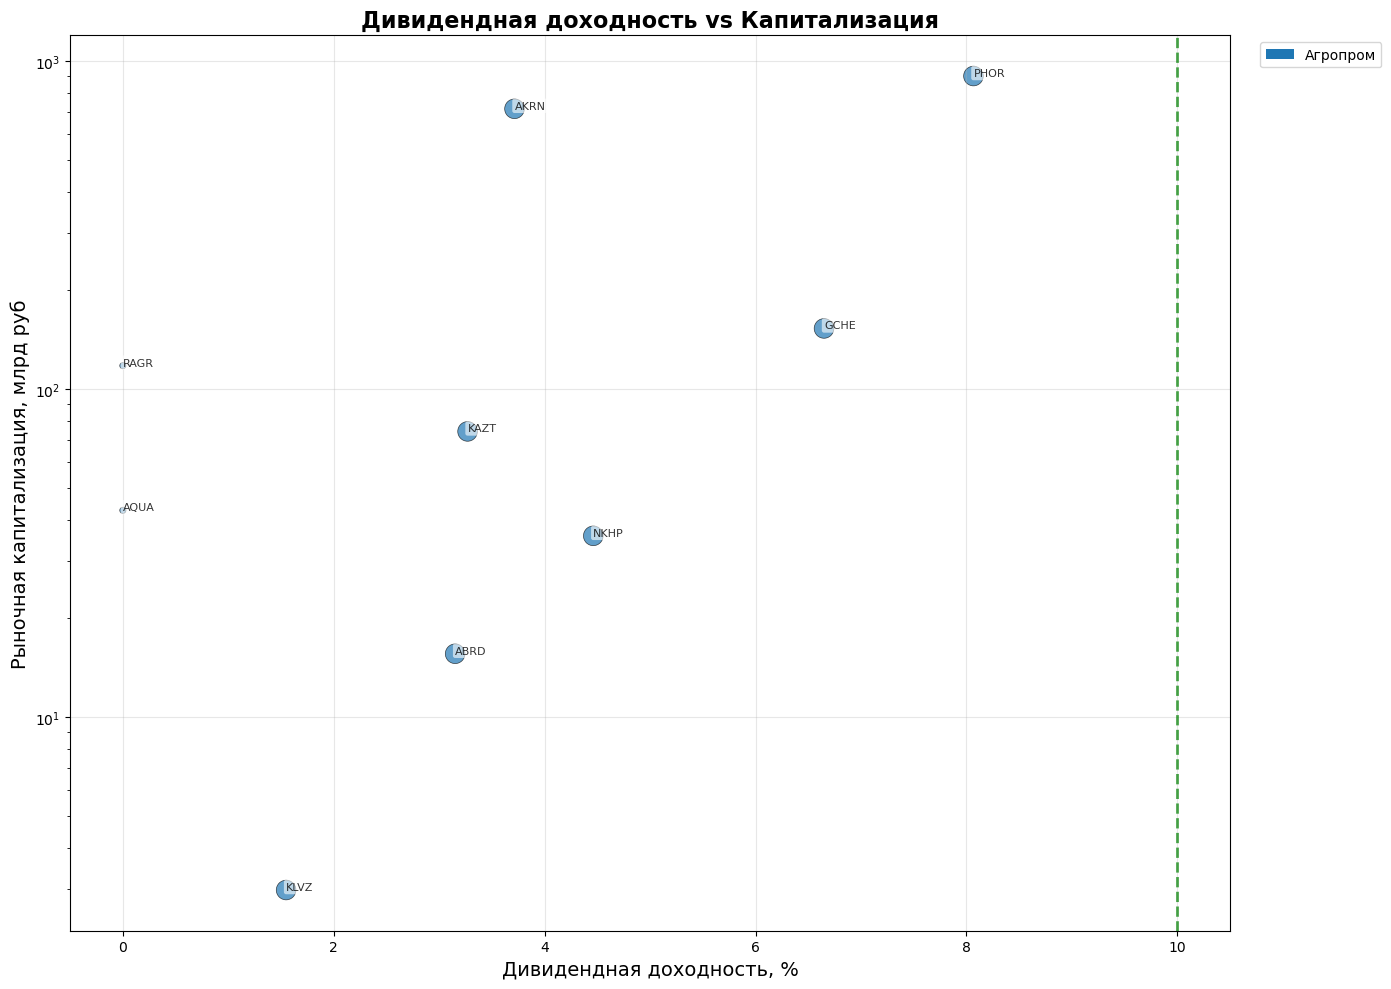

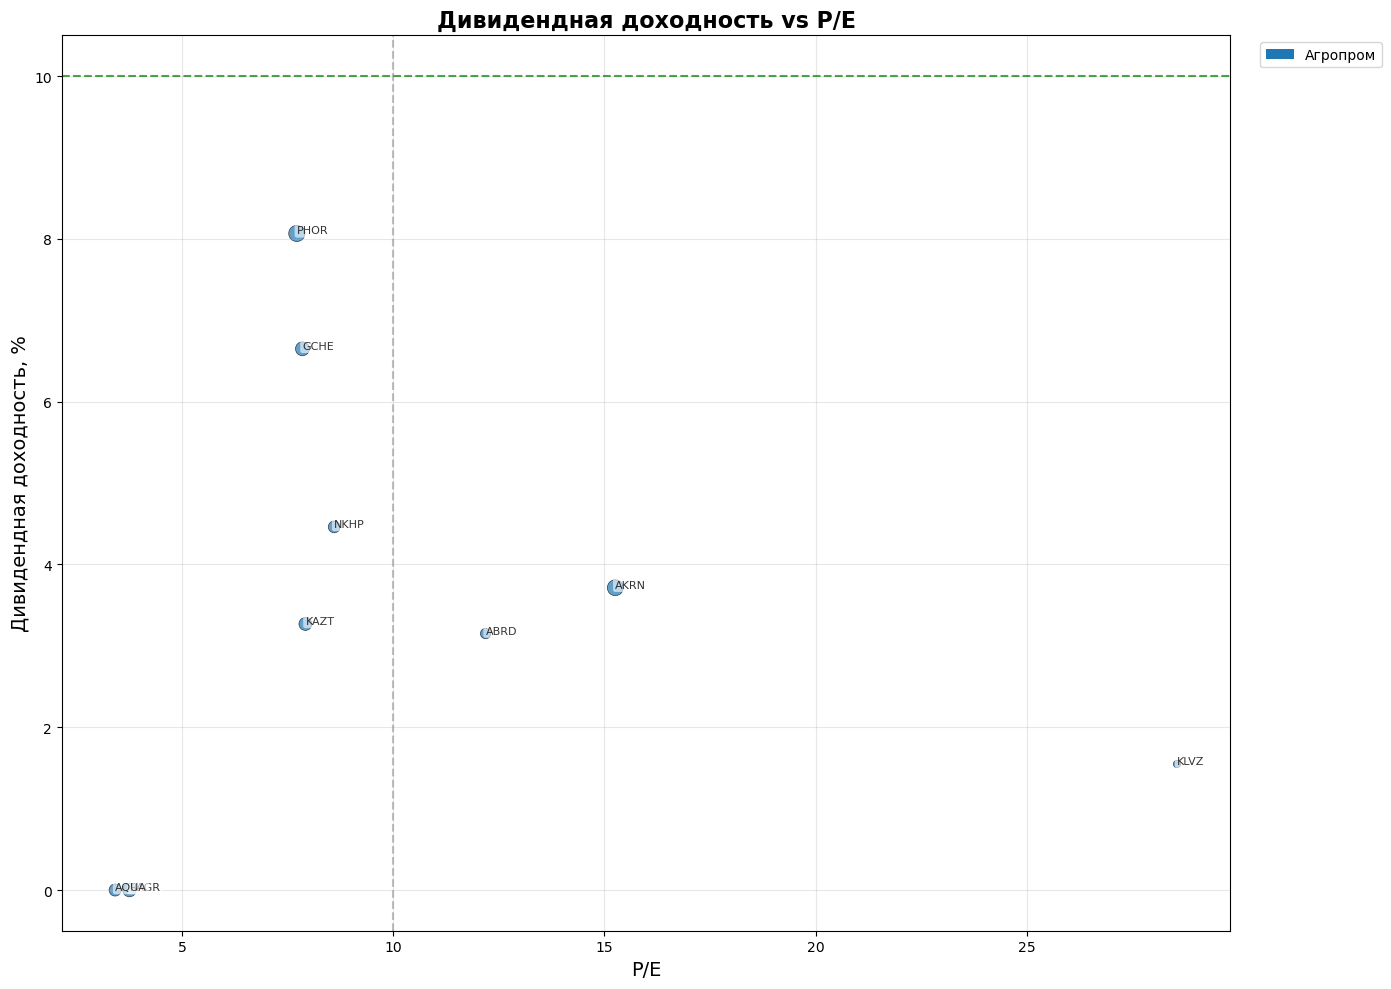

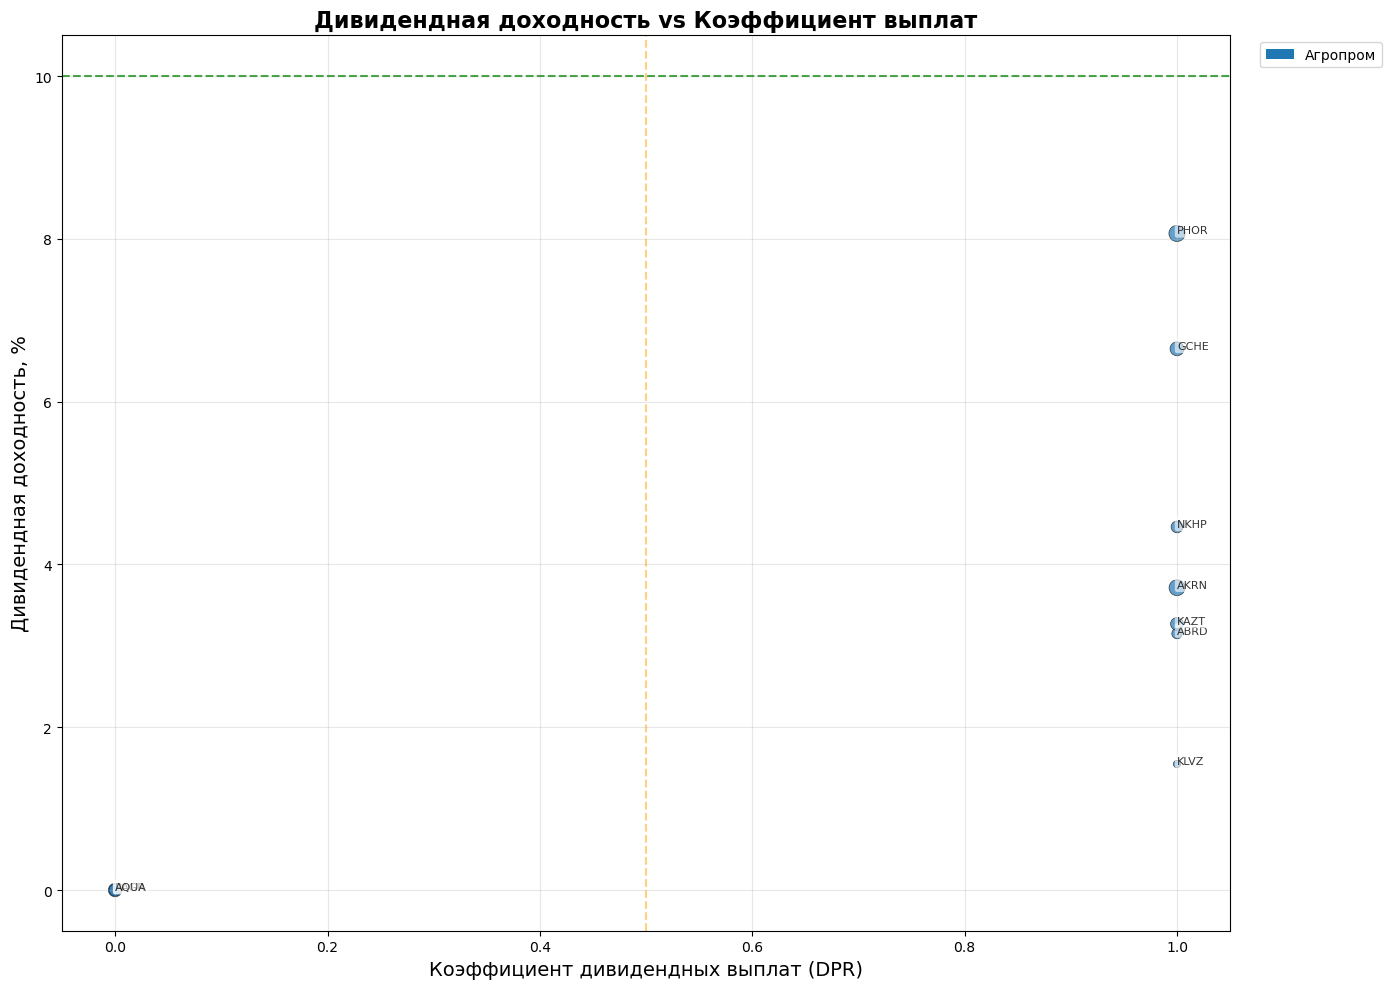

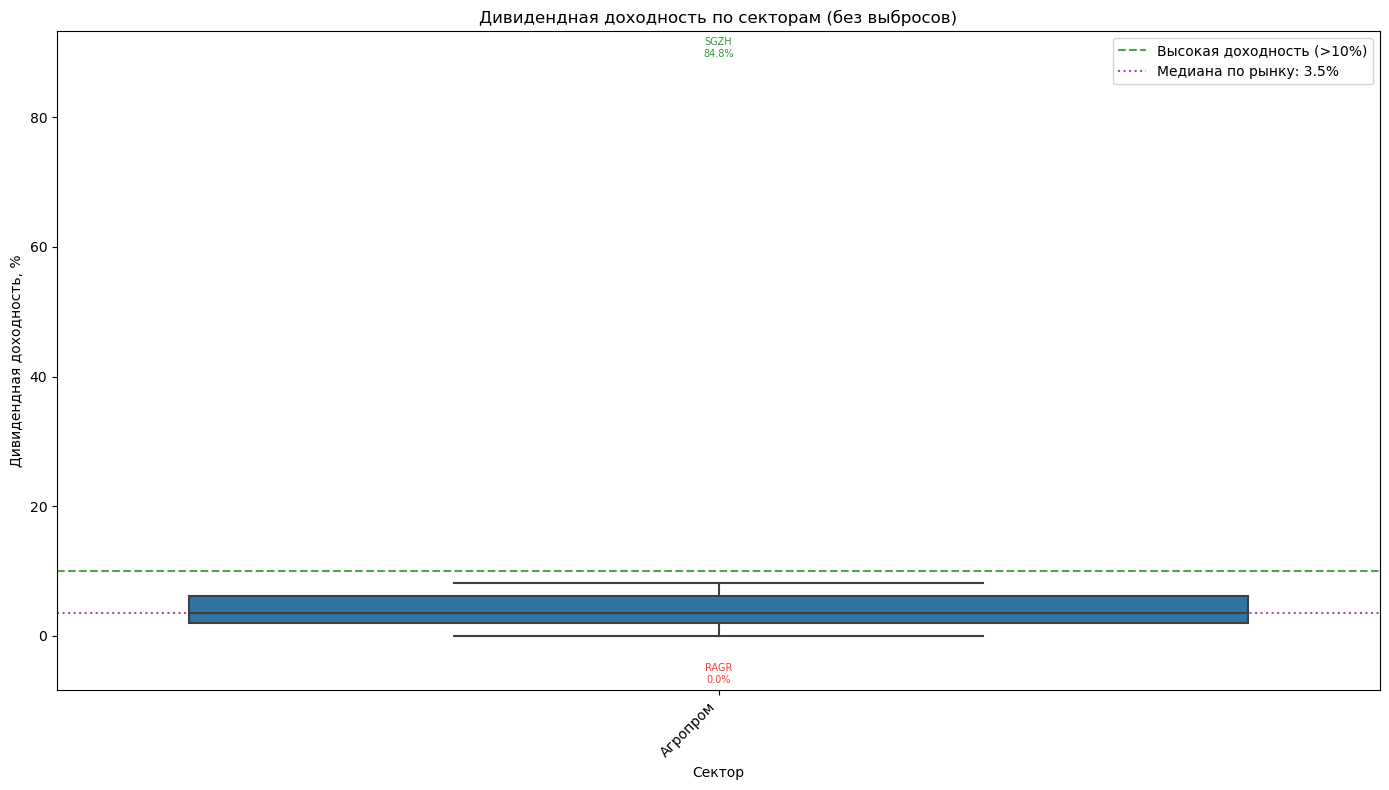

In [10]:
# Этап 5. Анализ дивидендной политики (улучшенная визуализация)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import os
from matplotlib.patches import Patch

# --- Расчёт коэффициента дивидендных выплат (DPR) ---
if 'Dividend' in df_fund.columns and 'Shares' in df_fund.columns and 'NetIncome' in df_fund.columns:
    df_fund['DPR'] = (df_fund['Dividend'] * df_fund['Shares']) / df_fund['NetIncome']
    df_fund['DPR'] = df_fund['DPR'].clip(0, 1)
else:
    df_fund['DPR'] = np.nan

# Подготовим данные
df_div = df_fund[['DivYield', 'DPR']].copy()
if 'MarketCap' in df_fund.columns:
    df_div['MarketCap'] = df_fund['MarketCap']
if 'Sector' in df_fund.columns:
    df_div['Sector'] = df_fund['Sector']
if 'P/E' in df_fund.columns:
    df_div['P/E'] = df_fund['P/E']

# Топ-15 компаний по дивидендной доходности
top_div = df_fund.nlargest(15, 'DivYield')[['DivYield', 'DPR']]
if 'Sector' in df_fund.columns:
    top_div['Sector'] = df_fund.loc[top_div.index, 'Sector']
print("Топ-15 компаний по дивидендной доходности:")
print(top_div)

# =====================================================================
# ГРАФИК 1: Scatter plot Дивидендная доходность vs Капитализация
# =====================================================================
plt.figure(figsize=(14, 10))
plot_data = df_div.dropna(subset=['DivYield', 'MarketCap']).copy()
if len(plot_data) > 0:
    # Ограничим доходность до 30% для наглядности
    plot_data = plot_data[plot_data['DivYield'] <= 30]
    
    # Цвет по секторам
    if 'Sector' in plot_data.columns:
        sectors = plot_data['Sector'].dropna().unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
        sector_color = {s: colors[i] for i, s in enumerate(sectors)}
        point_colors = [sector_color.get(s, 'gray') for s in plot_data['Sector']]
    else:
        point_colors = 'steelblue'
    
    # Размер точек – по DPR (чем больше выплаты, тем крупнее)
    if 'DPR' in plot_data.columns:
        sizes = np.clip(plot_data['DPR'] * 200, 20, 200)
    else:
        sizes = 50
    
    plt.scatter(plot_data['DivYield'], plot_data['MarketCap'],
                c=point_colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Подписи всех точек
    for ticker, row in plot_data.iterrows():
        plt.annotate(ticker, (row['DivYield'], row['MarketCap']),
                     fontsize=8, alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
    
    plt.xlabel('Дивидендная доходность, %', fontsize=14)
    plt.ylabel('Рыночная капитализация, млрд руб', fontsize=14)
    plt.title('Дивидендная доходность vs Капитализация', fontsize=16, fontweight='bold')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    # Порог высокой доходности
    plt.axvline(x=10, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Высокая доходность (>10%)')
    
    # Легенда для секторов
    if 'Sector' in plot_data.columns:
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors[:10]]
        if len(sectors) > 10:
            legend_elements.append(Patch(facecolor='gray', label='...'))
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    else:
        plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика DivYield vs MarketCap.")

# =====================================================================
# ГРАФИК 2: Scatter plot Дивидендная доходность vs P/E
# =====================================================================
plt.figure(figsize=(14, 10))
plot_data = df_div.dropna(subset=['DivYield', 'P/E']).copy()
if len(plot_data) > 0:
    plot_data = plot_data[(plot_data['DivYield'] <= 30) & (plot_data['P/E'] < 50) & (plot_data['P/E'] > 0)]
    
    if 'Sector' in plot_data.columns:
        sectors = plot_data['Sector'].dropna().unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
        sector_color = {s: colors[i] for i, s in enumerate(sectors)}
        point_colors = [sector_color.get(s, 'gray') for s in plot_data['Sector']]
    else:
        point_colors = 'steelblue'
    
    if 'MarketCap' in plot_data.columns:
        sizes = np.log1p(plot_data['MarketCap']) * 20
    else:
        sizes = 50
    
    plt.scatter(plot_data['P/E'], plot_data['DivYield'],
                c=point_colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    for ticker, row in plot_data.iterrows():
        plt.annotate(ticker, (row['P/E'], row['DivYield']),
                     fontsize=8, alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
    
    plt.xlabel('P/E', fontsize=14)
    plt.ylabel('Дивидендная доходность, %', fontsize=14)
    plt.title('Дивидендная доходность vs P/E', fontsize=16, fontweight='bold')
    plt.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Высокая доходность (>10%)')
    plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='P/E = 10')
    plt.grid(True, alpha=0.3)
    
    if 'Sector' in plot_data.columns:
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors[:10]]
        if len(sectors) > 10:
            legend_elements.append(Patch(facecolor='gray', label='...'))
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    else:
        plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика DivYield vs P/E.")

# =====================================================================
# ГРАФИК 3: Scatter plot Дивидендная доходность vs DPR
# =====================================================================
plt.figure(figsize=(14, 10))
plot_data = df_div.dropna(subset=['DivYield', 'DPR']).copy()
if len(plot_data) > 0:
    plot_data = plot_data[plot_data['DivYield'] <= 30]
    
    if 'Sector' in plot_data.columns:
        sectors = plot_data['Sector'].dropna().unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
        sector_color = {s: colors[i] for i, s in enumerate(sectors)}
        point_colors = [sector_color.get(s, 'gray') for s in plot_data['Sector']]
    else:
        point_colors = 'steelblue'
    
    if 'MarketCap' in plot_data.columns:
        sizes = np.log1p(plot_data['MarketCap']) * 20
    else:
        sizes = 50
    
    plt.scatter(plot_data['DPR'], plot_data['DivYield'],
                c=point_colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    for ticker, row in plot_data.iterrows():
        plt.annotate(ticker, (row['DPR'], row['DivYield']),
                     fontsize=8, alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
    
    plt.xlabel('Коэффициент дивидендных выплат (DPR)', fontsize=14)
    plt.ylabel('Дивидендная доходность, %', fontsize=14)
    plt.title('Дивидендная доходность vs Коэффициент выплат', fontsize=16, fontweight='bold')
    plt.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Высокая доходность (>10%)')
    plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='DPR = 0.5')
    plt.grid(True, alpha=0.3)
    
    if 'Sector' in plot_data.columns:
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors[:10]]
        if len(sectors) > 10:
            legend_elements.append(Patch(facecolor='gray', label='...'))
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    else:
        plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика DivYield vs DPR.")

# --- Boxplot дивидендной доходности по секторам с подписями экстремумов ---
if 'Sector' in df_eff.columns:
    # Исправленная функция для подписей максимума и минимума на boxplot
    def annotate_min_max(ax, data, x_col, y_col, group_col, margin=0.1):
        data_clean = data.dropna(subset=[y_col])
        if data_clean.empty:
            return
        groups = data_clean[group_col].unique()
        y_min_global = data_clean[y_col].min()
        y_max_global = data_clean[y_col].max()
        y_range = y_max_global - y_min_global
        offset = y_range * margin if y_range != 0 else 0.1

        for i, group in enumerate(groups):
            subset = data_clean[data_clean[group_col] == group]
            if len(subset) == 0:
                continue
            if subset[y_col].isnull().all():
                continue
            # Используем idxmax и idxmin для надёжного получения индексов
            max_idx = subset[y_col].idxmax()
            min_idx = subset[y_col].idxmin()
            if pd.isna(max_idx) or pd.isna(min_idx):
                continue
            max_val = subset.loc[max_idx, y_col]
            min_val = subset.loc[min_idx, y_col]

            ax.text(i, max_val + offset/2, f'{max_idx}\n{max_val:.1f}%',
                    ha='center', va='bottom', fontsize=7, color='green', alpha=0.8)
            ax.text(i, min_val - offset/2, f'{min_idx}\n{min_val:.1f}%',
                    ha='center', va='top', fontsize=7, color='red', alpha=0.8)

        ax.set_ylim(y_min_global - offset, y_max_global + offset)

    plt.figure(figsize=(14, 8))
    ax = sns.boxplot(data=df_eff, x='Sector', y='DivYield', showfliers=False)
    plt.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Высокая доходность (>10%)')
    plt.axhline(y=df_fund['DivYield'].median(), color='purple', linestyle=':', alpha=0.7,
                label=f'Медиана по рынку: {df_fund["DivYield"].median():.1f}%')
    plt.xticks(rotation=45, ha='right')
    plt.title('Дивидендная доходность по секторам (без выбросов)')
    plt.ylabel('Дивидендная доходность, %')
    plt.xlabel('Сектор')
    annotate_min_max(ax, df_eff, 'Sector', 'DivYield', 'Sector', margin=0.1)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных по секторам для построения boxplot.")

# =====================================================================
# СВОДНЫЕ ТАБЛИЦЫ В CSV С ДИНАМИЧЕСКИМИ ИМЕНАМИ
# =====================================================================

output_path = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/'
os.makedirs(output_path, exist_ok=True)
timestamp = datetime.now().strftime('%d%m%y_%H%M')
# print(f"\nСохранение файлов с меткой {timestamp}")

# ---- 1. Общая таблица дивидендных показателей ----
df_export = df_fund[['DivYield', 'DPR']].copy()
if 'Sector' in df_fund.columns:
    df_export['Sector'] = df_fund['Sector']
if 'MarketCap' in df_fund.columns:
    df_export['MarketCap'] = df_fund['MarketCap']
if 'P/E' in df_fund.columns:
    df_export['P/E'] = df_fund['P/E']
if 'NetIncome' in df_fund.columns:
    df_export['NetIncome'] = df_fund['NetIncome']

df_export.index.name = 'Ticker'
df_export.reset_index(inplace=True)

filename = f'dividend_all_{timestamp}.csv'
full_path = os.path.join(output_path, filename)
# df_export.to_csv(full_path, index=False, sep=';', float_format='%.2f')
# print(f"✅ Общая таблица дивидендов: {full_path}")

# ---- 2. Таблицы по секторам ----
if 'Sector' in df_export.columns:
    for sector in df_export['Sector'].unique():
        if pd.isna(sector):
            continue
        sector_data = df_export[df_export['Sector'] == sector].copy()
        sector_data = sector_data.sort_values('DivYield', ascending=False)
        filename = f'dividend_{sector.replace(" ", "_").replace("/", "_")}_{timestamp}.csv'
        full_path = os.path.join(output_path, filename)
        # sector_data.to_csv(full_path, index=False, sep=';', float_format='%.2f')
        # print(f"✅ Таблица сектора '{sector}': {full_path}")

# print(f"\n✅ Все файлы сохранены в папку: {output_path}")

## 💰 Этап 5: Анализ дивидендной политики – пояснения для новичков

В этом блоке мы смотрим, сколько компании платят своим акционерам в виде дивидендов, насколько стабильны эти выплаты и как они соотносятся с прибылью. Дивиденды – это «кэш на руки», поэтому для многих инвесторов это важнейший показатель.

**Основные понятия:**
- **Дивидендная доходность (DivYield)** – сколько процентов от текущей цены акции составляют годовые дивиденды. Формула: `(Дивиденд на акцию / Цена акции) × 100%`. Если акция стоит 1000₽, а дивиденд – 80₽, доходность = 8%. 
- **Коэффициент дивидендных выплат (DPR – Dividend Payout Ratio)** – доля чистой прибыли, которую компания направляет на дивиденды. DPR = 0,5 означает, что половина прибыли уходит акционерам, а половина остаётся в компании (на развитие). Слишком высокий DPR (близкий к 1) может быть неустойчивым – компания почти всю прибыль отдаёт, и ей может не хватить денег на инвестиции.

---

### 📊 График 1: Дивидендная доходность vs Капитализация

**Что изображено:**  
Каждая точка – компания. По горизонтали – дивидендная доходность (%), по вертикали – рыночная капитализация (в логарифмической шкале, чтобы уместить и мелких, и гигантов). Размер точки соответствует DPR (чем крупнее точка, тем большую долю прибыли компания тратит на дивиденды). Цвет – сектор экономики.

**Порог:** зелёная вертикальная линия на 10% – условная граница «высокой доходности». Выше неё – компании, которые платят очень щедро (но нужно проверять, не за счёт ли падения цены акции).

**Как читать:**
- Точки **справа от зелёной линии** – высокая доходность (>10%). Это потенциально интересно для дивидендных инвесторов.
- Точки **вверху справа** – крупные компании с высокой доходностью (редкое сочетание, например, Сбер или Лукойл в удачные годы).
- Точки **слева** – доходность низкая (компании либо не платят, либо платят мало, либо акции сильно выросли).
- **Размер точки** – если точка большая и при этом справа, значит компания отдаёт почти всю прибыль (DPR близок к 1). Это может быть рискованно: при спаде прибыли дивиденды могут резко сократиться.

**Что искать:**  
Крупные компании (большие точки вверху) с доходностью выше 10% и умеренным DPR (0,3–0,7) – они часто бывают «дивидендными аристократами».

---

### 📈 График 2: Дивидендная доходность vs P/E

**Что изображено:**  
По горизонтали – P/E (отношение цены к прибыли), по вертикали – дивидендная доходность. Цвет и размер точек – те же (сектор и капитализация).  

**Пороги:**  
- Зелёная горизонталь – 10% доходность.
- Серая вертикаль – P/E = 10 (условная граница «дешёвых» акций).

**Как читать:**
- **Левый верхний угол** (низкий P/E, высокая доходность) – самые интересные компании: они и дёшевы, и много платят. Это потенциально лучшие кандидаты для дивидендных инвесторов.
- **Левый нижний угол** (низкий P/E, низкая доходность) – дешёвки, но дивиденды маленькие. Возможно, компания предпочитает реинвестировать прибыль.
- **Правый верхний** (высокий P/E, высокая доходность) – редкое сочетание. Высокий P/E говорит о дорогой оценке, а высокая доходность может быть следствием падения цены (доходность = дивиденд / цена, если цена упала, доходность выросла). Стоит проверить, не связано ли с временными трудностями.
- **Правый нижний** (высокий P/E, низкая доходность) – дорогие и не платят. Обычно это компании роста (IT, биотех), которые всю прибыль вкладывают в развитие.

**Что искать:**  
Точки в левом верхнем квадранте – они сочетают низкую оценку и хорошие дивиденды.

---

### 📉 График 3: Дивидендная доходность vs DPR (коэффициент выплат)

**Что изображено:**  
По горизонтали – DPR (доля прибыли, уходящая на дивиденды), по вертикали – дивидендная доходность. Цвет и размер – те же.

**Пороги:**  
- Зелёная горизонталь – 10% доходность.
- Оранжевая вертикаль – DPR = 0,5 (половина прибыли).

**Как читать:**
- **Правый верхний угол** (высокий DPR и высокая доходность) – компании, которые отдают почти всю прибыль и приносят хороший текущий доход. Это может быть устойчиво, только если прибыль стабильна. Если DPR близок к 1, при малейшем падении прибыли дивиденды могут быть урезаны.
- **Левый верхний угол** (низкий DPR, высокая доходность) – высокая доходность достигается не за счёт большой доли прибыли, а благодаря высокой рентабельности и/или низкой цене. Это более устойчивая ситуация.
- **Точки с DPR > 1** (если такие есть) – компания платит больше, чем зарабатывает (использует резервы или долги). Это красный флаг – долго так продолжаться не может.
- **Точки с DPR = 0** – не платят дивиденды.

**Что искать:**  
Идеально – доходность > 10% при DPR 0,3–0,7. Это означает, что компания и платит хорошо, и оставляет достаточно на развитие.

---

### 📦 График 4: Boxplot – дивидендная доходность по секторам

**Что изображено:**  
Для каждого сектора нарисован «ящик с усами», показывающий распределение дивидендной доходности компаний внутри этого сектора. 
- **Зелёные подписи** – компания с максимальной доходностью в секторе.
- **Красные подписи** – компания с минимальной доходностью (или нулевой).
- **Зелёная пунктирная линия** – порог высокой доходности (10%).
- **Фиолетовая пунктирная линия** – медианная доходность по всему рынку.

**Как читать:**
- Если ящик сектора целиком выше 10% – значит, в этом секторе все компании платят очень много (редко).
- Если медиана сектора выше рыночной – сектор в целом более дивидендный.
- **Зелёные подписи** показывают лидеров сектора. Если вы ищете дивидендные идеи, обратите на них внимание.
- **Красные подписи** – аутсайдеры; возможно, они вообще не платят или платят копейки.

**Пример:** Если в секторе «Добыча» зелёная подпись – ЛУКОЙЛ с доходностью 14%, а красная – Роснефть с 6%, то понятно, кто лидер.

---

### 🏆 Топ-15 компаний по дивидендной доходности

Перед графиками выводится таблица с 15 компаниями, у которых самая высокая дивидендная доходность. Также указан DPR. Это быстрый способ увидеть, кто больше всех платит. Но помните: высокая доходность может быть результатом падения цены акции, поэтому всегда проверяйте, не было ли резкого обвала.

---

### 📁 CSV-таблицы для самостоятельного анализа

После графиков сохраняются файлы в папку `Analitika` с меткой времени (например, `dividend_all_020322_1430.csv`). В них:
- **Общая таблица** – все компании с дивидендной доходностью, DPR, сектором, капитализацией, P/E.
- **Таблицы по секторам** – отдельно по каждому сектору.

Откройте в Excel, сортируйте, фильтруйте. Например, отфильтруйте компании с DivYield > 10% и DPR < 0,7 – получите список самых интересных кандидатов.

---

### 🎯 Как использовать эту информацию для выбора акций

1. **Для дивидендного инвестора** (хочет регулярный доход):  
   – Ищите компании с доходностью выше 10% (правее зелёной линии).  
   – Проверьте, чтобы DPR был не слишком высоким (0,3–0,7) – это запас прочности.  
   – Смотрите boxplot: выбирайте сектора, где медиана выше рыночной.

2. **Для стоимостного инвестора** (ищет недооценённые активы):  
   – Смотрите график доходность vs P/E – ищите левый верхний угол.  
   – Если компания дёшева (P/E < 10) и платит приличные дивиденды, это может быть недооценка.

3. **Для инвестора в рост**: дивиденды не главное, но высокие выплаты могут сигнализировать, что компания не видит хороших возможностей для реинвестирования – для роста это минус.

4. **Важно**: высокая доходность не всегда хорошо. Если DPR близок к 1 или больше, при первом же спаде прибыли дивиденды могут быть сокращены. Также проверяйте, не упала ли цена акции – иногда доходность «вырастает» именно из-за падения котировок.

---

### ⚠️ Типичные ловушки для новичков

- **Высокая доходность ≠ хорошие инвестиции.** Всегда смотрите, за счёт чего она высокая. Если цена упала на 50%, а дивиденд остался прежним, доходность формально выросла, но вы потеряли половину капитала.
- **DPR > 1** – компания платит больше, чем зарабатывает. Обычно это заканчивается плохо.
- **DPR = 0** – компания не платит. Это не обязательно плохо, если она направляет прибыль на рост.
- **Сравнивайте внутри сектора.** То, что нормально для нефтянки (доходность 8–10%), может быть аномалией для IT (где обычно 0–2%).

Пользуйтесь графиками и таблицами, но всегда дополняйте анализом долгов, рентабельности и денежных потоков. Удачных инвестиций!

<div class="alert alert-info">
</div>

**Этап 6. Качественный анализ (прокси-метрики). Визуализация рейтингов**

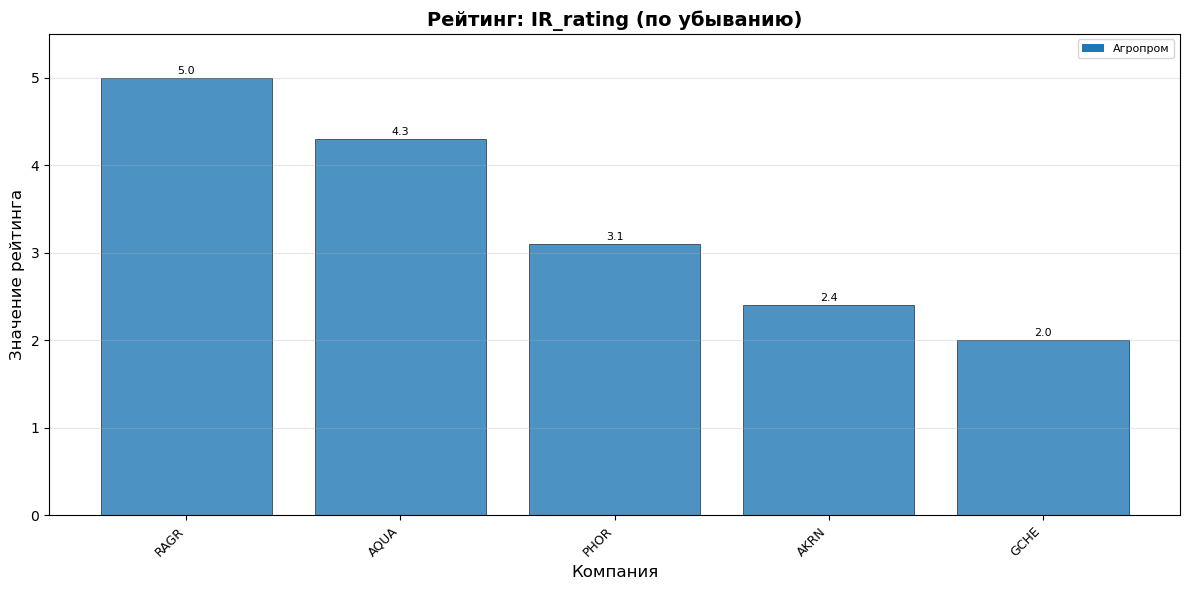

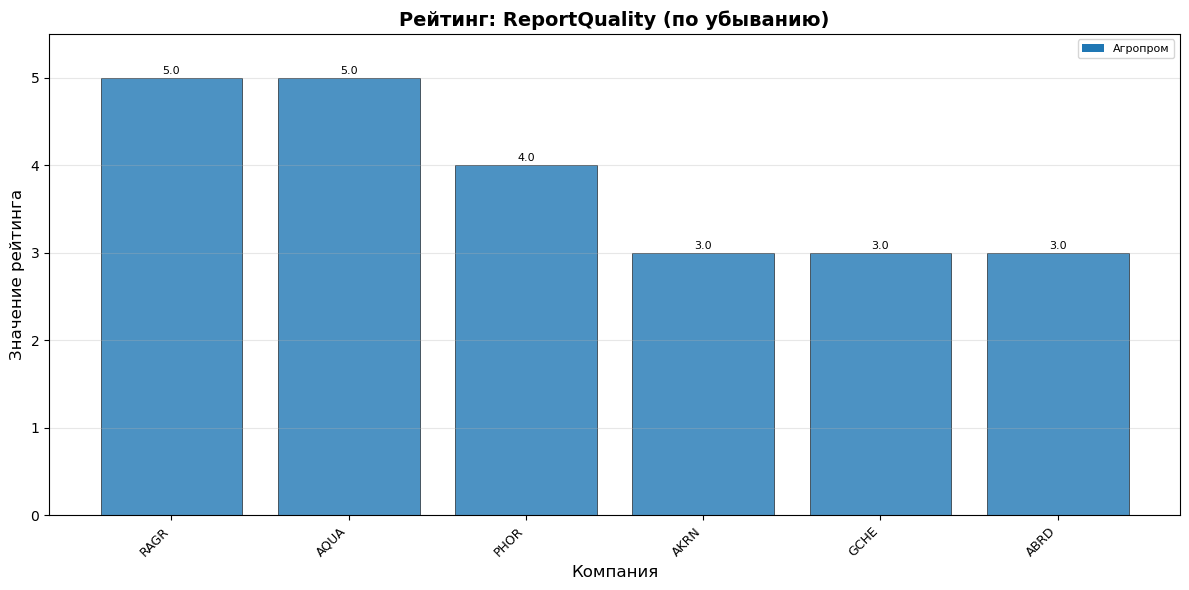

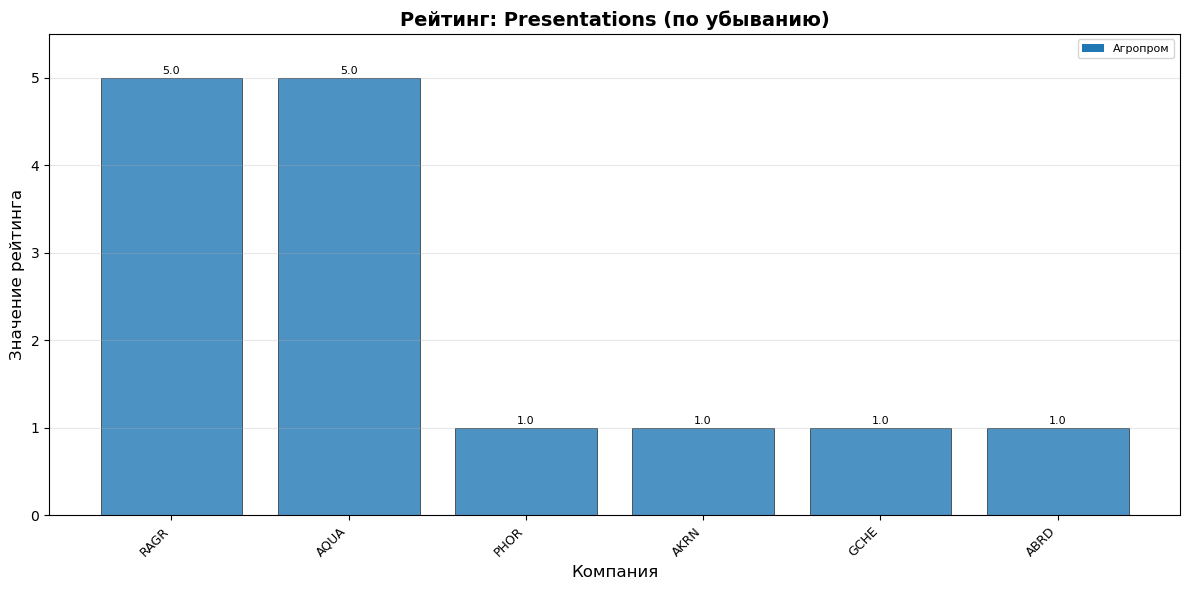

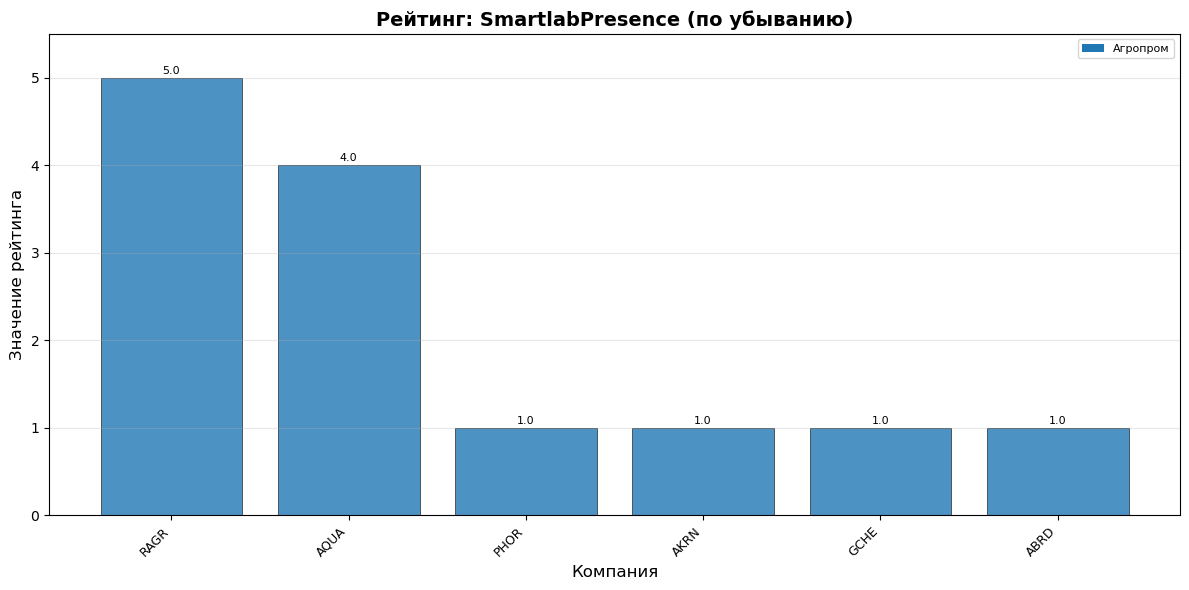

Нет данных для AnnualReport


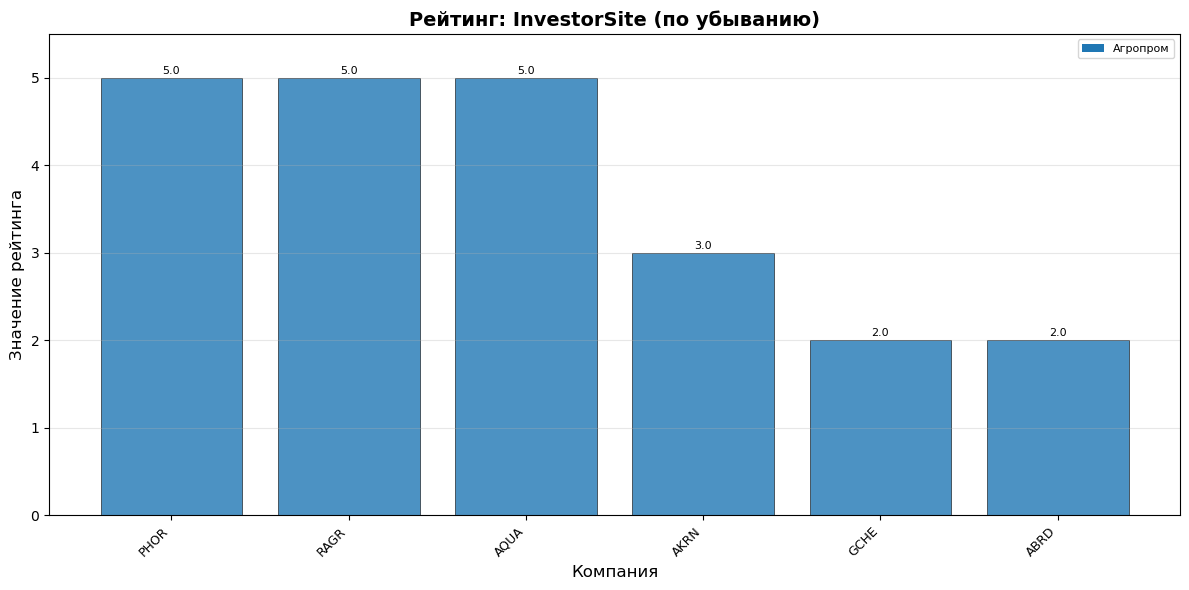

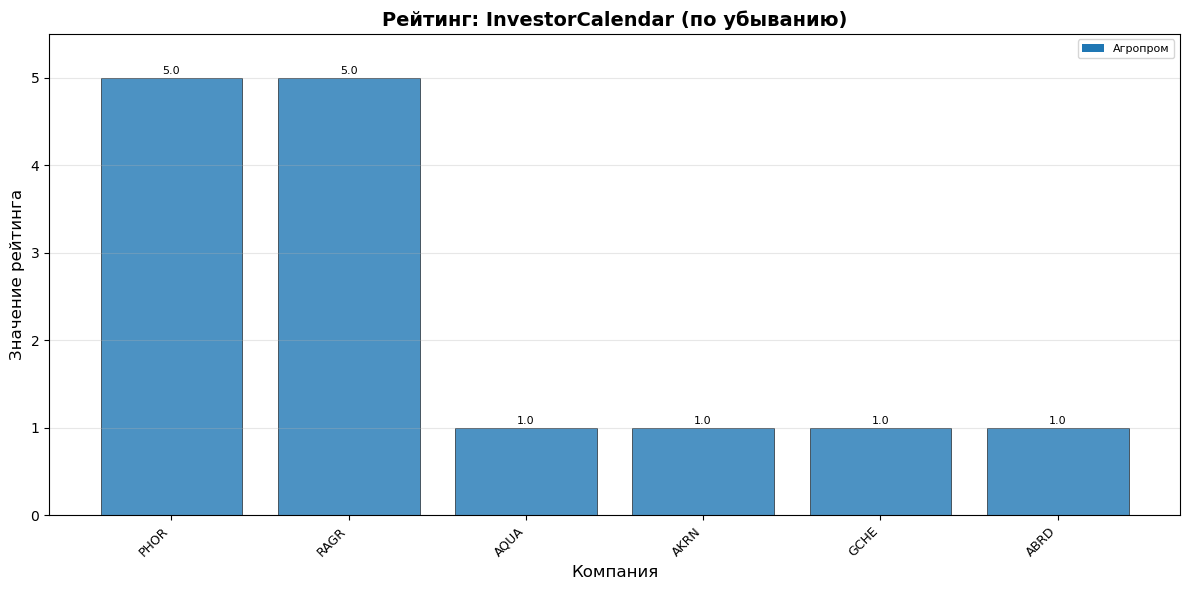

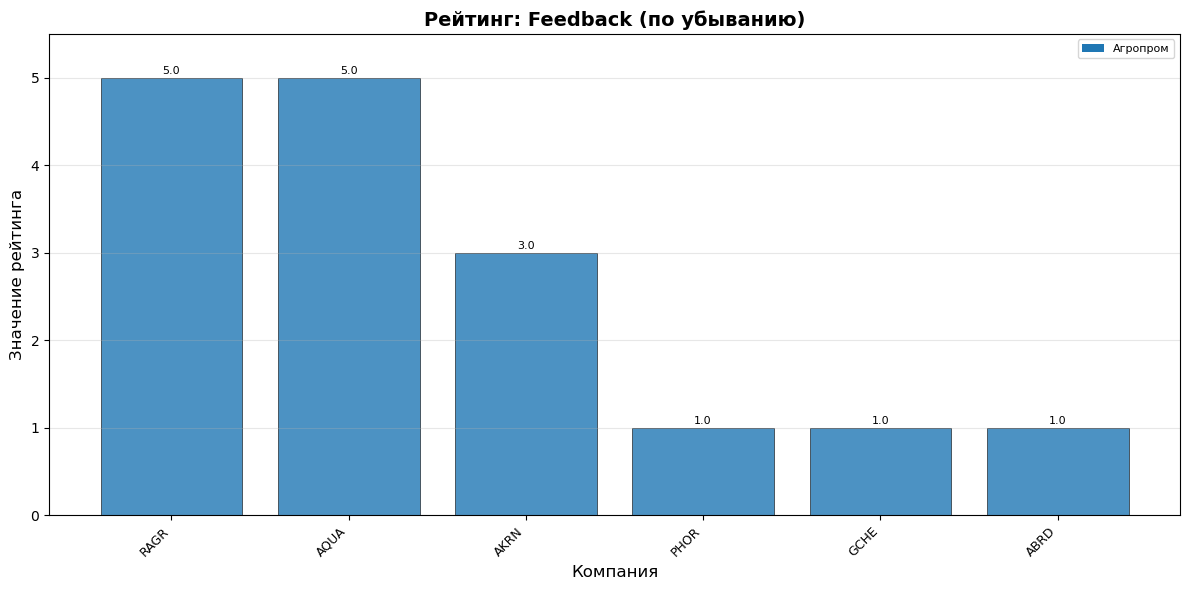


Средние значения рейтингов по секторам:
          IR_rating  ReportQuality  Presentations  SmartlabPresence  \
Sector                                                                
Агропром       3.36           3.83           2.33              2.17   

          AnnualReport  InvestorSite  InvestorCalendar  Feedback  
Sector                                                            
Агропром           NaN          3.67              2.33      2.67  
✅ Общая таблица рейтингов: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/ratings_all_130326_1836.csv
✅ Таблица сектора 'Агропром': C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/ratings_Агропром_130326_1836.csv

✅ Все файлы Этапа 6 сохранены в папку: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/


In [11]:
# Этап 6. Качественный анализ (прокси-метрики) — вертикальные гистограммы

# Список рейтинговых колонок, которые могли загрузиться
rating_cols = ['IR_rating', 'ReportQuality', 'Presentations', 'SmartlabPresence',
               'AnnualReport', 'InvestorSite', 'InvestorCalendar', 'Feedback']
existing_ratings = [col for col in rating_cols if col in df_fund.columns]

if not existing_ratings:
    print("Рейтинги не загружены. Проверьте, есть ли они в исходных данных и правильно ли выполнена загрузка.")
else:
    # Убедимся, что сектора загружены
    if 'Sector' not in df_fund.columns:
        try:
            # Загружаем сектора из файла SECTOR_FILE
            liquid_full = pd.read_excel(SECTOR_FILE, sheet_name='Sector', engine='openpyxl', header=0)
            liquid_full = liquid_full[['Код инструмента', 'Категории']].copy()
            liquid_full.rename(columns={'Код инструмента': 'Ticker', 'Категории': 'Sector'}, inplace=True)
            liquid_full = liquid_full.drop_duplicates(subset='Ticker')
            liquid_full.set_index('Ticker', inplace=True)
            df_fund['Sector'] = liquid_full['Sector']
        except Exception as e:
            print(f"Не удалось загрузить сектора: {e}, продолжаем без них.")

    # =====================================================================
    # ВЕРТИКАЛЬНЫЕ СТОЛБЧАТЫЕ ДИАГРАММЫ ДЛЯ КАЖДОГО РЕЙТИНГА
    # (компании по оси X, рейтинг по оси Y, подписи всех компаний)
    # =====================================================================
    if 'Sector' in df_fund.columns:
        for rating in existing_ratings:
            # Подготовим данные: убираем пропуски, сортируем по убыванию рейтинга
            plot_data = df_fund[[rating, 'Sector']].dropna().copy()
            if plot_data.empty:
                print(f"Нет данных для {rating}")
                continue
            
            plot_data = plot_data.sort_values(rating, ascending=False).reset_index()
            plot_data.rename(columns={'index': 'Ticker'}, inplace=True)
            
            # Определим цвета по секторам
            sectors = plot_data['Sector'].unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
            sector_color = {s: colors[i] for i, s in enumerate(sectors)}
            bar_colors = [sector_color[s] for s in plot_data['Sector']]
            
            # Создаем фигуру с адаптивным размером
            fig_height = max(6, len(plot_data) * 0.4)  # примерно 0.4 дюйма на компанию
            plt.figure(figsize=(max(12, len(plot_data) * 0.5), fig_height))
            
            x_pos = np.arange(len(plot_data))
            bars = plt.bar(x_pos, plot_data[rating].values, color=bar_colors, 
                           alpha=0.8, edgecolor='black', linewidth=0.5)
            
            plt.xticks(x_pos, plot_data['Ticker'].values, rotation=45, ha='right', fontsize=9)
            plt.ylabel('Значение рейтинга', fontsize=12)
            plt.xlabel('Компания', fontsize=12)
            plt.title(f'Рейтинг: {rating} (по убыванию)', fontsize=14, fontweight='bold')
            
            # Добавляем значения на столбцы
            for i, (bar, val) in enumerate(zip(bars, plot_data[rating])):
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                         f'{val:.1f}', ha='center', va='bottom', fontsize=8)
            
            # Легенда для секторов
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors]
            plt.legend(handles=legend_elements, loc='upper right', fontsize=8)
            
            plt.grid(axis='y', alpha=0.3)
            plt.ylim(0, plot_data[rating].max() * 1.1)  # небольшой отступ сверху
            plt.tight_layout()
            plt.show()
    else:
        print("Нет данных о секторах для построения рейтинговых диаграмм.")

    # --- Таблица средних рейтингов по секторам ---
    if 'Sector' in df_fund.columns:
        sector_ratings = df_fund.groupby('Sector')[existing_ratings].mean().round(2)
        print("\nСредние значения рейтингов по секторам:")
        print(sector_ratings)
    else:
        print("Нет данных о секторах.")

    # =====================================================================
    # СВОДНЫЕ ТАБЛИЦЫ В CSV С ДИНАМИЧЕСКИМИ ИМЕНАМИ
    # =====================================================================
    output_path = 'C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/'
    os.makedirs(output_path, exist_ok=True)
    timestamp = datetime.now().strftime('%d%m%y_%H%M')

    # ---- 1. Общая таблица рейтингов ----
    df_export = df_fund[existing_ratings].copy()
    if 'Sector' in df_fund.columns:
        df_export['Sector'] = df_fund['Sector']
    if 'MarketCap' in df_fund.columns:
        df_export['MarketCap'] = df_fund['MarketCap']

    df_export.index.name = 'Ticker'
    df_export.reset_index(inplace=True)

    filename = f'ratings_all_{timestamp}.csv'
    full_path = os.path.join(output_path, filename)
    df_export.to_csv(full_path, index=False, sep=';', float_format='%.2f')
    print(f"✅ Общая таблица рейтингов: {full_path}")

    # ---- 2. Таблицы по секторам ----
    if 'Sector' in df_export.columns:
        for sector in df_export['Sector'].unique():
            if pd.isna(sector):
                continue
            sector_data = df_export[df_export['Sector'] == sector].copy()
            # Сортируем по рейтингу, если он есть
            sort_col = 'IR_rating' if 'IR_rating' in sector_data.columns else 'Ticker'
            sector_data = sector_data.sort_values(sort_col, ascending=False)
            filename = f'ratings_{sector.replace(" ", "_").replace("/", "_")}_{timestamp}.csv'
            full_path = os.path.join(output_path, filename)
            sector_data.to_csv(full_path, index=False, sep=';', float_format='%.2f')
            print(f"✅ Таблица сектора '{sector}': {full_path}")

    print(f"\n✅ Все файлы Этапа 6 сохранены в папку: {output_path}")

### Интерпретация графиков качественного анализа

#### 1. Гистограмма распределения IR рейтинга

- **Ось X** – значение IR рейтинга (от 1 до 5). Оценка качества взаимодействия компании с инвесторами:
  - `1` – очень низкое,
  - `5` – отличное.
- **Ось Y** – количество компаний, попавших в каждый интервал.

**Что показывает**:
- Если основная масса компаний сосредоточена справа (4–5), значит, рынок в целом прозрачен, и компании активно работают с инвесторами.
- Смещение влево (1–3) может говорить о недостаточном внимании к IR или закрытости компаний.
- **Среднее** и **медиана** дают представление о типичном уровне качества IR. Медиана более устойчива к выбросам.

---

#### 2. Boxplot для каждого рейтинга по секторам

На каждом графике показано распределение одного из рейтингов по секторам.

- **Ящик** отображает интерквартильный размах (Q1–Q3), линия внутри – медиану.
- **Подписи**:
  - **Зелёным** – компания с **максимальным** значением рейтинга в данном секторе (лидер).
  - **Красным** – компания с **минимальным** значением (аутсайдер).
  
Это позволяет быстро идентифицировать лучших и худших представителей в каждой отрасли.

**Как интерпретировать**:
- Высокие медианы по сектору говорят о том, что в этой отрасли в целом хорошее корпоративное управление.
- Большой разброс (длинные ящики) указывает на неоднородность: есть как образцовые компании, так и отстающие.
- Обратите внимание на компании, отмеченные зелёным – они могут служить ориентиром качества. Красные – повод для дополнительной проверки.

---

#### 3. Таблица средних рейтингов по секторам

Числовые значения позволяют сравнивать сектора между собой.

*Пример*: если в секторе «Финансы» средний IR_rating = 4,5, а в «Металлургии» = 3,2, то финансовые компании в среднем более открыты для инвесторов.

---

### Как использовать качественные метрики в инвестиционном анализе

- **Высокие рейтинги** обычно коррелируют с меньшими рисками корпоративного мошенничества, более предсказуемой дивидендной политикой и лучшей защитой прав миноритариев.
- **Низкие рейтинги** – сигнал к осторожности: стоит изучить, почему компания не публикует отчёты, не проводит презентации, не отвечает на запросы.
- Эти метрики особенно важны для **долгосрочных инвесторов**, планирующих держать акции годами.
- Однако рейтинги – лишь **прокси**; они не заменяют глубокого анализа, но помогают быстро отсеять компании с очевидными проблемами в корпоративном управлении.

<div class="alert alert-info">
</div>

**Этап 7. Формирование аналитических метрик для скрининга**

После удаления пропусков в ['P/E', 'ROE'] осталось 10 компаний.
Топ-20 компаний по интегральному рейтингу (меньше = лучше):
          Sector        P/E   ROE   DivYield  NetDebt/EBITDA  Composite_Rank
Ticker                                                                      
PHOR    Агропром   7.718081  53.3   8.066139        1.139333            25.0
KAZT    Агропром   7.921109   9.7   3.268765        0.608187            28.0
GCHE    Агропром   7.851282  13.0   6.649103        2.357522            31.0
NKHP    Агропром   8.602410  25.5   4.460960       -1.097510            33.0
RAGR    Агропром   3.754777  14.7   0.000000        1.947177            35.5
AQUA    Агропром   3.416000  36.3   0.000000        1.828947            37.5
AKRN    Агропром  15.257996  21.3   3.713787        1.359589            42.0
SGZH    Агропром  -2.478481 -70.2  84.800000       26.960352            48.0
ABRD    Агропром  12.187500   9.6   3.150943        3.013793            50.0
KLVZ    Агропром  28.557692  

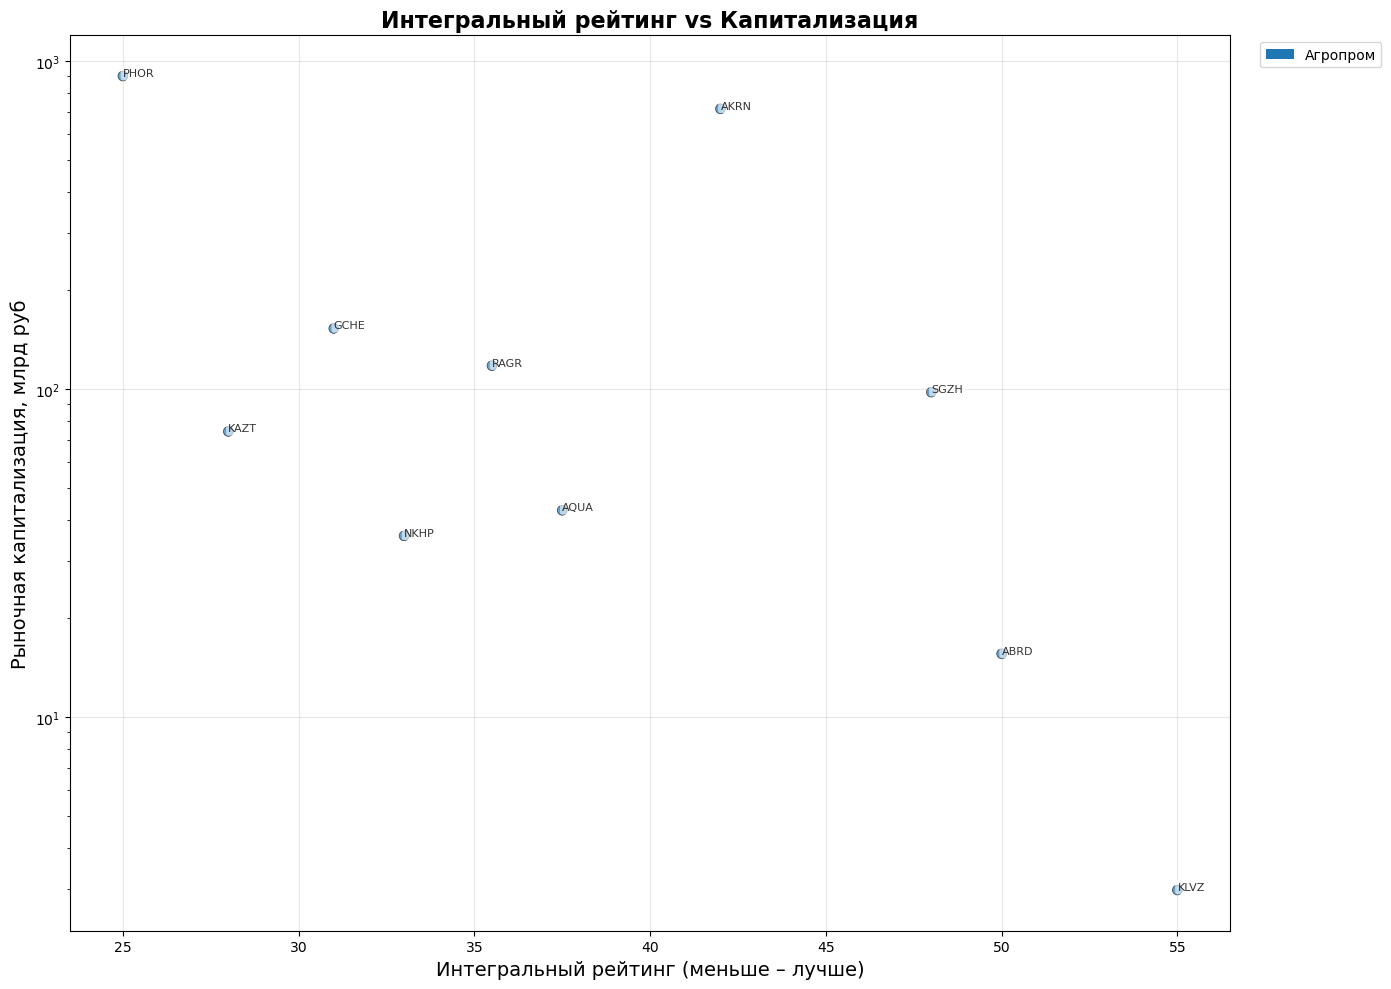

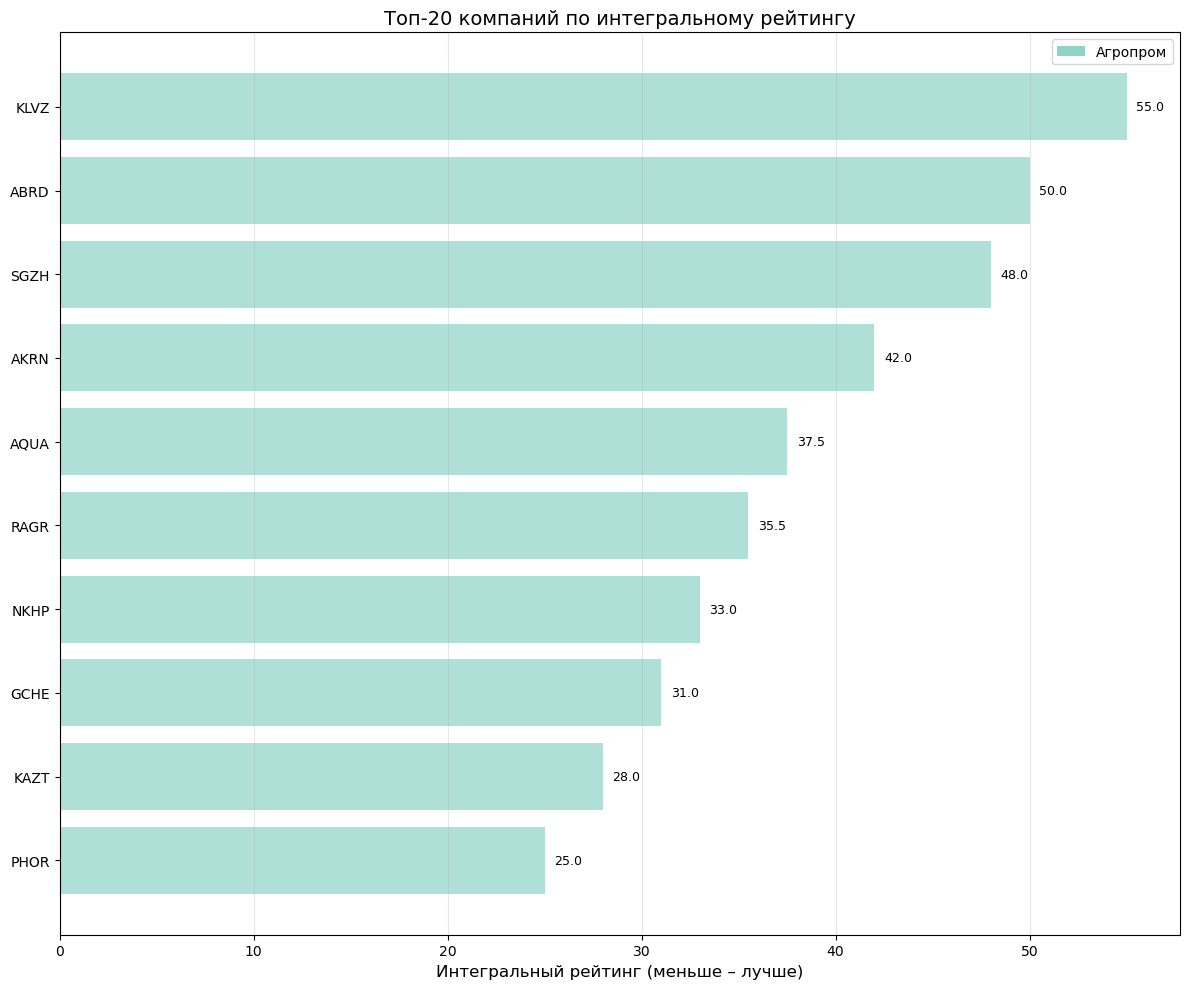


Всего секторов: 1


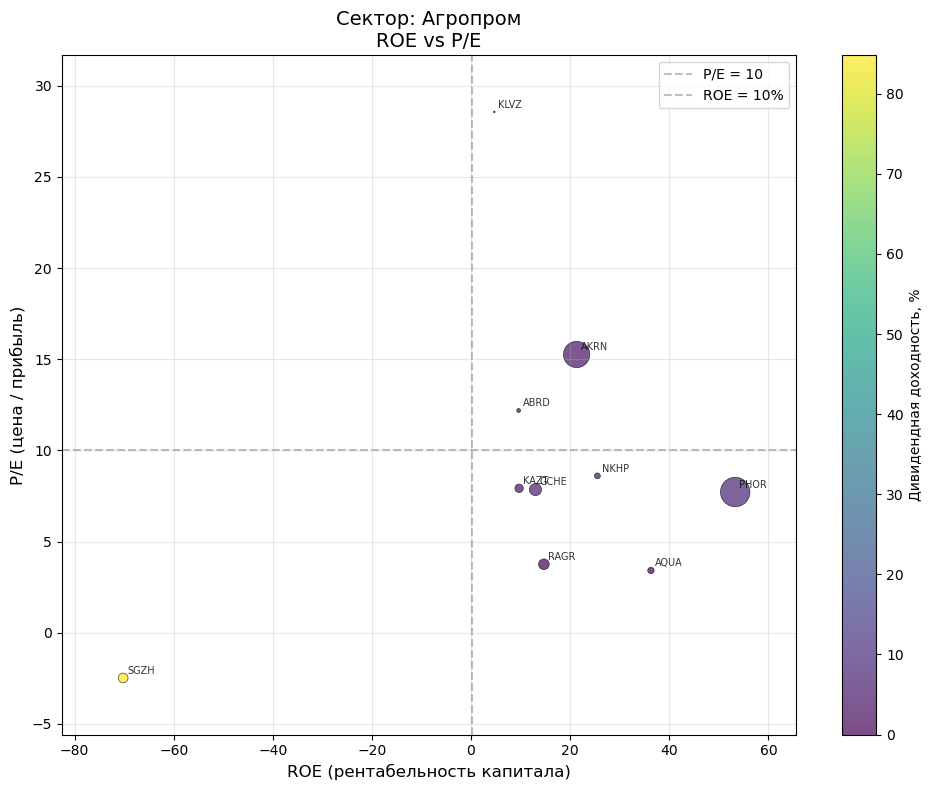


Сохранение файлов с меткой 130326_1836
✅ Общая таблица скрининга: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/screening_all_130326_1836.csv


In [12]:
# Этап 7. Формирование аналитических метрик для скрининга – улучшенная визуализация

# Приводим название рентабельности к единому виду
if 'ROE_raw' in df_fund.columns and 'ROE' not in df_fund.columns:
    df_fund['ROE'] = df_fund['ROE_raw']
elif 'ROE' not in df_fund.columns:
    print("Внимание: колонка ROE отсутствует. Рейтинг будет рассчитан без неё.")

# Выбираем ключевые метрики
metrics = ['MarketCap', 'P/E', 'P/B', 'EV/EBITDA', 'ROE', 'NetDebt/EBITDA', 'DivYield', 'FCF']
available_metrics = [m for m in metrics if m in df_fund.columns]
if not available_metrics:
    raise ValueError("Нет доступных метрик для анализа.")

df_screen = df_fund[['Sector'] + available_metrics].copy()

# Определяем обязательные метрики, без которых компания не может участвовать в рейтинге
mandatory_cols = ['P/E', 'ROE']
# Оставляем только те обязательные, которые реально есть в данных
mandatory_existing = [col for col in mandatory_cols if col in df_screen.columns]

if mandatory_existing:
    # Удаляем строки, где отсутствуют данные по обязательным метрикам
    df_screen = df_screen.dropna(subset=mandatory_existing)
    print(f"После удаления пропусков в {mandatory_existing} осталось {len(df_screen)} компаний.")
else:
    print("Нет обязательных метрик для фильтрации. Используем все данные.")

# Ранжирование (по всем доступным метрикам, включая необязательные)
if 'P/E' in df_screen.columns:
    df_screen['Rank_P/E'] = df_screen['P/E'].rank()
if 'P/B' in df_screen.columns:
    df_screen['Rank_P/B'] = df_screen['P/B'].rank()
if 'EV/EBITDA' in df_screen.columns:
    df_screen['Rank_EV/EBITDA'] = df_screen['EV/EBITDA'].rank()
if 'NetDebt/EBITDA' in df_screen.columns:
    df_screen['Rank_NetDebt/EBITDA'] = df_screen['NetDebt/EBITDA'].rank()
if 'ROE' in df_screen.columns:
    df_screen['Rank_ROE'] = df_screen['ROE'].rank(ascending=False)
if 'DivYield' in df_screen.columns:
    df_screen['Rank_DivYield'] = df_screen['DivYield'].rank(ascending=False)
if 'FCF' in df_screen.columns:
    df_screen['Rank_FCF'] = df_screen['FCF'].rank(ascending=False)

# Составной рейтинг (сумма рангов, игнорируем NaN)
rank_cols = [col for col in df_screen.columns if col.startswith('Rank_')]
if rank_cols:
    df_screen['Composite_Rank'] = df_screen[rank_cols].sum(axis=1, skipna=True)
else:
    print("Нет ранжированных колонок. Составной рейтинг не рассчитан.")

# --- Топ-20 по интегральному рейтингу (таблица) ---
if 'Composite_Rank' in df_screen.columns and not df_screen.empty:
    df_screen_sorted = df_screen.sort_values('Composite_Rank').head(20)
    print("Топ-20 компаний по интегральному рейтингу (меньше = лучше):")
    display_cols = ['Sector', 'P/E', 'ROE', 'DivYield', 'NetDebt/EBITDA', 'Composite_Rank']
    existing_display = [col for col in display_cols if col in df_screen_sorted.columns]
    print(df_screen_sorted[existing_display])
else:
    print("Недостаточно данных для построения топа.")

# =====================================================================
# ВИЗУАЛИЗАЦИЯ 1: Scatter plot Composite_Rank vs MarketCap (все компании)
# =====================================================================
if 'Composite_Rank' in df_screen.columns and 'MarketCap' in df_screen.columns and not df_screen.empty:
    plt.figure(figsize=(14, 10))
    plot_data = df_screen[['MarketCap', 'Composite_Rank', 'Sector']].dropna()
    if len(plot_data) > 0:
        # Цвет по секторам
        sectors = plot_data['Sector'].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
        sector_color = {s: colors[i] for i, s in enumerate(sectors)}
        point_colors = [sector_color.get(s, 'gray') for s in plot_data['Sector']]
        
        plt.scatter(plot_data['Composite_Rank'], plot_data['MarketCap'],
                    c=point_colors, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Подписи всех точек
        for ticker, row in plot_data.iterrows():
            plt.annotate(ticker, (row['Composite_Rank'], row['MarketCap']),
                         fontsize=8, alpha=0.8,
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
        
        plt.xlabel('Интегральный рейтинг (меньше – лучше)', fontsize=14)
        plt.ylabel('Рыночная капитализация, млрд руб', fontsize=14)
        plt.title('Интегральный рейтинг vs Капитализация', fontsize=16, fontweight='bold')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors[:10]]
        if len(sectors) > 10:
            legend_elements.append(Patch(facecolor='gray', label='...'))
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для графика Composite_Rank vs MarketCap.")
else:
    print("Недостаточно данных для графика Composite_Rank vs MarketCap.")

# =====================================================================
# ВИЗУАЛИЗАЦИЯ 2: Топ-20 компаний в виде горизонтальной столбчатой диаграммы
# =====================================================================
if 'Composite_Rank' in df_screen.columns and not df_screen.empty:
    top20 = df_screen.nsmallest(20, 'Composite_Rank')
    if not top20.empty:
        plt.figure(figsize=(12, 10))
        
        # Сортировка для отображения (лучшие сверху)
        top20_sorted = top20.sort_values('Composite_Rank', ascending=True)
        
        # Цвета по секторам
        sectors = top20_sorted['Sector'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(sectors)))
        sector_color = {s: colors[i] for i, s in enumerate(sectors)}
        bar_colors = [sector_color[s] for s in top20_sorted['Sector']]
        
        bars = plt.barh(range(len(top20_sorted)), top20_sorted['Composite_Rank'].values,
                        color=bar_colors, alpha=0.7)
        plt.yticks(range(len(top20_sorted)), top20_sorted.index)
        plt.xlabel('Интегральный рейтинг (меньше – лучше)', fontsize=12)
        plt.title('Топ-20 компаний по интегральному рейтингу', fontsize=14)
        
        # Добавим значения рейтинга справа от столбцов
        for i, (bar, val) in enumerate(zip(bars, top20_sorted['Composite_Rank'])):
            plt.text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=9)
        
        # Легенда для секторов
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors]
        plt.legend(handles=legend_elements, loc='upper right')
        
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно данных для построения топ-20 диаграммы.")
else:
    print("Недостаточно данных для построения топ-20 диаграммы.")

# =====================================================================
# ВИЗУАЛИЗАЦИЯ 3: Scatter plot ROE vs P/E по секторам
# =====================================================================
if 'ROE' in df_screen.columns and 'P/E' in df_screen.columns and 'Sector' in df_screen.columns and not df_screen.empty:
    sectors = df_screen['Sector'].dropna().unique()
    print(f"\nВсего секторов: {len(sectors)}")

    # Определяем общие границы для всех секторов, чтобы графики были сопоставимы
    roe_min, roe_max = df_screen['ROE'].min(), df_screen['ROE'].max()
    pe_min, pe_max = df_screen['P/E'].min(), df_screen['P/E'].max()
    roe_margin = (roe_max - roe_min) * 0.1 if roe_max != roe_min else 0.1
    pe_margin = (pe_max - pe_min) * 0.1 if pe_max != pe_min else 0.1

    for sector in sectors:
        data_sector = df_screen[df_screen['Sector'] == sector].copy()
        if len(data_sector) == 0:
            continue

        sizes = data_sector['MarketCap'] / 2 if 'MarketCap' in data_sector.columns else 50

        plt.figure(figsize=(10, 8))
        sc = plt.scatter(
            data_sector['ROE'],
            data_sector['P/E'],
            c=data_sector['DivYield'] if 'DivYield' in data_sector.columns else 'blue',
            s=sizes,
            alpha=0.7,
            cmap='viridis',
            edgecolors='black',
            linewidth=0.5
        )

        if 'DivYield' in data_sector.columns:
            cbar = plt.colorbar(sc)
            cbar.set_label('Дивидендная доходность, %', fontsize=10)

        plt.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='P/E = 10')
        plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='ROE = 10%')

        for idx, row in data_sector.iterrows():
            plt.annotate(
                idx,
                (row['ROE'], row['P/E']),
                fontsize=7,
                xytext=(3, 3),
                textcoords='offset points',
                alpha=0.8
            )

        plt.xlim(roe_min - roe_margin, roe_max + roe_margin)
        plt.ylim(pe_min - pe_margin, pe_max + pe_margin)
        plt.xlabel('ROE (рентабельность капитала)', fontsize=12)
        plt.ylabel('P/E (цена / прибыль)', fontsize=12)
        plt.title(f'Сектор: {sector}\nROE vs P/E', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Нет данных для построения графиков ROE vs P/E по секторам.")

# ===================== СОХРАНЕНИЕ ИТОГОВОЙ ТАБЛИЦЫ =====================
timestamp = datetime.now().strftime('%d%m%y_%H%M')
print(f"\nСохранение файлов с меткой {timestamp}")

# --- Общая таблица скрининга ---
if not df_screen.empty:
    df_export = df_screen.copy()
    df_export.index.name = 'Ticker'
    df_export.reset_index(inplace=True)
    main_cols = ['Ticker', 'Sector'] + available_metrics + (['Composite_Rank'] if 'Composite_Rank' in df_export.columns else [])
    main_cols = [col for col in main_cols if col in df_export.columns]
    df_export = df_export[main_cols]

    filename = f'screening_all_{timestamp}.csv'
    full_path = os.path.join(output_path, filename)
    df_export.to_csv(full_path, index=False, sep=';', float_format='%.2f')
    print(f"✅ Общая таблица скрининга: {full_path}")
else:
    print("Нет данных для сохранения таблицы скрининга.")

## 📊 Этап 7: Интегральный рейтинг компаний – пояснения для новичков

На этом этапе мы объединяем несколько важных показателей в один **интегральный рейтинг**, чтобы быстро сравнивать компании между собой. Чем меньше значение рейтинга – тем лучше компания по совокупности факторов.

**Какие показатели участвуют:**
- **P/E** (чем ниже, тем лучше)
- **P/B** (чем ниже, тем лучше)
- **EV/EBITDA** (чем ниже, тем лучше)
- **NetDebt/EBITDA** (чем ниже, тем лучше)
- **ROE** (рентабельность капитала – чем выше, тем лучше)
- **DivYield** (дивидендная доходность – чем выше, тем лучше)
- **FCF** (свободный денежный поток – чем больше, тем лучше)

Каждому показателю присваивается ранг (место) среди всех компаний, затем ранги суммируются. Получается **Composite_Rank** – интегральный рейтинг. Чем он меньше, тем выше место компании в общем зачёте.

---

### 📈 График 1: Интегральный рейтинг vs Капитализация (scatter plot)

**Что изображено:**  
По горизонтали – интегральный рейтинг (меньше = лучше). По вертикали – рыночная капитализация (логарифмическая шкала). Каждая точка – компания, подписана тикером. Цвет точки – сектор экономики.

**Как читать:**
- Точки **слева** – лучшие компании по рейтингу (лидеры).
- Точки **справа** – аутсайдеры.
- Точки **вверху** – крупные компании.
- Идеальные кандидаты – в **левом верхнем углу**: крупные компании с отличным рейтингом.
- Мелкие компании с хорошим рейтингом (слева внизу) тоже могут быть интересны, но учтите, что они менее ликвидны.

**Цвет сектора** помогает понять, какие отрасли доминируют среди лидеров. Например, если слева много зелёных точек (нефть) – значит, нефтянка сейчас в фаворе.

---

### 📊 График 2: Топ-20 компаний по интегральному рейтингу (горизонтальная столбчатая диаграмма)

**Что изображено:**  
Столбчатая диаграмма, где каждая компания из топ-20 представлена горизонтальным столбиком. Длина столбика – значение интегрального рейтинга (чем короче, тем лучше). Цвет столбика – сектор. Справа от столбика указано точное значение рейтинга.

**Как читать:**
- Компании отсортированы сверху вниз от лучшей к худшей (в пределах топ-20).
- Сравнивайте длину столбиков: у лидера он самый короткий.
- Обратите внимание на сектора: если много компаний из одного сектора – значит, этот сектор сейчас очень силён.
- Рядом с каждым тикером вы можете посмотреть его показатели в таблице ниже.

Этот график – **шорт-лист кандидатов** для дальнейшего анализа. Если вы ищете идеи для инвестиций, начните с этих компаний.

---

### 📉 График 3: ROE vs P/E по секторам (отдельные графики на каждый сектор)

Для каждого сектора строится свой scatter plot. По горизонтали – ROE (рентабельность капитала, чем выше, тем лучше), по вертикали – P/E (чем ниже, тем дешевле). Цвет точки – дивидендная доходность, размер – капитализация.

**Пороговые линии:**
- Горизонтальная серая линия – P/E = 10 (граница «дешёвых» акций).
- Вертикальная серая линия – ROE = 10% (граница хорошей рентабельности).

**Как читать внутри сектора:**
- **Левый верхний угол** – дорогие и малоэффективные (плохо).
- **Левый нижний** – дешёвые, но низкая рентабельность (возможно, стоимостные ловушки).
- **Правый верхний** – высокая рентабельность, но дорого (качественные компании роста).
- **Правый нижний** – **золотая зона**: высокая рентабельность и низкая оценка. Это лучшие кандидаты в секторе.

Подписи всех компаний позволяют сразу увидеть, кто есть кто. Дивидендная доходность (цвет) добавляет ещё один фильтр: яркие точки – высокие дивиденды.

---

### 📋 Таблицы CSV для самостоятельного анализа

После графиков в папку `Analitika` сохраняются файлы с временной меткой (например, `screening_all_020322_1430.csv`). В них:
- **Общая таблица** – все компании с интегральным рейтингом, сектором, всеми ключевыми метриками.
- **Таблицы по секторам** – отдельно для каждого сектора.

**Как использовать в Excel:**
1. Откройте файл.
2. Отсортируйте по `Composite_Rank` (по возрастанию) – увидите лучших.
3. Используйте фильтр по сектору, чтобы сравнивать только внутри одной отрасли.
4. Добавьте условное форматирование: например, выделите зелёным лучший квартиль рейтинга.
5. Постройте свои графики или сводные таблицы.

---

### 🎯 Итоговый алгоритм для начинающего инвестора

1. **Посмотрите на топ-20** – это компании, которые уже отобрал алгоритм.
2. **Проверьте scatter plot рейтинг vs капитализация** – обратите внимание на крупные компании слева.
3. **Выберите 2–3 компании из топ-20**, которые вам интересны.
4. **Найдите их сектор** и откройте соответствующий график ROE vs P/E.
5. **Убедитесь, что они в «золотой зоне»** (правый нижний угол) или хотя бы близко.
6. **Скачайте CSV-таблицу** и посмотрите остальные показатели этих компаний (долг, дивиденды, FCF).
7. **Примите решение** или углубляйтесь дальше.

**Важно:** интегральный рейтинг – лишь подсказка, а не истина в последней инстанции. Всегда проверяйте результаты собственным анализом.

<div class="alert alert-info">
</div>

**Этап 8. Компании для инвестирования (на основе интегрального рейтинга)**


✅ Полная таблица с описаниями параметров сохранена: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/screening_full_with_descriptions_130326_1836.csv
Всего параметров: 60
Всего компаний: 10
Структура файла: первые две строки - заголовки и краткие описания, затем данные компаний, затем полные описания и комментарии.

РАНЖИРОВАННЫЕ КОМПАНИИ ДЛЯ ИНВЕСТИРОВАНИЯ НА ОСНОВЕ РЕЙТИНГА
          Sector        P/E   ROE   DivYield  NetDebt/EBITDA  Composite_Rank
Ticker                                                                      
PHOR    Агропром   7.718081  53.3   8.066139        1.139333            25.0
KAZT    Агропром   7.921109   9.7   3.268765        0.608187            28.0
GCHE    Агропром   7.851282  13.0   6.649103        2.357522            31.0
NKHP    Агропром   8.602410  25.5   4.460960       -1.097510            33.0
RAGR    Агропром   3.754777  14.7   0.000000        1.947177            35.5
AQUA    Агропром   3.416000  36.3   0.000000        1.828947         

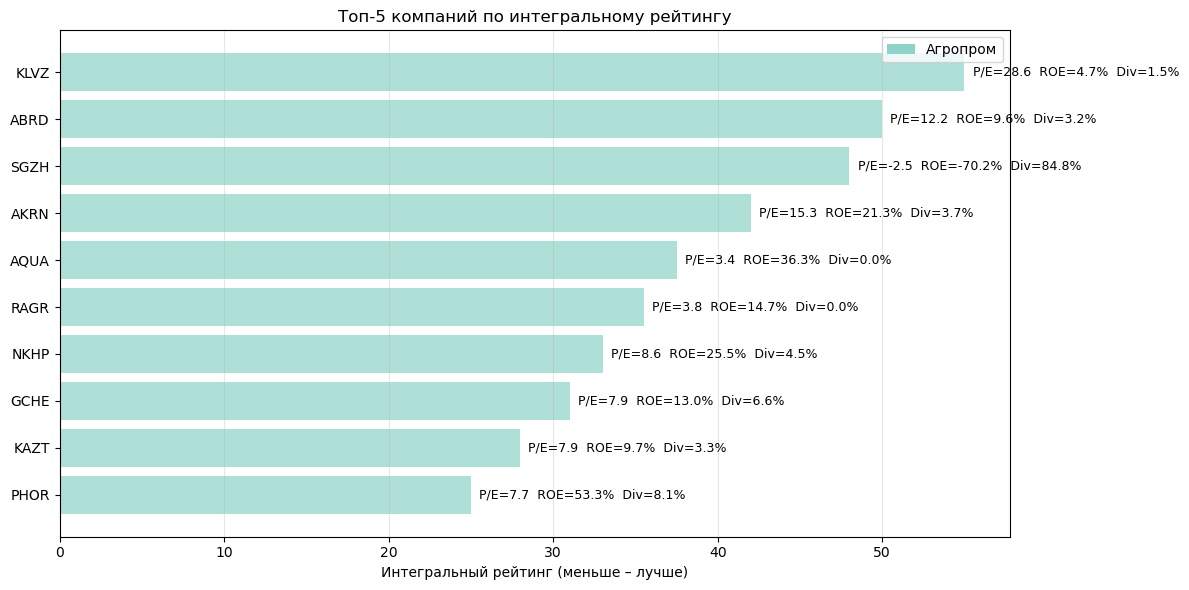

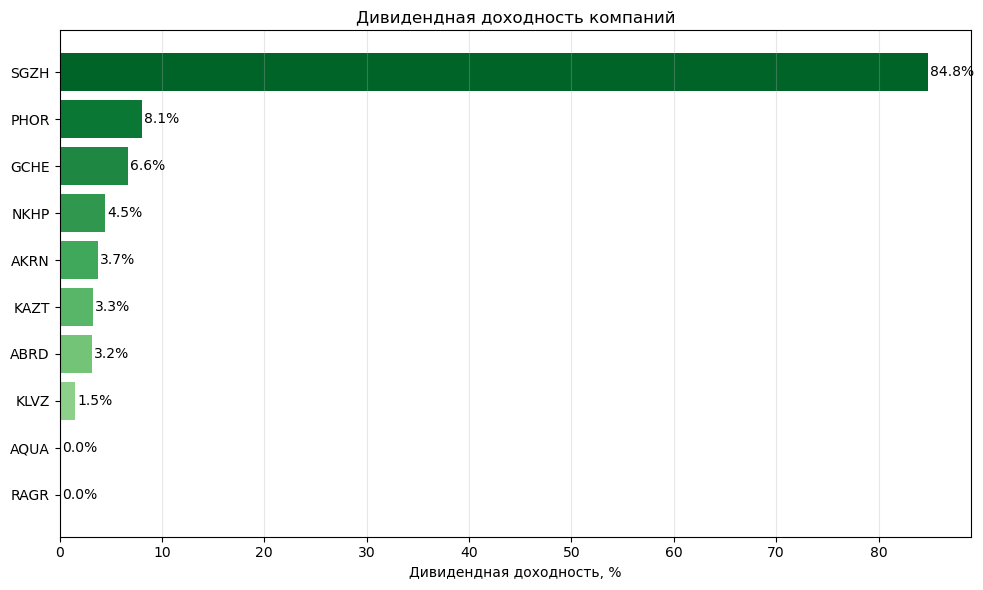


✅ Таблица топ-5 компаний сохранена: C:/Users/1/Documents/TRADE_2026/ScriptsAnalizTorgy/Analitika/top5_investment_130326_1836.csv


In [13]:
# =============================================================================
# ЭТАП 8. КОМПАНИИ ДЛЯ ИНВЕСТИРОВАНИЯ И ПОЛНАЯ ТАБЛИЦА ПОКАЗАТЕЛЕЙ
# =============================================================================

# Словарь с описанием параметров (краткое и полное описание + критерии)
parameter_descriptions = {
    'MarketCap': {
        'short': 'Капитализация',
        'full': 'Рыночная капитализация (млрд руб) – рыночная стоимость компании. Крупные компании обычно стабильнее.',
        'comment': ''
    },
    'EV': {
        'short': 'EV',
        'full': 'Стоимость предприятия = MarketCap + NetDebt (млрд руб). Полная стоимость бизнеса.',
        'comment': 'Отрицательный EV — это математическое следствие формулы, когда денежные средства превышают сумму долга и капитализации. Это указывает на уникальную ситуацию «денежного мешка», но для стандартного инвестиционного анализа такие компании обычно рассматриваются отдельно, поскольку стандартные мультипликаторы к ним неприменимы.'
    },
    'Equity': {
        'short': 'Собственный капитал',
        'full': 'Собственный капитал (млрд руб) – активы минус обязательства.',
        'comment': ''
    },
    'Revenue': {
        'short': 'Выручка',
        'full': 'Выручка компании (млрд руб) – отражает масштаб бизнеса. Чем выше, тем крупнее компания.',
        'comment': ''
    },
    'EBITDA': {
        'short': 'EBITDA',
        'full': 'Прибыль до вычета процентов, налогов и амортизации (млрд руб) – показатель операционной эффективности.',
        'comment': 'EBITDA margin (рентабельность по EBITDA)\nПоказывает, сколько операционной прибыли до вычета процентов, налогов и амортизации остаётся с каждого рубля выручки.\nПростыми словами: сколько денег зарабатывает компания от своей основной деятельности.\nНорма: >20% — отлично, 10–20% — средне, <10% — низкая операционная эффективность.'
    },
    'NetIncome': {
        'short': 'Чистая прибыль',
        'full': 'Чистая прибыль (млрд руб) – конечный финансовый результат. Стабильный рост – признак здорового бизнеса.',
        'comment': ''
    },
    'FCF': {
        'short': 'Свободный денежный поток',
        'full': 'Свободный денежный поток (млрд руб) – деньги, доступные после инвестиций. Положительный – хорошо.',
        'comment': ''
    },
    'Debt': {
        'short': 'Долг',
        'full': 'Совокупный долг (млрд руб) – общая сумма обязательств.',
        'comment': ''
    },
    'Cash': {
        'short': 'Денежные средства',
        'full': 'Денежные средства и эквиваленты (млрд руб) – ликвидность компании.',
        'comment': ''
    },
    'NetDebt': {
        'short': 'Чистый долг',
        'full': 'Чистый долг = Долг − Денежные средства (млрд руб). Отрицательный – чистая денежная позиция.',
        'comment': ''
    },
    'Dividend': {
        'short': 'Дивиденд на акцию',
        'full': 'Дивиденд на одну акцию (руб) – выплаты акционерам.',
        'comment': ''
    },
    'DivYield': {
        'short': 'Див. доходность',
        'full': 'Дивидендная доходность = Dividend / Price × 100 (%). >8% – высокая, 5-8% – средняя, <5% – низкая.',
        'comment': ''
    },
    'FreeFloat': {
        'short': 'Free Float',
        'full': 'Доля акций в свободном обращении (%). Высокий (>40%) – хорошая ликвидность.',
        'comment': ''
    },
    'ROE_raw': {
        'short': 'ROE (исходный)',
        'full': 'Исходная рентабельность собственного капитала (%). Высокий ROE (>15%) – эффективное использование капитала.\n>15% – отлично, 10-15% – хорошо, 5-10% – средне, <5% – низко.',
        'comment': 'ROE (Return on Equity — рентабельность собственного капитала)\nПоказывает, сколько чистой прибыли приносит каждый рубль, вложенный акционерами.\nПростыми словами: насколько хорошо менеджмент распоряжается деньгами владельцев компании.\nНорма: >15% считается хорошо, >20% — отлично. Но важно сравнивать внутри одного сектора.'
    },
    'ROE': {
        'short': 'ROE',
        'full': 'Рентабельность собственного капитала (%). >15% – отлично, 10-15% – хорошо, 5-10% – средне, <5% – низко.',
        'comment': ''
    },
    'ROA_raw': {
        'short': 'ROA (исходный)',
        'full': 'Исходная рентабельность активов (%). Показывает, насколько эффективно используются активы.',
        'comment': 'ROA (Return on Assets — рентабельность активов)\nОтражает, сколько прибыли генерирует каждый рубль всех активов компании (и своих, и заёмных).\nПростыми словами: насколько эффективно компания использует свои заводы, оборудование, деньги.\nНорма: зависит от капиталоёмкости отрасли. Для металлургии 5–8% нормально, для IT может быть 15–20%.'
    },
    'PE_raw': {
        'short': 'P/E (исходный)',
        'full': 'Исходный коэффициент цена/прибыль. Низкий P/E (<10) – возможная недооценка, 10-20 – справедливо, (>20) – переоценка (ожидания роста).',
        'comment': 'P/E (Price to Earnings – Цена / Прибыль)\nПоказывает, за сколько лет окупится покупка акции при текущей прибыли.\nПример: P/E = 10 означает, что инвестор «отобьёт» свои вложения за 10 лет (если прибыль останется такой же). Низкий P/E (< 10) – потенциально недооценённая акция.\nВысокий P/E (> 20) – либо компания быстро растёт (и инвесторы верят в будущее), либо акция переоценена.'
    },
    'P/E': {
        'short': 'P/E',
        'full': 'Коэффициент цена/прибыль. <10 – недооценка, 10-20 – справедливо, >20 – переоценка.',
        'comment': ''
    },
    'PB_raw': {
        'short': 'P/B (исходный)',
        'full': 'Исходный коэффициент цена/балансовая стоимость. P/B < 1 – акции дешевле балансовой стоимости.',
        'comment': 'P/B (Price to Book – Цена / Балансовая стоимость)\nСравнивает рыночную цену компании с её «книжной» стоимостью (сколько стоит имущество компании минус долги).\nP/B < 1 – компания торгуется дешевле стоимости своих чистых активов. Это может быть признаком недооценки, но иногда отражает реальные проблемы.\nP/B > 3 – высокая оценка, обычно у компаний с нематериальными активами (бренды, технологии).'
    },
    'P/B': {
        'short': 'P/B',
        'full': 'Коэффициент цена/балансовая стоимость. <1 – недооценка, 1-3 – справедливо, >3 – переоценка.',
        'comment': ''
    },
    'EVEBITDA_raw': {
        'short': 'EV/EBITDA (исходный)',
        'full': 'Исходный коэффициент стоимость предприятия/EBITDA. <5 – недооценка, 5-10 – справедливо, >10 – переоценка.',
        'comment': 'EV/EBITDA (Стоимость компании / Операционная прибыль)\nПоказывает, за сколько лет окупится покупка всего бизнеса (вместе с долгами) за счёт операционной прибыли.\nНизкое значение (< 5) – может говорить о недооценке.\nВысокое значение (> 10) – дорого, но может оправдываться ростом.'
    },
    'EV/EBITDA': {
        'short': 'EV/EBITDA',
        'full': 'Отношение стоимости предприятия к EBITDA. <5 – недооценка, 5-10 – справедливо, >10 – переоценка.',
        'comment': ''
    },
    'PS_raw': {
        'short': 'P/S (исходный)',
        'full': 'Исходный коэффициент цена/выручка. <1 – возможная недооценка, 1-3 – справедливо, >3 – переоценка.',
        'comment': 'P/S (Price to Sales – Цена / Выручка)\nОтношение капитализации к выручке. Полезен для убыточных компаний, где P/E не работает.\nP/S < 1 – компания оценивается ниже своей годовой выручки (часто бывает у ритейла).\nP/S > 3 – дорого, характерно для быстрорастущих или высокомаржинальных компаний.'
    },
    'P/S': {
        'short': 'P/S',
        'full': 'Коэффициент цена/выручка. <1 – недооценка, 1-3 – справедливо, >3 – переоценка.',
        'comment': ''
    },
    'DebtEBITDA_raw': {
        'short': 'Долг/EBITDA (исходный)',
        'full': 'Исходное отношение долга к EBITDA. <1,5 – низкая нагрузка, 1,5-3 – умеренная, >3 – высокая.',
        'comment': 'NetDebt/EBITDA – чистый долг относительно годовой операционной прибыли. Показывает, за сколько лет компания расплатится с долгами, если всю прибыль направит на погашение.\n\nКомпании с NetDebt/EBITDA > 4 и Interest Coverage < 2 одновременно – высокий риск дефолта.'
    },
    'NetDebt/EBITDA': {
        'short': 'Чистый долг/EBITDA',
        'full': 'Отношение чистого долга к EBITDA. <1,5 – низкая нагрузка, 1,5-3 – умеренная, >3 – высокая.',
        'comment': ''
    },
    'Debt/Equity': {
        'short': 'Долг/Капитал',
        'full': 'Отношение долга к собственному капиталу. <0,5 – консервативно, 0,5-1,5 – умеренно, >1,5 – агрессивно.',
        'comment': 'Debt/Equity – отношение заёмного капитала к собственному. Отражает, насколько компания финансируется за счёт долгов (финансовый рычаг).\n\nЧего избегать:\nКомпании с Debt/Equity > 3 – слишком много долга относительно собственных средств.'
    },
    'InterestCoverage': {
        'short': 'Покрытие процентов',
        'full': 'Коэффициент покрытия процентов = EBITDA / Interest. >3 – безопасно, 1,5-3 – удовлетворительно, <1,5 – риск.',
        'comment': 'Interest Coverage (EBITDA / Interest) – покрытие процентных расходов операционной прибылью. Сколько раз прибыль перекрывает проценты.\n\nКомпании с NetDebt/EBITDA > 4 и Interest Coverage < 2 одновременно – высокий риск дефолта.'
    },
    'OER': {
        'short': 'Доля операц. расходов',
        'full': 'Доля операционных расходов в выручке = OperExpenses / Revenue. Низкое значение – эффективность.',
        'comment': 'OER (Operating Expense Ratio) – отношение операционных расходов к выручке. Показывает, какая часть выручки уходит на покрытие текущих операционных затрат (зарплаты, аренда, маркетинг и т.д.). Чем ниже OER, тем эффективнее компания контролирует расходы.'
    },
    'AssetTurnover': {
        'short': 'Оборачиваемость активов',
        'full': 'Оборачиваемость активов = Revenue / Assets. >1 – эффективно.',
        'comment': 'Asset Turnover (Оборачиваемость активов) – отношение выручки к активам. Показывает, сколько рублей выручки приносит каждый рубль, вложенный в активы. Чем выше Asset Turnover, тем эффективнее используются активы (заводы, оборудование, деньги).'
    },
    'Turnover': {
        'short': 'Оборот',
        'full': 'Оборот торгов за день (руб). Показатель ликвидности. Чем выше, тем ликвиднее.',
        'comment': ''
    },
    'BidOrders': {
        'short': 'Заявки на покупку',
        'full': 'Количество заявок на покупку. Показатель спроса.',
        'comment': ''
    },
    'AskOrders': {
        'short': 'Заявки на продажу',
        'full': 'Количество заявок на продажу. Показатель предложения.',
        'comment': ''
    },
    'Shares': {
        'short': 'Акции в обращении',
        'full': 'Количество акций в обращении (млн шт) – используется для расчётов мультипликаторов.',
        'comment': ''
    },
    'Price': {
        'short': 'Цена акции',
        'full': 'Цена одной акции (руб) – текущая рыночная цена.',
        'comment': ''
    },
    'EPS': {
        'short': 'Прибыль на акцию',
        'full': 'Прибыль на акцию (руб) – NetIncome / Shares.',
        'comment': ''
    },
    'CAPEX': {
        'short': 'Капитальные затраты',
        'full': 'Капитальные затраты (млрд руб) – инвестиции в основные средства.',
        'comment': ''
    },
    'BVPS': {
        'short': 'Балансовая стоимость на акцию',
        'full': 'Балансовая стоимость на акцию (руб) – Equity / Shares.',
        'comment': ''
    },
    'Assets': {
        'short': 'Активы',
        'full': 'Совокупные активы (млрд руб) – всё, чем владеет компания.',
        'comment': ''
    },
    'Interest': {
        'short': 'Процентные расходы',
        'full': 'Процентные расходы (млрд руб) – стоимость обслуживания долга.',
        'comment': ''
    },
    'OperExpenses': {
        'short': 'Операционные расходы',
        'full': 'Операционные расходы (млрд руб) – затраты на основную деятельность.',
        'comment': ''
    },
    'OperatingProfit': {
        'short': 'Операционная прибыль',
        'full': 'Операционная прибыль (млрд руб) – прибыль от основной деятельности.',
        'comment': ''
    },
    'AnnualReport': {
        'short': 'Годовой отчёт',
        'full': 'Наличие годового отчёта (бинарный или рейтинг). Наличие – признак прозрачности.',
        'comment': ''
    },
    'IR_rating': {
        'short': 'IR рейтинг',
        'full': 'Рейтинг взаимодействия с инвесторами (1–5). 5 – отлично.',
        'comment': ''
    },
    'ReportQuality': {
        'short': 'Качество отчётности',
        'full': 'Качество финансовой отчётности (1–5). Высокий – доверие к данным.',
        'comment': ''
    },
    'Presentations': {
        'short': 'Презентации',
        'full': 'Наличие презентаций для инвесторов (1–5). Показатель открытости.',
        'comment': ''
    },
    'SmartlabPresence': {
        'short': 'Присутствие на Smart-lab',
        'full': 'Присутствие компании на Smart-lab (1–5). Вовлечённость в коммуникацию.',
        'comment': ''
    },
    'InvestorSite': {
        'short': 'Сайт для инвесторов',
        'full': 'Наличие сайта для инвесторов (1–5). Удобство доступа к информации.',
        'comment': ''
    },
    'InvestorCalendar': {
        'short': 'Календарь инвестора',
        'full': 'Наличие календаря инвестора (1–5). Информирование о событиях.',
        'comment': ''
    },
    'Feedback': {
        'short': 'Обратная связь',
        'full': 'Наличие обратной связи с инвесторами (1–5). Доступность IR-службы.',
        'comment': ''
    },
    'Sector': {
        'short': 'Сектор',
        'full': 'Сектор экономики (категория). Сравнение компаний внутри одного сектора.',
        'comment': ''
    },
    'DPR': {
        'short': 'Коэф. выплат',
        'full': 'Коэффициент дивидендных выплат = Dividend × Shares / NetIncome. 0,3-0,7 – устойчиво, >0,7 – риск сокращения.',
        'comment': ''
    },
    'Rank_P/E': {
        'short': 'Ранг P/E',
        'full': 'Ранг по P/E (меньше – лучше). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_P/B': {
        'short': 'Ранг P/B',
        'full': 'Ранг по P/B (меньше – лучше). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_EV/EBITDA': {
        'short': 'Ранг EV/EBITDA',
        'full': 'Ранг по EV/EBITDA (меньше – лучше). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_NetDebt/EBITDA': {
        'short': 'Ранг долг/EBITDA',
        'full': 'Ранг по NetDebt/EBITDA (меньше – лучше). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_ROE': {
        'short': 'Ранг ROE',
        'full': 'Ранг по ROE (больше – лучше, инвертирован). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_DivYield': {
        'short': 'Ранг див. доходности',
        'full': 'Ранг по дивидендной доходности (больше – лучше, инвертирован). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Rank_FCF': {
        'short': 'Ранг FCF',
        'full': 'Ранг по свободному денежному потоку (больше – лучше, инвертирован). Используется для интегрального рейтинга.',
        'comment': ''
    },
    'Composite_Rank': {
        'short': 'Интегральный рейтинг',
        'full': 'Интегральный рейтинг = сумма рангов (меньше – лучше). Чем меньше, тем привлекательнее компания.',
        'comment': ''
    }
}

# Порядок параметров строго как в примере
param_order = [
    'MarketCap', 'EV', 'Equity', 'Revenue', 'EBITDA', 'NetIncome', 'FCF', 'Debt', 'Cash', 'NetDebt',
    'Dividend', 'DivYield', 'FreeFloat', 'ROE_raw', 'ROE', 'ROA_raw', 'PE_raw', 'P/E', 'PB_raw', 'P/B',
    'EVEBITDA_raw', 'EV/EBITDA', 'PS_raw', 'P/S', 'DebtEBITDA_raw', 'NetDebt/EBITDA', 'Debt/Equity',
    'InterestCoverage', 'OER', 'AssetTurnover', 'Turnover', 'BidOrders', 'AskOrders', 'Shares', 'Price',
    'EPS', 'CAPEX', 'BVPS', 'Assets', 'Interest', 'OperExpenses', 'OperatingProfit', 'AnnualReport',
    'IR_rating', 'ReportQuality', 'Presentations', 'SmartlabPresence', 'InvestorSite', 'InvestorCalendar',
    'Feedback', 'Sector', 'DPR', 'Rank_P/E', 'Rank_P/B', 'Rank_EV/EBITDA', 'Rank_NetDebt/EBITDA',
    'Rank_ROE', 'Rank_DivYield', 'Rank_FCF', 'Composite_Rank'
]

if 'Composite_Rank' in df_screen.columns:
    # --- ПОЛНАЯ ТАБЛИЦА ВСЕХ ПОКАЗАТЕЛЕЙ ДЛЯ ОТОБРАННЫХ КОМПАНИЙ ---
    # Возьмём df_fund для тикеров, присутствующих в df_screen (после фильтрации)
    full_data = df_fund.loc[df_screen.index].copy()
    
    # Добавим ранги и составной рейтинг из df_screen
    rank_cols = [col for col in df_screen.columns if col.startswith('Rank_') or col == 'Composite_Rank']
    for col in rank_cols:
        if col in df_screen.columns:
            full_data[col] = df_screen[col]
    
    # Подготовим список строк для итогового файла
    rows = []
    
    # Строка 1: заголовки параметров
    header_row = ['Параметр'] + param_order
    rows.append(header_row)
    
    # Строка 2: краткие описания
    short_row = ['Краткое описание'] + [parameter_descriptions.get(p, {}).get('short', '') for p in param_order]
    rows.append(short_row)
    
    # Строки данных по компаниям
    for ticker in full_data.index:
        data_row = [ticker]
        for p in param_order:
            val = full_data.loc[ticker, p] if p in full_data.columns else ''
            # Добавляем префикс для чисел, чтобы Excel не превращал в даты
            if isinstance(val, (int, float)) and not pd.isna(val):
                # Для очень маленьких чисел можно оставить как есть, но добавим префикс
                data_row.append(f"'{val}")
            elif pd.isna(val):
                data_row.append('')
            else:
                # Для строк (например, сектор) просто строку, но очистим от нечитаемых символов
                if p == 'Sector' and isinstance(val, str):
                    val = val.encode('ascii', 'ignore').decode('ascii')
                data_row.append(val)
        rows.append(data_row)
    
    # Строка с полными описаниями (после данных компаний)
    full_desc_row = ['Полное описание и критерии'] + [parameter_descriptions.get(p, {}).get('full', '') for p in param_order]
    rows.append(full_desc_row)
    
    # Строка с комментариями
    comment_row = ['Комментарии'] + [parameter_descriptions.get(p, {}).get('comment', '') for p in param_order]
    rows.append(comment_row)
    
    # Создаём DataFrame для экспорта (просто для удобства, можно сразу записать rows)
    # Но проще записать rows в CSV через pandas или csv.writer
    import csv
    
    timestamp = datetime.now().strftime('%d%m%y_%H%M')
    filename = f'screening_full_with_descriptions_{timestamp}.csv'
    full_path = os.path.join(output_path, filename)
    
    with open(full_path, 'w', encoding='utf-8-sig', newline='') as f:
        writer = csv.writer(f, delimiter=';')
        writer.writerows(rows)
    
    print(f"\n✅ Полная таблица с описаниями параметров сохранена: {full_path}")
    print(f"Всего параметров: {len(param_order)}")
    print(f"Всего компаний: {len(full_data.index)}")
    print("Структура файла: первые две строки - заголовки и краткие описания, затем данные компаний, затем полные описания и комментарии.")

    # --- ТОП-5 КОМПАНИЙ ПО ИНТЕГРАЛЬНОМУ РЕЙТИНГУ (оставляем без изменений) ---
    # Отбираем топ-5 (наименьший рейтинг)
    top5 = df_screen.nsmallest(MAX_TICKERS-MIN_TICKERS, 'Composite_Rank')
    top5_sorted = top5.sort_values('Composite_Rank', ascending=True)
    
    print("\n" + "="*80)
    print("РАНЖИРОВАННЫЕ КОМПАНИИ ДЛЯ ИНВЕСТИРОВАНИЯ НА ОСНОВЕ РЕЙТИНГА")
    print("="*80)
    
    display_cols = ['Sector', 'P/E', 'ROE', 'DivYield', 'NetDebt/EBITDA', 'Composite_Rank']
    existing_display = [col for col in display_cols if col in top5_sorted.columns]
    print(top5_sorted[existing_display].to_string())
    
    # Визуализация: горизонтальная столбчатая диаграмма
    plt.figure(figsize=(12, 6))
    sectors = top5_sorted['Sector'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(sectors)))
    sector_color = {s: colors[i] for i, s in enumerate(sectors)}
    bar_colors = [sector_color[s] for s in top5_sorted['Sector']]
    
    y_pos = np.arange(len(top5_sorted))
    bars = plt.barh(y_pos, top5_sorted['Composite_Rank'].values, color=bar_colors, alpha=0.7)
    
    plt.yticks(y_pos, top5_sorted.index)
    plt.xlabel('Интегральный рейтинг (меньше – лучше)')
    plt.title('Топ-5 компаний по интегральному рейтингу')
    
    for i, (idx, row) in enumerate(top5_sorted.iterrows()):
        label = f"P/E={row.get('P/E', 'N/A'):.1f}  ROE={row.get('ROE', 'N/A'):.1f}%  Div={row.get('DivYield', 'N/A'):.1f}%"
        plt.text(row['Composite_Rank'] + 0.5, i, label, va='center', fontsize=9)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=sector_color[s], label=s) for s in sectors]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Визуализация дивидендной доходности компаний (если есть)
    if 'DivYield' in top5_sorted.columns:
        plt.figure(figsize=(10, 6))
        top5_div = top5_sorted.sort_values('DivYield', ascending=True)
        colors_div = plt.cm.Greens(np.linspace(0.3, 0.9, len(top5_div)))
        bars = plt.barh(range(len(top5_div)), top5_div['DivYield'].values, color=colors_div)
        plt.yticks(range(len(top5_div)), top5_div.index)
        plt.xlabel('Дивидендная доходность, %')
        plt.title('Дивидендная доходность компаний')
        for i, (bar, val) in enumerate(zip(bars, top5_div['DivYield'])):
            plt.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=10)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Экспорт топ-5 в CSV (с исправлением формата)
    export_cols = ['Sector', 'P/E', 'ROE', 'DivYield', 'NetDebt/EBITDA', 'Composite_Rank']
    export_cols = [col for col in export_cols if col in top5_sorted.columns]
    top5_export = top5_sorted[export_cols].copy()
    top5_export.insert(0, 'Ticker', top5_sorted.index)
    
    # Исправляем формат чисел для Excel
    for col in top5_export.select_dtypes(include=['float64', 'int64']).columns:
        top5_export[col] = top5_export[col].apply(lambda x: f"'{x}" if pd.notna(x) else x)
    
    # Исправляем Sector
    if 'Sector' in top5_export.columns:
        top5_export['Sector'] = top5_export['Sector'].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii') if pd.notna(x) else x)
    
    filename = f'top5_investment_{timestamp}.csv'
    full_path = os.path.join(output_path, filename)
    top5_export.to_csv(full_path, index=False, sep=';', encoding='utf-8-sig', float_format='%.2f')
    print(f"\n✅ Таблица топ-5 компаний сохранена: {full_path}")

else:
    print("Недостаточно данных для формирования топ-5 и полной таблицы.")

# Этап 8. Компании для инвестирования

На этом заключительном этапе мы собираем воедино результаты всех предыдущих расчётов и выбираем **пять наиболее привлекательных компаний** с точки зрения фундаментального анализа. Это не просто случайная пятёрка, а результат объективной числовой оценки, которая помогает отсеять лишнее и сфокусироваться на лучших кандидатах.

## Как работает отбор?

В этапе 7 мы создали **интегральный рейтинг** (колонка `Composite_Rank`) для каждой компании. Этот рейтинг считается так:

- По каждому финансовому показателю (например, `P/E`, `ROE`, `Дивидендная доходность`, `NetDebt/EBITDA`) компания получает **ранг** – место в общем списке.
- Для показателей, где **меньше – лучше** (P/E, долг), ранг считается обычным образом (самое маленькое значение получает ранг 1).
- Для показателей, где **больше – лучше** (ROE, дивиденды), ранг считается **в обратном порядке** (самое большое значение получает ранг 1).
- Затем все ранги **суммируются**. Чем меньше получившаяся сумма, тем лучше компания сбалансирована по всем метрикам.

Таким образом, **наименьший `Composite_Rank`** означает, что компания находится в верхней части списка сразу по нескольким важным критериям.

## Что мы видим на выходе?

Блок формирует две вещи:

### 1. Таблица с характеристиками

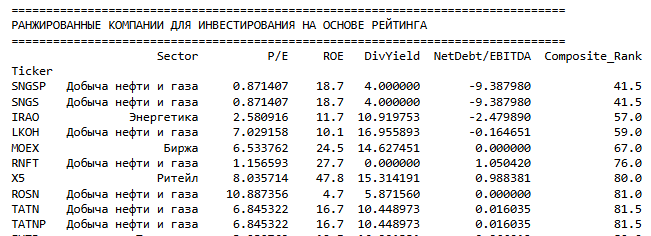

В таблице вы видите:
- **Тикер** – краткое обозначение компании на бирже.
- **Сектор** – отрасль, к которой относится компания (полезно для диверсификации).
- **P/E** – цена к прибыли (чем ниже, тем дешевле компания).
- **ROE** – рентабельность собственного капитала (чем выше, тем эффективнее менеджмент).
- **DivYield** – дивидендная доходность (процент от цены акции).
- **NetDebt/EBITDA** – долговая нагрузка (меньше 2 – хорошо).
- **Composite_Rank** – итоговый рейтинг (меньше – лучше).

### 2. График – горизонтальная полосатая диаграмма

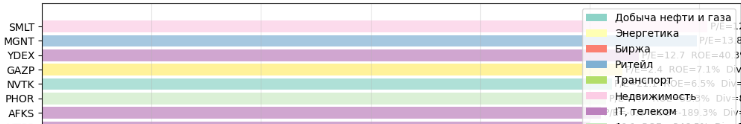

*Цвет полосы соответствует сектору. Длина полосы – значение интегрального рейтинга. Справа от полосы подписаны ключевые метрики.*

График наглядно показывает:
- Какая компания лидирует (самая короткая полоска).
- В каких секторах оказались лидеры.
- Как соотносятся показатели у разных компаний (например, у одной может быть низкий P/E, но и дивиденды ниже).

## Для чего это нужно?

Интегральный рейтинг – это **сито первичного отбора**. Вместо того чтобы вручную просматривать десятки компаний и сравнивать кучу цифр, вы получаете короткий список из пяти кандидатов, которые уже прошли автоматическую проверку по нескольким критериям.

**Но важно помнить:** рейтинг основан только на количественных данных из отчётности и не учитывает:
- макроэкономическую ситуацию;
- отраслевые риски;
- новости и корпоративные события;
- качество управления (прокси‑метрики из этапа 6 могут частично это补偿, но не полностью).

Поэтому топ‑5 – это **отправная точка для углублённого исследования**. Теперь можно:
- открыть годовой отчёт каждой компании;
- почитать последние новости;
- оценить перспективы роста рынка;
- принять взвешенное инвестиционное решение.

## Что сохраняется на диск?

В папке `Analitika` появляется файл  
`top5_investment_ДДММГГ_ЧЧММ.csv`  
с теми же данными, что и в таблице выше. Его можно открыть в Excel и использовать для дальнейшего анализа или отслеживания.

In [14]:
sys.exit("⏹️ Выполнение остановлено по вашему желанию.")

SystemExit: ⏹️ Выполнение остановлено по вашему желанию.

<div class="alert alert-info">
  <strong>Информация!</strong> Здесь размещается текст для пользователя.
</div>

<!-- Зелёный (успех) -->
<div class="alert alert-success">
  <strong>Успех!</strong> Операция выполнена успешно.
</div>

<!-- Жёлтый (предупреждение) -->
<div class="alert alert-warning">
  <strong>Внимание!</strong> Возможны проблемы или изменения.
</div>

<!-- Красный (опасность/ошибка) -->
<div class="alert alert-danger">
  <strong>Ошибка!</strong> Что-то пошло не так.
</div>

<div style="background-color: #d4edda; border-color: #c3e6cb; color: #155724; padding: 10px; border-radius: 5px;">
  Зелёный блок с inline-стилями.
</div>

<div class="alert alert-info">
</div>

**Этот код запускать можно раз в полгода***

In [ ]:
# Парсер данных МСФО со smart-lab.ru
# Запускается отдельно для обновления локальной базы данных.

# --- ЗАГРУЗКА ТИКЕРОВ ИЗ ФАЙЛА Torgi ---
try:
    torgi_df = pd.read_excel(TORGI_FILE, sheet_name=SHEET_NAME, engine='openpyxl', header=0)
    print(f"Файл {TORGI_FILE} загружен, строк: {len(torgi_df)}")
except Exception as e:
    print(f"Ошибка загрузки файла: {e}")
    raise

# Берём все тикеры (без фильтрации)
original_tickers = torgi_df['Код инструмента'].dropna().astype(str).str.strip().tolist()
print(f"Всего тикеров для загрузки: {len(original_tickers)}")

# ===================== ЗАГРУЗКА FREE FLOAT С МОСБИРЖИ =====================
try:
    print(f"Читаем данные free float из локального файла: {MOEX_FILE}")
    if not os.path.exists(MOEX_FILE):
        raise FileNotFoundError(f"Файл {MOEX_FILE} не найден. Скачайте его вручную с https://www.moex.com/ru/listing/free-float.aspx")
    
    moex_df = pd.read_excel(MOEX_FILE, header=0, engine='xlrd')
    # Определяем колонки с тикером и free float
    if 'SECID' in moex_df.columns and 'FREE FLOAT' in moex_df.columns:
        moex_ff = moex_df[['SECID', 'FREE FLOAT']].copy()
        moex_ff.rename(columns={'SECID': 'Ticker', 'FREE FLOAT': 'FreeFloat_MOEX'}, inplace=True)
    elif 'Код инструмента' in moex_df.columns and 'Коэффициент free-float' in moex_df.columns:
        moex_ff = moex_df[['Код инструмента', 'Коэффициент free-float']].copy()
        moex_ff.rename(columns={'Код инструмента': 'Ticker', 'Коэффициент free-float': 'FreeFloat_MOEX'}, inplace=True)
    else:
        ticker_col = None
        ff_col = None
        for col in moex_df.columns:
            if 'secid' in col.lower() or 'код' in col.lower() or 'ticker' in col.lower():
                ticker_col = col
            if 'free' in col.lower() and 'float' in col.lower():
                ff_col = col
        if ticker_col and ff_col:
            moex_ff = moex_df[[ticker_col, ff_col]].copy()
            moex_ff.rename(columns={ticker_col: 'Ticker', ff_col: 'FreeFloat_MOEX'}, inplace=True)
        else:
            raise ValueError("Не удалось определить колонки с тикером и free float в файле.")
    
    moex_ff['Ticker'] = moex_ff['Ticker'].astype(str).str.strip()
    moex_ff.set_index('Ticker', inplace=True)
    moex_ff['FreeFloat_MOEX'] = pd.to_numeric(moex_ff['FreeFloat_MOEX'], errors='coerce')
    moex_ff = moex_ff[~moex_ff.index.duplicated(keep='first')]
    print(f"Загружено {len(moex_ff)} записей free float из локального файла.")
except Exception as e:
    print(f"Ошибка загрузки free float из локального файла: {e}")
    moex_ff = pd.DataFrame()

# ===================== ЗАГРУЗКА СЕКТОРОВ =====================
sector_mapping = {}
try:
    sector_df = pd.read_excel(SECTOR_FILE, sheet_name='Sector', engine='openpyxl', header=0)
    sector_df = sector_df[['Код инструмента', 'Категории']].copy()
    sector_df.dropna(inplace=True)
    sector_df['Код инструмента'] = sector_df['Код инструмента'].astype(str).str.strip()
    sector_df = sector_df.drop_duplicates(subset=['Код инструмента'])
    sector_mapping = dict(zip(sector_df['Код инструмента'], sector_df['Категории']))
    print(f"Загружено {len(sector_mapping)} записей о секторах.")
except Exception as e:
    print(f"Ошибка загрузки секторов: {e}")

def get_sector(ticker):
    ticker_clean = str(ticker).strip()
    return sector_mapping.get(ticker_clean, 'Другое')

# ===================== ФУНКЦИИ ДЛЯ ПАРСИНГА =====================
BASE_URL = 'https://smart-lab.ru/q/{}/f/y/'

def clean_number_string(s):
    if isinstance(s, str):
        s = s.replace(' ', '').replace('\xa0', '').replace(',', '.')
        s = s.replace('−', '-').replace('?', '').replace('%', '')
        if s in ('', '-', '—'):
            return np.nan
        try:
            return float(s)
        except ValueError:
            return s
    return s

def fetch_table(ticker):
    url = BASE_URL.format(ticker)
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    try:
        response = requests.get(url, timeout=10, headers=headers)
        response.encoding = 'utf-8'
        if response.status_code != 200:
            print(f"  Статус {response.status_code}")
            return None
        html = response.text.replace('&nbsp;', ' ')
        tables = pd.read_html(StringIO(html), header=0, flavor='lxml')
        for table in tables:
            if table.shape[0] > 5 and table.shape[1] > 2:
                first_col = table.iloc[:, 0].astype(str).str.lower()
                keywords = ['выручка', 'ebitda', 'чистая прибыль', 'капитализация']
                if any(first_col.str.contains(kw).any() for kw in keywords):
                    table = table.dropna(subset=[table.columns[0]])
                    table.rename(columns={table.columns[0]: 'Indicator'}, inplace=True)
                    return table
        if tables:
            table = tables[0]
            table = table.dropna(subset=[table.columns[0]])
            table.rename(columns={table.columns[0]: 'Indicator'}, inplace=True)
            return table
        return None
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None

def extract_last_value(row):
    values = row.iloc[1:].dropna()
    if len(values) == 0:
        return np.nan
    ltm_cols = [col for col in row.index if 'LTM' in str(col).upper()]
    if ltm_cols:
        ltm_val = row[ltm_cols[0]]
        if pd.notna(ltm_val) and str(ltm_val).strip() not in ('', '?', '-', '—'):
            return ltm_val
    return values.iloc[-1]

# ===================== РАСШИРЕННЫЙ СЛОВАРЬ МАППИНГА =====================
indicator_mapping = {
    r'(?i)выручка.*млрд': 'Revenue',
    r'(?i)ebitda.*млрд': 'EBITDA',
    r'(?i)чистая прибыль.*млрд': 'NetIncome',
    r'(?i)капитализация.*млрд': 'MarketCap',
    r'(?i)цена акции ао.*руб': 'Price',
    r'(?i)число акций ао.*млн': 'Shares',
    r'(?i)чистый долг.*млрд': 'NetDebt',
    r'(?i)долг.*млрд': 'Debt',
    r'(?i)наличность.*млрд': 'Cash',
    r'(?i)дивиденд.*руб/акцию': 'Dividend',
    r'(?i)fcf.*млрд': 'FCF',
    r'(?i)capex.*млрд': 'CAPEX',
    r'(?i)операционный денежный поток.*млрд': 'OperatingCF',
    r'(?i)eps.*руб': 'EPS',
    r'(?i)bv/акцию.*руб': 'BVPS',
    r'(?i)активы.*млрд': 'Assets',
    r'(?i)активы банка.*млрд': 'Assets',
    r'(?i)капитал.*млрд': 'Equity',
    r'(?i)чистые активы.*млрд': 'Equity',
    r'(?i)roe.*%': 'ROE_raw',
    r'(?i)roa.*%': 'ROA_raw',
    r'(?i)p/e': 'PE_raw',
    r'(?i)p/b': 'PB_raw',
    r'(?i)ev/ebitda': 'EVEBITDA_raw',
    r'(?i)p/s': 'PS_raw',
    r'(?i)долг/ebitda': 'DebtEBITDA_raw',
    r'(?i)free float': 'FreeFloat',
    r'(?i)Процентные расходы, млрд руб': 'Interest',
    r'(?i)Опер. расходы, млрд руб': 'OperExpenses',
    r'(?i)Операционная прибыль, млрд руб': 'OperatingProfit',
    r'(?i)IR рейтинг': 'IR_rating',
    r'(?i)Качество фин\.?отчетности': 'ReportQuality',
    r'(?i)Презентации для инвесторов': 'Presentations',
    r'(?i)Присутствие на смартлабе': 'SmartlabPresence',
    r'(?i)Годовой отчет': 'AnnualReport',
    r'(?i)Сайт для инвесторов': 'InvestorSite',
    r'(?i)Календарь инвесторов': 'InvestorCalendar',
    r'(?i)Обратная связь': 'Feedback'
}

# ===================== ОСНОВНОЙ ЦИКЛ =====================
data_rows = []
failed_tickers = []

for i, orig_ticker in enumerate(original_tickers):
    print(f"Обработка {i+1}/{len(original_tickers)}: {orig_ticker}")
    clean_ticker = orig_ticker.strip()
    if len(clean_ticker) >= 5 and (clean_ticker.endswith('P') or clean_ticker.endswith('p')):
        base_ticker = clean_ticker[:-1]
    else:
        base_ticker = clean_ticker

    table = fetch_table(base_ticker)
    if table is None:
        failed_tickers.append(orig_ticker)
        continue

    ticker_data = {'Ticker': orig_ticker}
    for pattern, std_name in indicator_mapping.items():
        mask = table['Indicator'].astype(str).str.contains(pattern, case=False, na=False, regex=True)
        if mask.any():
            row = table.loc[mask].iloc[0]
            val = extract_last_value(row)
            ticker_data[std_name] = clean_number_string(val)
    data_rows.append(ticker_data)
    time.sleep(0.3)  # небольшая пауза для снижения нагрузки

print(f"\nЗагружено {len(data_rows)} компаний. Не удалось загрузить: {failed_tickers}")

# ===================== ФОРМИРОВАНИЕ DATAFRAME =====================
df_fund = pd.DataFrame(data_rows)
df_fund.set_index('Ticker', inplace=True)

for col in df_fund.columns:
    df_fund[col] = pd.to_numeric(df_fund[col], errors='coerce')

# --- ДОБАВЛЕНИЕ FREE FLOAT С МОСБИРЖИ ---
if not moex_ff.empty:
    df_fund = df_fund.join(moex_ff, how='left')
    print("FreeFloat с Мосбиржи добавлен в колонку FreeFloat_MOEX.")

# --- ДОБАВЛЯЕМ СЕКТОР ---
df_fund['Sector'] = df_fund.index.map(get_sector)

# --- РАСЧЁТ МУЛЬТИПЛИКАТОРОВ ---
if 'MarketCap' in df_fund.columns and 'Equity' in df_fund.columns:
    df_fund['P/B'] = df_fund['MarketCap'] / df_fund['Equity']
if 'MarketCap' in df_fund.columns and 'NetIncome' in df_fund.columns:
    df_fund['P/E'] = df_fund['MarketCap'] / df_fund['NetIncome']
if 'MarketCap' in df_fund.columns and 'Revenue' in df_fund.columns:
    df_fund['P/S'] = df_fund['MarketCap'] / df_fund['Revenue']
if 'EBITDA' in df_fund.columns and 'MarketCap' in df_fund.columns and 'NetDebt' in df_fund.columns:
    df_fund['EV'] = df_fund['MarketCap'] + df_fund['NetDebt'].fillna(0)
    df_fund['EV/EBITDA'] = df_fund['EV'] / df_fund['EBITDA']
    df_fund['NetDebt/EBITDA'] = df_fund['NetDebt'] / df_fund['EBITDA']
if 'Dividend' in df_fund.columns and 'Price' in df_fund.columns:
    df_fund['DivYield'] = df_fund['Dividend'] / df_fund['Price'] * 100

df_fund.replace([np.inf, -np.inf], np.nan, inplace=True)

# --- СОХРАНЕНИЕ В EXCEL ---
# Создаём директорию, если её нет
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)
df_fund.to_excel(OUTPUT_FILE)
print(f"\nДанные сохранены в файл: {OUTPUT_FILE}")
print(f"Всего компаний: {len(df_fund)}, колонок: {len(df_fund.columns)}")